# Dual-Dataset Point-Like Analysis: Standard vs Scaled

This notebook runs a **parallel analysis** of two DL3 datasets (Standard and Scaled) over the **same set of runs**.  
Every step includes explicit debug printouts and sanity checks so problems with individual runs are caught early.

### Structure
1. Imports & configuration  
2. Load both DataStores and verify run overlap  
3. Event inspection per dataset  
4. Energy axis & geometry  
5. Dataset creation with per-run diagnostics  
6. Stacking & cumulative excess/significance checks  
7. Pivot energy & spectral model definition  
8. SED — joint fit on both datasets  
9. SED comparison plot  
10. Light Curve — run-wise fit on both datasets  
11. Light Curve comparison plot  
12. Crab-unit conversion & variability statistics  
13. Summary table

---
## 1 · Imports & configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
import astropy.units as u
import astropy.table as atbl
from astropy.coordinates import SkyCoord
from astropy.time import Time
from datetime import timedelta
import copy, os
import pandas as pd
pd.set_option("display.max_columns", None)
from pathlib import Path
from scipy.stats import chi2
from matplotlib import cm, colors
from regions import PointSkyRegion, CircleSkyRegion

from gammapy.data import DataStore
from gammapy.maps import MapAxis, RegionGeom, Map
from gammapy.makers import (
    ReflectedRegionsBackgroundMaker,
    SafeMaskMaker,
    SpectrumDatasetMaker,
    WobbleRegionsFinder,
)
from gammapy.datasets import Datasets, FluxPointsDataset, SpectrumDataset
from gammapy.estimators import FluxPointsEstimator, LightCurveEstimator
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    LogParabolaSpectralModel,
    PowerLawSpectralModel,
    SkyModel,
)
from gammapy.utils.regions import compound_region_to_regions

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from gammapy import __version__ as gammapy_version
print(f"Gammapy version : {gammapy_version}")

Gammapy version : 2.0.1


### User configuration — edit only this cell

In [2]:
# ── Source ──────────────────────────────────────────────────────────────────
SOURCE_NAME  = "Crab"
SOURCE_COORD = SkyCoord.from_name(SOURCE_NAME)

# ── DL3 paths ───────────────────────────────────────────────────────────────
DL3_STANDARD = "/fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3"
DL3_SCALED   = "/fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.12.0/Gamma/prod_standard/DL3scaled"

# ── Reconstructed energy range [TeV] ────────────────────────────────────────
E_RECO_MIN, E_RECO_MAX = 0.1, 20   # TeV
E_RECO_BINS = 4                    # bins per decade

# ── True energy range [TeV] (wider margins) ──────────────────────────────────
E_TRUE_MIN, E_TRUE_MAX = 0.05, 40  # TeV
E_TRUE_BINS = 6                    # bins per decade

# ── Background regions ───────────────────────────────────────────────────────
N_OFF_REGIONS = 1
# ── ON region ────────────────────────────────────────────────────────────────
THETA_CUT = 0.1   # degrees — match your DL3 cut (check RAD_MAX HDU)

# ── Safe mask ───────────────────────────────────────────────────────────────
AEFF_PERCENT = 5

# ── Light curve energy range [TeV] ──────────────────────────────────────────
E_LC_MIN, E_LC_MAX = 0.3, 20  # TeV

# ── Reference energy for initial decorrelation calculation ──────────────────
E_REF_INIT = 1.0  # TeV

# ── Labels used throughout plots ────────────────────────────────────────────
LABEL_STD    = "Standard"
LABEL_SCALED = "Scaled"
COLOR_STD    = "steelblue"
COLOR_SCALED = "tomato"

print(f"Source       : {SOURCE_NAME}")
print(f"Coordinates  : {SOURCE_COORD}")
print(f"E reco       : [{E_RECO_MIN}, {E_RECO_MAX}] TeV  ({E_RECO_BINS} bins/decade)")
print(f"E true       : [{E_TRUE_MIN}, {E_TRUE_MAX}] TeV  ({E_TRUE_BINS} bins/decade)")
print(f"N OFF regions: {N_OFF_REGIONS}")
print(f"E LC         : [{E_LC_MIN}, {E_LC_MAX}] TeV")

Source       : Crab
Coordinates  : <SkyCoord (ICRS): (ra, dec) in deg
    (83.6324, 22.0174)>
E reco       : [0.1, 20] TeV  (4 bins/decade)
E true       : [0.05, 40] TeV  (6 bins/decade)
N OFF regions: 1
E LC         : [0.3, 20] TeV


---
## 2 · Load both DataStores and verify run overlap

We load both directories and **check that they share exactly the same observation IDs**.  
Any mismatch is printed clearly.

In [4]:
ds_std    = DataStore.from_dir(DL3_STANDARD)
ds_scaled = DataStore.from_dir(DL3_SCALED)

ids_std    = set(ds_std.obs_ids)
ids_scaled = set(ds_scaled.obs_ids)

ids_common      = sorted(ids_std & ids_scaled)
ids_only_std    = sorted(ids_std - ids_scaled)
ids_only_scaled = sorted(ids_scaled - ids_std)

print(f"Standard  DataStore  : {len(ids_std)} runs")
print(f"Scaled    DataStore  : {len(ids_scaled)} runs")
print(f"Common runs          : {len(ids_common)}")

if ids_only_std:
    print(f"WARNING  Only in Standard  : {ids_only_std}")
if ids_only_scaled:
    print(f"WARNING  Only in Scaled    : {ids_only_scaled}")
if not ids_only_std and not ids_only_scaled:
    print("OK  Run sets are identical — proceeding with all common runs.")

OBS_IDS = np.sort([21404, 21405, 21726, 21727, 21816, 21921, 21922, 21923, 21924, 21925, 21926, 21927, 21928, 21929, 21930, 21931, 21939, 21940, 21941, 21942, 21943, 21944, 21945, 21946, 21947, 21948, 21949, 21950, 21951, 22028, 22029, 22030, 22049, 22050, 22051, 22052, 22053, 22054, 22055, 22056, 22057, 22060, 22326, 22327, 22569, 22598, 22599, 22740, 22741, 22742, 22743, 22825, 22826, 22827, 22987, 22988, 22989, 22990, 23009, 23011, 23012, 23039, 23040, 23049, 23087, 23088, 23089, 23090, 23091, 23093, 23094, 23095, 23281, 23282, 23283, 23284, 23491, 23492, 23493, 23559, 23560, 23561, 23562, 23656, 23657, 23658, 23659, 23660, 23661, 23662, 23664, 23665, 23666, 23667, 23668, 23669, 23670, 23671, 23896, 23897, 23898, 23955, 23956, 23957, 23958, 23992, 23993, 23994, 23995, 23996])
OBS_IDS = np.sort([21816, 21927, 21928, 21929, 21930, 21931, 21945, 21946, 22028,
       22029, 22030, 22054, 22055, 22056, 22057, 22060, 22740, 22741,
       22742, 22743, 22987, 22988, 22989, 22990, 23009, 23011, 23012,
       23039, 23040, 23087, 23088, 23089, 23090, 23093, 23094, 23095,
       23492, 23493, 23559, 23656, 23657, 23658, 23659, 23660,
       23661, 23662, 23664, 23665, 23896, 23897, 23955, 23956, 23992,
       23993, 23994, 23995]) # 23432
# OBS_IDS = np.sort(ids_common)
print(f"\nObs IDs to analyse: {OBS_IDS} ({len(OBS_IDS)})")

Standard  DataStore  : 121 runs
Scaled    DataStore  : 112 runs
Common runs          : 112
WARNING  Only in Standard  : [np.int64(21818), np.int64(22058), np.int64(22059), np.int64(22600), np.int64(22983), np.int64(22986), np.int64(23010), np.int64(23092), np.int64(23895)]

Obs IDs to analyse: [21816 21927 21928 21929 21930 21931 21945 21946 22028 22029 22030 22054
 22055 22056 22057 22060 22740 22741 22742 22743 22987 22988 22989 22990
 23009 23011 23012 23039 23040 23087 23088 23089 23090 23093 23094 23095
 23492 23493 23559 23656 23657 23658 23659 23660 23661 23662 23664 23665
 23896 23897 23955 23956 23992 23993 23994 23995] (56)


In [5]:
obs_std    = ds_std.get_observations(OBS_IDS,    required_irf="all-optional")
obs_scaled = ds_scaled.get_observations(OBS_IDS, required_irf="all-optional")

livetime_std    = ds_std.obs_table["LIVETIME"].to(u.h).sum()
livetime_scaled = ds_scaled.obs_table["LIVETIME"].to(u.h).sum()

print(f"Standard total livetime : {livetime_std:.3f}")
print(f"Scaled   total livetime : {livetime_scaled:.3f}")
print()

# Check HDU tables — confirm RAD_MAX is present in both
for label, ds in [(LABEL_STD, ds_std), (LABEL_SCALED, ds_scaled)]:
    hdus = ds.hdu_table["HDU_TYPE"].data.tolist()
    has_rad_max = any("rad_max" in str(h).lower() for h in hdus)
    tag = "OK" if has_rad_max else "MISSING — point-like analysis will fail!"
    print(f"{label:12s}  RAD_MAX HDU: {tag}")

print("\n--- Standard HDU table ---")
display(ds_std.hdu_table)
print("\n--- Scaled HDU table ---")
display(ds_scaled.hdu_table)

Standard total livetime : 31.019 h
Scaled   total livetime : 30.597 h

Standard      RAD_MAX HDU: OK
Scaled        RAD_MAX HDU: OK

--- Standard HDU table ---


OBS_ID,HDU_TYPE,HDU_CLASS,FILE_DIR,FILE_NAME,HDU_NAME,SIZE
int64,bytes8,bytes10,bytes1,bytes23,bytes17,int64
21404,events,events,.,dl3_LST-1.Run21404.fits,EVENTS,1681920
21404,gti,gti,.,dl3_LST-1.Run21404.fits,GTI,1681920
21404,pointing,pointing,.,dl3_LST-1.Run21404.fits,POINTING,1681920
21404,aeff,aeff_2d,.,dl3_LST-1.Run21404.fits,EFFECTIVE AREA,1681920
21404,edisp,edisp_2d,.,dl3_LST-1.Run21404.fits,ENERGY DISPERSION,1681920
21404,rad_max,rad_max_2d,.,dl3_LST-1.Run21404.fits,RAD_MAX,1681920
21405,events,events,.,dl3_LST-1.Run21405.fits,EVENTS,1661760
21405,gti,gti,.,dl3_LST-1.Run21405.fits,GTI,1661760
21405,pointing,pointing,.,dl3_LST-1.Run21405.fits,POINTING,1661760



--- Scaled HDU table ---


OBS_ID,HDU_TYPE,HDU_CLASS,FILE_DIR,FILE_NAME,HDU_NAME,SIZE
int64,bytes8,bytes10,bytes1,bytes23,bytes17,int64
21404,events,events,.,dl3_LST-1.Run21404.fits,EVENTS,2563200
21404,gti,gti,.,dl3_LST-1.Run21404.fits,GTI,2563200
21404,pointing,pointing,.,dl3_LST-1.Run21404.fits,POINTING,2563200
21404,aeff,aeff_2d,.,dl3_LST-1.Run21404.fits,EFFECTIVE AREA,2563200
21404,edisp,edisp_2d,.,dl3_LST-1.Run21404.fits,ENERGY DISPERSION,2563200
21404,rad_max,rad_max_2d,.,dl3_LST-1.Run21404.fits,RAD_MAX,2563200
21405,events,events,.,dl3_LST-1.Run21405.fits,EVENTS,1753920
21405,gti,gti,.,dl3_LST-1.Run21405.fits,GTI,1753920
21405,pointing,pointing,.,dl3_LST-1.Run21405.fits,POINTING,1753920


In [6]:
# Side-by-side obs tables for quick comparison
print("--- Standard obs table ---")
display(ds_std.obs_table)
print("\n--- Scaled obs table ---")
display(ds_scaled.obs_table)

--- Standard obs table ---


OBS_ID,DATE-OBS,TIME-OBS,DATE-END,TIME-END,RA_PNT,DEC_PNT,ZEN_PNT,ALT_PNT,AZ_PNT,RA_OBJ,DEC_OBJ,TSTART,TSTOP,ONTIME,TELAPSE,LIVETIME,DEADC,OBJECT,OBS_MODE,N_TELS,TELLIST,INSTRUME
,,,,,deg,deg,deg,deg,deg,deg,deg,s,s,s,s,s,,,,,,
int64,bytes10,bytes12,bytes10,bytes12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes4,bytes8,int64,bytes5,bytes5
21404,2025-08-19,05:00:46.001,2025-08-19,05:10:30.925,83.9703908209398,22.24912202809121,52.1897879244274,37.8102120755726,83.03965500874165,83.6324,22.0174,217227646.00057292,217228230.92520115,581.412514925003,584.9246282279491,577.0941309363529,0.9925725988385249,Crab,POINTING,1,LST-1,LST-1
21405,2025-08-19,05:11:01.705,2025-08-19,05:20:31.644,83.26504775681614,21.789813011370544,49.523229594376865,40.476770405623135,84.91053339582385,83.6324,22.0174,217228261.70543122,217228831.64366865,567.4415199756622,569.9382374286652,562.0829806293691,0.9905566667970949,Crab,POINTING,1,LST-1,LST-1
21726,2025-09-02,04:20:01.417,2025-09-02,04:38:41.483,83.97578205029629,22.24820789376756,48.03543322209116,41.96456677790884,84.97231668137478,83.6324,22.0174,218434801.41736174,218435921.48271227,1107.6086599826813,1120.0653505325317,1041.5283596882714,0.9403396680778542,Crab,POINTING,1,LST-1,LST-1
21727,2025-09-02,04:39:14.128,2025-09-02,04:50:07.141,83.33144640761316,21.78910642969038,44.43035794830886,45.56964205169114,87.3961142241264,83.6324,22.0174,218435954.1284325,218436607.1408944,638.5912959575653,653.0124619007111,602.8448125804059,0.9440229085434719,Crab,POINTING,1,LST-1,LST-1
21816,2025-09-16,04:14:54.385,2025-09-16,04:23:37.375,83.27347350509511,21.78801130457755,37.81754673484787,52.18245326515213,90.92124156970837,83.6324,22.0174,219644094.3849151,219644617.37504983,522.9191071987152,522.9901347160339,517.3556478523426,0.9893607648491253,Crab,POINTING,1,LST-1,LST-1
21817,2025-09-16,04:23:56.746,2025-09-16,05:14:55.098,83.98276974547882,22.24602499694896,31.324094969434228,58.67590503056577,94.16482620750976,83.6324,22.0174,219644636.74622247,219647695.0975616,2963.4489953517914,3058.3513391315937,2930.0481099792814,0.9887290500275525,Crab,POINTING,1,LST-1,LST-1
21818,2025-09-16,05:18:38.395,2025-09-16,05:20:04.805,83.27766330691607,21.78694175760729,24.714922352423542,65.28507764757646,100.31470218678884,83.6324,22.0174,219647918.3945272,219648004.8050425,86.42520952224731,86.41051530838013,85.3968516276344,0.9881011813532463,Crab,POINTING,1,LST-1,LST-1
21921,2025-09-22,01:29:05.562,2025-09-22,01:40:52.618,83.95572922688734,22.256484099492376,68.73866929210868,21.261330707891315,75.49882131281733,83.6324,22.0174,220152545.56226182,220153252.61791492,707.063018321991,707.0556530952454,685.4716566184788,0.9694633135321474,Crab,POINTING,1,LST-1,LST-1



--- Scaled obs table ---


OBS_ID,DATE-OBS,TIME-OBS,DATE-END,TIME-END,RA_PNT,DEC_PNT,ZEN_PNT,ALT_PNT,AZ_PNT,RA_OBJ,DEC_OBJ,TSTART,TSTOP,ONTIME,TELAPSE,LIVETIME,DEADC,OBJECT,OBS_MODE,N_TELS,TELLIST,INSTRUME
,,,,,deg,deg,deg,deg,deg,deg,deg,s,s,s,s,s,,,,,,
int64,bytes10,bytes12,bytes10,bytes12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes4,bytes8,int64,bytes5,bytes5
21404,2025-08-19,05:00:46.001,2025-08-19,05:10:30.905,83.9703672035479,22.249131865918557,52.22665452488241,37.77334547511759,83.02275477700415,83.6324,22.0174,217227646.00057292,217228230.90544537,581.5675823688507,584.9048724472523,577.2481626290755,0.9925727982942563,Crab,POINTING,1,LST-1,LST-1
21405,2025-08-19,05:11:01.713,2025-08-19,05:20:31.644,83.26508335622292,21.789799936691065,49.467424213489146,40.532575786510854,84.93702625429023,83.6324,22.0174,217228261.7131269,217228831.64366865,567.4643018245697,569.9305417537689,562.1056755405357,0.990556892712362,Crab,POINTING,1,LST-1,LST-1
21726,2025-09-02,04:20:01.417,2025-09-02,04:38:41.483,83.975789759776,22.248206905998586,48.03089464810987,41.96910535189013,84.97445762089035,83.6324,22.0174,218434801.41705608,218435921.48271227,1107.6086599826813,1120.0656561851501,1041.5287083608296,0.9403399828754635,Crab,POINTING,1,LST-1,LST-1
21727,2025-09-02,04:39:14.133,2025-09-02,04:50:07.141,83.33538406921413,21.789113944056368,44.406310819450866,45.593689180549134,87.40819625949287,83.6324,22.0174,218435954.13303348,218436607.1408944,638.6377923488617,653.0078609287739,602.7424091845326,0.9437938318177059,Crab,POINTING,1,LST-1,LST-1
21816,2025-09-16,04:14:54.385,2025-09-16,04:23:37.377,83.27344772090807,21.78801114356738,37.81649693048217,52.18350306951783,90.92183907197706,83.6324,22.0174,219644094.3849151,219644617.3771751,522.9308671951294,522.992259979248,517.3677056480001,0.9893615735919956,Crab,POINTING,1,LST-1,LST-1
21817,2025-09-16,04:23:56.746,2025-09-16,05:14:55.098,83.98276364336947,22.24602597943602,31.330746516683064,58.669253483316936,94.15935212019141,83.6324,22.0174,219644636.74622247,219647695.0975616,2963.4489953517914,3058.3513391315937,2930.047319184605,0.9887287831781221,Crab,POINTING,1,LST-1,LST-1
21921,2025-09-22,01:29:20.858,2025-09-22,01:40:52.611,83.9560445578915,22.256409302988523,68.64076311565925,21.359236884340742,75.54461644506979,83.6324,22.0174,220152560.8577218,220153252.6114869,691.7673699855804,691.7537651062012,670.598715624478,0.9693991719188148,Crab,POINTING,1,LST-1,LST-1
21922,2025-09-22,01:46:27.747,2025-09-22,02:01:22.203,83.96042953057251,22.25366408098696,64.61967926141688,25.38032073858312,77.40080628646949,83.6324,22.0174,220153587.74749064,220154482.20331335,894.4653525352478,894.4558227062225,844.3050166605866,0.943921432247221,Crab,POINTING,1,LST-1,LST-1


---
## 3 · Event inspection per dataset

Quick look at the raw event distributions.  
Red dashed lines mark the configured `E_RECO_MIN` / `E_RECO_MAX`.

Reading observations data... (56/56)

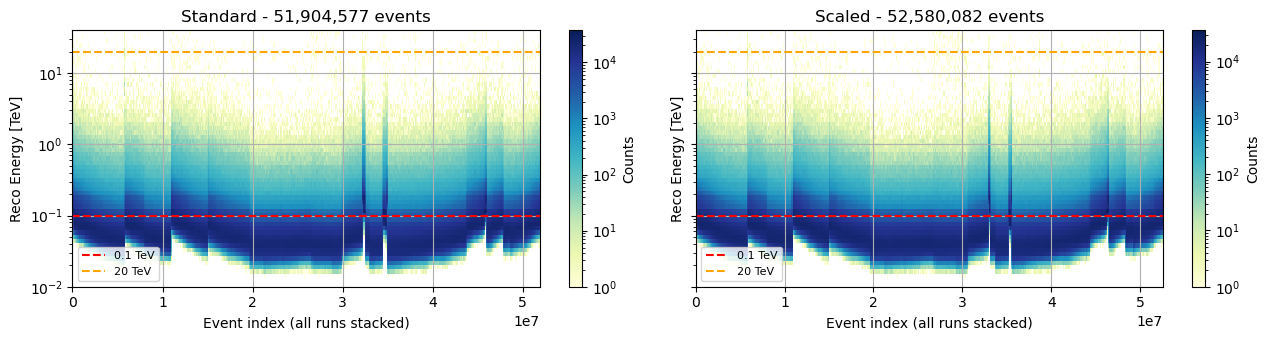

Dataset         N events    E median [TeV]    gammaness median
Standard      51,904,577            0.0603              0.2561
Scaled        52,580,082            0.0603              0.2565
CPU times: user 3min 25s, sys: 1min 41s, total: 5min 7s
Wall time: 6min 34s


In [7]:
%%time
energy_std_list, gammaness_std_list = [], []
energy_scaled_list, gammaness_scaled_list = [], []
for i, (obs_st, obs_sc) in enumerate(zip(obs_std, obs_scaled)):
    print(f"Reading observations data... ({i+1}/{len(OBS_IDS)})", end="\r")
    energy_std_list.append(obs_st.events.table["ENERGY"])
    gammaness_std_list.append(obs_st.events.table["GAMMANESS"])
    energy_scaled_list.append(obs_sc.events.table["ENERGY"])
    gammaness_scaled_list.append(obs_sc.events.table["GAMMANESS"])

energy_std = np.concatenate(energy_std_list)
gammaness_std = np.concatenate(gammaness_std_list)
energy_scaled = np.concatenate(energy_scaled_list)
gammaness_scaled = np.concatenate(gammaness_scaled_list)

ebins = np.logspace(-2, 1.6, 60)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
for ax, energy, label, color in [
    (axes[0], energy_std,    LABEL_STD,    COLOR_STD),
    (axes[1], energy_scaled, LABEL_SCALED, COLOR_SCALED),
]:
    h = ax.hist2d(range(len(energy)), energy, (400, ebins), norm=LogNorm(), cmap="YlGnBu")
    fig.colorbar(h[3], ax=ax, label="Counts")
    ax.axhline(E_RECO_MIN, color="r", ls="--", lw=1.5, label=f"{E_RECO_MIN} TeV")
    ax.axhline(E_RECO_MAX, color="orange", ls="--", lw=1.5, label=f"{E_RECO_MAX} TeV")
    ax.set_yscale("log")
    ax.set_title(f"{label} - {len(energy):,} events")
    ax.set_xlabel("Event index (all runs stacked)")
    ax.set_ylabel("Reco Energy [TeV]")
    ax.legend(fontsize=8); ax.grid()

plt.tight_layout()
plt.show()

print(f"{'Dataset':12s}  {'N events':>10s}  {'E median [TeV]':>16s}  {'gammaness median':>18s}")
for label, en, gn in [(LABEL_STD, energy_std, gammaness_std), (LABEL_SCALED, energy_scaled, gammaness_scaled)]:
    print(f"{label:12s}  {len(en):>10,}  {np.median(en):>16.4f}  {np.median(gn):>18.4f}")

---
## 4 · Energy axes & spatial geometry

Both datasets share the **same energy binning and spatial geometry** — defined once here.

In [8]:
energy_axis = MapAxis.from_energy_bounds(
    E_RECO_MIN, E_RECO_MAX,
    nbin=E_RECO_BINS, per_decade=True,
    unit="TeV", name="energy",
)
energy_axis_true = MapAxis.from_energy_bounds(
    E_TRUE_MIN, E_TRUE_MAX,
    nbin=E_TRUE_BINS, per_decade=True,
    unit="TeV", name="energy_true",
)

print(f"Reco energy axis edges  ({len(energy_axis.edges)-1} bins):")
display(energy_axis.edges)
print(f"\nTrue energy axis edges ({len(energy_axis_true.edges)-1} bins):")
display(energy_axis_true.edges)

Reco energy axis edges  (10 bins):


<Quantity [ 0.1       ,  0.16986465,  0.28853998,  0.49012742,  0.83255321,
            1.41421356,  2.40224887,  4.08057155,  6.93144843, 11.77408037,
           20.        ] TeV>


True energy axis edges (18 bins):


<Quantity [ 0.05      ,  0.07248577,  0.10508375,  0.15234154,  0.22085189,
            0.3201724 ,  0.46415888,  0.67289832,  0.97551111,  1.41421356,
            2.0502073 ,  2.97221726,  4.30886938,  6.24663465,  9.05584297,
           13.12839576, 19.03243859, 27.5916209 , 40.        ] TeV>

In [9]:
on_region = PointSkyRegion(center=SOURCE_COORD)
on_geom   = RegionGeom.create(region=on_region, axes=[energy_axis])

region_finder = WobbleRegionsFinder(n_off_regions=N_OFF_REGIONS)   # 1 is safe for any wobble geometry
maker_bkg     = ReflectedRegionsBackgroundMaker(region_finder=region_finder)

print(f"ON region  : PointSkyRegion at RA={SOURCE_COORD.ra:.4f}, Dec={SOURCE_COORD.dec:.4f}")
print(f"OFF method : WobbleRegionsFinder with 1 OFF region (RAD_MAX-driven radius)")

ON region  : PointSkyRegion at RA=83.6324 deg, Dec=22.0174 deg
OFF method : WobbleRegionsFinder with 1 OFF region (RAD_MAX-driven radius)


---
## 5 · Dataset creation with per-run diagnostics

For **every run** we print:
- Number of OFF regions found  
- Safe-mask coverage fraction  
- ON / OFF / α / excess counts per energy bin  

Runs that fail background estimation are **skipped** and listed at the end.  
Run both cells (Standard then Scaled) before moving on.

In [10]:
maker = SpectrumDatasetMaker(
    containment_correction=False,   # must be False with point-like (RAD_MAX) IRF
    selection=["counts", "exposure", "edisp"],
)
maker_safe_mask = SafeMaskMaker(methods=["aeff-max"], aeff_percent=AEFF_PERCENT)
dataset_empty   = SpectrumDataset.create(geom=on_geom, energy_axis_true=energy_axis_true)

n_ebins = len(energy_axis.edges) - 1
print(f"Makers ready.  Safe mask: aeff-max at {AEFF_PERCENT}%   n_ebins={n_ebins}")

Makers ready.  Safe mask: aeff-max at 5%   n_ebins=10


  Building STANDARD datasets  (56 runs)

--- Run 21816 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1076    1053   1.0000     23.00
     1      0.1699      0.2885     311     246   1.0000     65.00
     2      0.2885      0.4901      40      14   1.0000     26.00
     3      0.4901      0.8326      30       4   1.0000     26.00
     4      0.8326      1.4142      23       0   1.0000     23.00
     5      1.4142      2.4022       5       0   1.0000      5.00
     6      2.4022      4.0806       2       0   1.0000      2.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


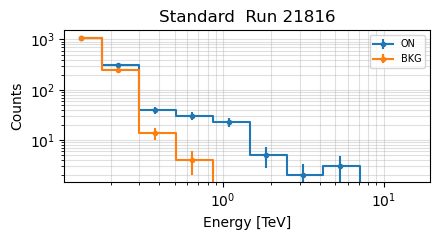


--- Run 21927 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    9908    9615   1.0000    293.00
     1      0.1699      0.2885    2249    2049   1.0000    200.00
     2      0.2885      0.4901     292     149   1.0000    143.00
     3      0.4901      0.8326     145      31   1.0000    114.00
     4      0.8326      1.4142      83      13   1.0000     70.00
     5      1.4142      2.4022      31       1   1.0000     30.00
     6      2.4022      4.0806      17       1   1.0000     16.00
     7      4.0806      6.9314       9       0   1.0000      9.00
     8      6.9314     11.7741       2       0   1.0000      2.00
     9     11.7741     20.0000       0       0   1.0000      0.00


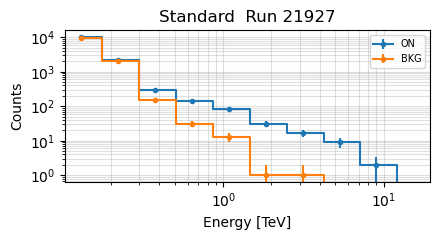


--- Run 21928 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    6751    6766   1.0000    -15.00
     1      0.1699      0.2885    1140     954   1.0000    186.00
     2      0.2885      0.4901     238      88   1.0000    150.00
     3      0.4901      0.8326     126      23   1.0000    103.00
     4      0.8326      1.4142      48       4   1.0000     44.00
     5      1.4142      2.4022      18       3   1.0000     15.00
     6      2.4022      4.0806       7       0   1.0000      7.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


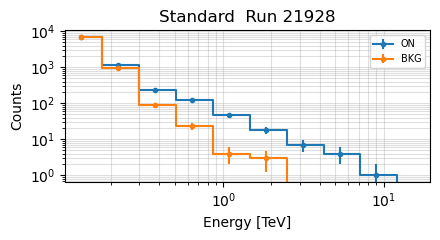


--- Run 21929 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    4938    4644   1.0000    294.00
     1      0.1699      0.2885     661     413   1.0000    248.00
     2      0.2885      0.4901     210      50   1.0000    160.00
     3      0.4901      0.8326     117      17   1.0000    100.00
     4      0.8326      1.4142      63       4   1.0000     59.00
     5      1.4142      2.4022      23       1   1.0000     22.00
     6      2.4022      4.0806      11       0   1.0000     11.00
     7      4.0806      6.9314       5       0   1.0000      5.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


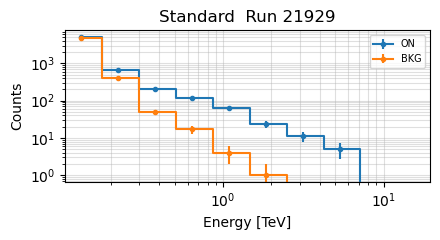


--- Run 21930 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    3921    3599   1.0000    322.00
     1      0.1699      0.2885     482     278   1.0000    204.00
     2      0.2885      0.4901     156      45   1.0000    111.00
     3      0.4901      0.8326     111      20   1.0000     91.00
     4      0.8326      1.4142      43       3   1.0000     40.00
     5      1.4142      2.4022      13       2   1.0000     11.00
     6      2.4022      4.0806      10       1   1.0000      9.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


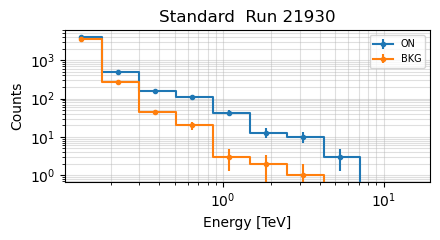


--- Run 21931 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    2929    2743   1.0000    186.00
     1      0.1699      0.2885     411     190   1.0000    221.00
     2      0.2885      0.4901     163      42   1.0000    121.00
     3      0.4901      0.8326     104      20   1.0000     84.00
     4      0.8326      1.4142      49       4   1.0000     45.00
     5      1.4142      2.4022      20       1   1.0000     19.00
     6      2.4022      4.0806       6       1   1.0000      5.00
     7      4.0806      6.9314       5       0   1.0000      5.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


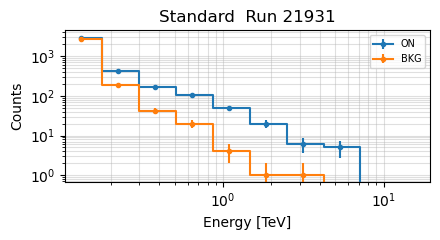


--- Run 21945 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    8139    7608   1.0000    531.00
     1      0.1699      0.2885    1688    1430   1.0000    258.00
     2      0.2885      0.4901     268      79   1.0000    189.00
     3      0.4901      0.8326     111      24   1.0000     87.00
     4      0.8326      1.4142      48      13   1.0000     35.00
     5      1.4142      2.4022      21       1   1.0000     20.00
     6      2.4022      4.0806      10       1   1.0000      9.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       3       0   1.0000      3.00
     9     11.7741     20.0000       0       0   1.0000      0.00


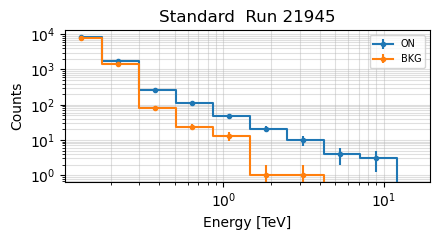


--- Run 21946 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    5887    5682   1.0000    205.00
     1      0.1699      0.2885     902     678   1.0000    224.00
     2      0.2885      0.4901     231      75   1.0000    156.00
     3      0.4901      0.8326     105      20   1.0000     85.00
     4      0.8326      1.4142      63       6   1.0000     57.00
     5      1.4142      2.4022      23       2   1.0000     21.00
     6      2.4022      4.0806      10       1   1.0000      9.00
     7      4.0806      6.9314       5       0   1.0000      5.00
     8      6.9314     11.7741       2       0   1.0000      2.00
     9     11.7741     20.0000       0       0   1.0000      0.00


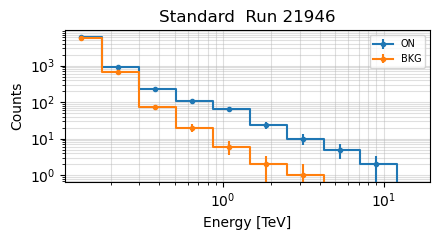


--- Run 22028 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    2891    2498   1.0000    393.00
     1      0.1699      0.2885     312     173   1.0000    139.00
     2      0.2885      0.4901     134      32   1.0000    102.00
     3      0.4901      0.8326      79      14   1.0000     65.00
     4      0.8326      1.4142      29       6   1.0000     23.00
     5      1.4142      2.4022      16       1   1.0000     15.00
     6      2.4022      4.0806      11       0   1.0000     11.00
     7      4.0806      6.9314       0       1   1.0000     -1.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


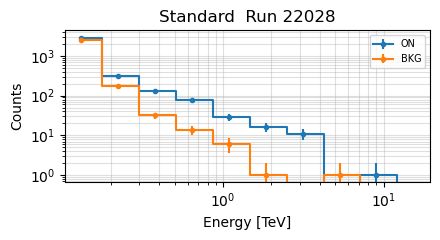


--- Run 22029 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1906    1765   1.0000    141.00
     1      0.1699      0.2885     304     108   1.0000    196.00
     2      0.2885      0.4901     126      32   1.0000     94.00
     3      0.4901      0.8326      78      11   1.0000     67.00
     4      0.8326      1.4142      38       3   1.0000     35.00
     5      1.4142      2.4022      21       0   1.0000     21.00
     6      2.4022      4.0806       8       0   1.0000      8.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


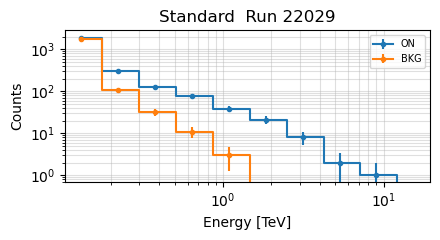


--- Run 22030 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1547    1418   1.0000    129.00
     1      0.1699      0.2885     260     118   1.0000    142.00
     2      0.2885      0.4901     135      25   1.0000    110.00
     3      0.4901      0.8326      52       7   1.0000     45.00
     4      0.8326      1.4142      35       1   1.0000     34.00
     5      1.4142      2.4022      12       0   1.0000     12.00
     6      2.4022      4.0806       8       0   1.0000      8.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


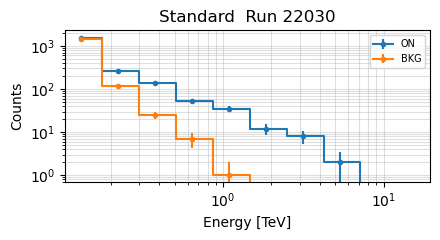


--- Run 22054 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699   12930   12599   1.0000    331.00
     1      0.1699      0.2885    3316    3023   1.0000    293.00
     2      0.2885      0.4901     452     213   1.0000    239.00
     3      0.4901      0.8326     198      42   1.0000    156.00
     4      0.8326      1.4142     105      14   1.0000     91.00
     5      1.4142      2.4022      45       5   1.0000     40.00
     6      2.4022      4.0806      17       1   1.0000     16.00
     7      4.0806      6.9314      10       0   1.0000     10.00
     8      6.9314     11.7741       4       0   1.0000      4.00
     9     11.7741     20.0000       0       0   1.0000      0.00


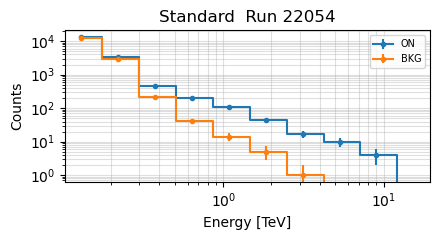


--- Run 22055 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    6928    6628   1.0000    300.00
     1      0.1699      0.2885    1233     995   1.0000    238.00
     2      0.2885      0.4901     249     125   1.0000    124.00
     3      0.4901      0.8326     127      17   1.0000    110.00
     4      0.8326      1.4142      71       9   1.0000     62.00
     5      1.4142      2.4022      17       1   1.0000     16.00
     6      2.4022      4.0806      14       0   1.0000     14.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       2       0   1.0000      2.00


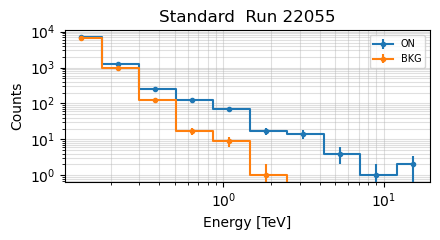


--- Run 22056 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    5008    4797   1.0000    211.00
     1      0.1699      0.2885     668     434   1.0000    234.00
     2      0.2885      0.4901     197      76   1.0000    121.00
     3      0.4901      0.8326     131      13   1.0000    118.00
     4      0.8326      1.4142      63       4   1.0000     59.00
     5      1.4142      2.4022      15       3   1.0000     12.00
     6      2.4022      4.0806      23       0   1.0000     23.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       2       0   1.0000      2.00


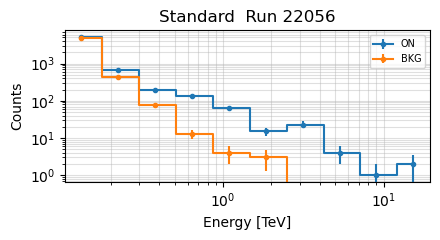


--- Run 22057 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    4040    3814   1.0000    226.00
     1      0.1699      0.2885     488     287   1.0000    201.00
     2      0.2885      0.4901     199      72   1.0000    127.00
     3      0.4901      0.8326     104      10   1.0000     94.00
     4      0.8326      1.4142      55       6   1.0000     49.00
     5      1.4142      2.4022      19       3   1.0000     16.00
     6      2.4022      4.0806      13       0   1.0000     13.00
     7      4.0806      6.9314       1       0   1.0000      1.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


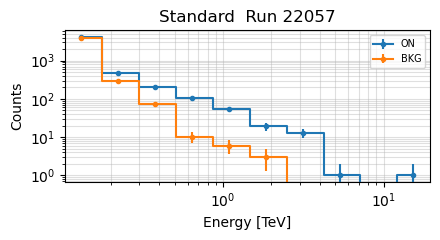


--- Run 22060 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     384     356   1.0000     28.00
     1      0.1699      0.2885      85      33   1.0000     52.00
     2      0.2885      0.4901      39      11   1.0000     28.00
     3      0.4901      0.8326      23       3   1.0000     20.00
     4      0.8326      1.4142      13       2   1.0000     11.00
     5      1.4142      2.4022       4       2   1.0000      2.00
     6      2.4022      4.0806       3       0   1.0000      3.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


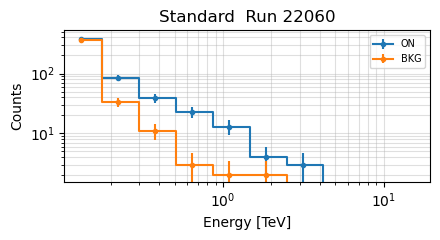


--- Run 22740 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    5066    5119   1.0000    -53.00
     1      0.1699      0.2885     780     602   1.0000    178.00
     2      0.2885      0.4901     168      70   1.0000     98.00
     3      0.4901      0.8326      93      12   1.0000     81.00
     4      0.8326      1.4142      41       4   1.0000     37.00
     5      1.4142      2.4022      18       1   1.0000     17.00
     6      2.4022      4.0806       7       1   1.0000      6.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


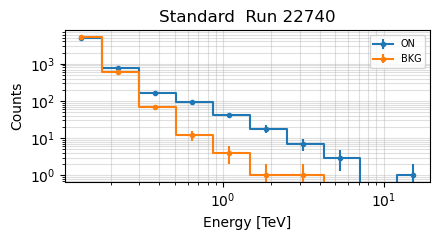


--- Run 22741 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    3767    3517   1.0000    250.00
     1      0.1699      0.2885     442     329   1.0000    113.00
     2      0.2885      0.4901     164      55   1.0000    109.00
     3      0.4901      0.8326      85      12   1.0000     73.00
     4      0.8326      1.4142      48       3   1.0000     45.00
     5      1.4142      2.4022      14       2   1.0000     12.00
     6      2.4022      4.0806       7       0   1.0000      7.00
     7      4.0806      6.9314       1       0   1.0000      1.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       2       0   1.0000      2.00


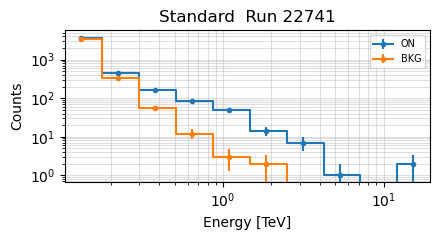


--- Run 22742 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    4568    4300   1.0000    268.00
     1      0.1699      0.2885     510     319   1.0000    191.00
     2      0.2885      0.4901     210      57   1.0000    153.00
     3      0.4901      0.8326     124      24   1.0000    100.00
     4      0.8326      1.4142      42       3   1.0000     39.00
     5      1.4142      2.4022      27       3   1.0000     24.00
     6      2.4022      4.0806      14       0   1.0000     14.00
     7      4.0806      6.9314       5       0   1.0000      5.00
     8      6.9314     11.7741       2       0   1.0000      2.00
     9     11.7741     20.0000       0       0   1.0000      0.00


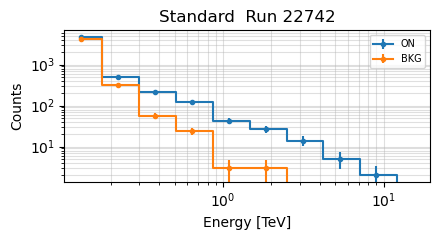


--- Run 22743 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    2975    2761   1.0000    214.00
     1      0.1699      0.2885     393     191   1.0000    202.00
     2      0.2885      0.4901     158      49   1.0000    109.00
     3      0.4901      0.8326      79      10   1.0000     69.00
     4      0.8326      1.4142      43       2   1.0000     41.00
     5      1.4142      2.4022      19       2   1.0000     17.00
     6      2.4022      4.0806       2       0   1.0000      2.00
     7      4.0806      6.9314       1       0   1.0000      1.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


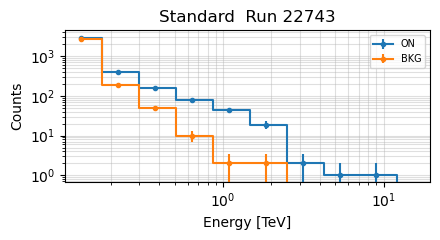


--- Run 22987 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1586    1437   1.0000    149.00
     1      0.1699      0.2885     253     142   1.0000    111.00
     2      0.2885      0.4901     111      26   1.0000     85.00
     3      0.4901      0.8326      49      10   1.0000     39.00
     4      0.8326      1.4142      25       1   1.0000     24.00
     5      1.4142      2.4022       5       1   1.0000      4.00
     6      2.4022      4.0806       4       1   1.0000      3.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


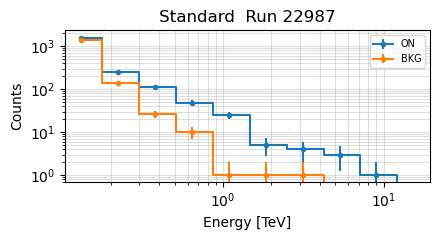


--- Run 22988 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1662    1432   1.0000    230.00
     1      0.1699      0.2885     259     124   1.0000    135.00
     2      0.2885      0.4901     120      30   1.0000     90.00
     3      0.4901      0.8326      58       7   1.0000     51.00
     4      0.8326      1.4142      20       2   1.0000     18.00
     5      1.4142      2.4022      12       0   1.0000     12.00
     6      2.4022      4.0806       6       0   1.0000      6.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


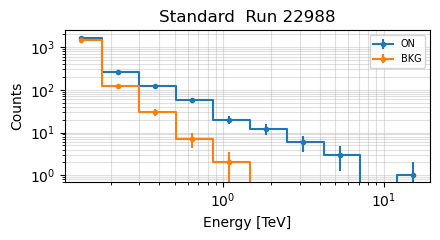


--- Run 22989 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1613    1477   1.0000    136.00
     1      0.1699      0.2885     281     142   1.0000    139.00
     2      0.2885      0.4901     108      15   1.0000     93.00
     3      0.4901      0.8326      58       5   1.0000     53.00
     4      0.8326      1.4142      23       1   1.0000     22.00
     5      1.4142      2.4022       6       0   1.0000      6.00
     6      2.4022      4.0806       2       0   1.0000      2.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


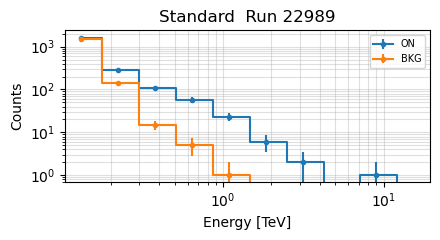


--- Run 22990 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1591    1386   1.0000    205.00
     1      0.1699      0.2885     262     107   1.0000    155.00
     2      0.2885      0.4901     107      27   1.0000     80.00
     3      0.4901      0.8326      48      10   1.0000     38.00
     4      0.8326      1.4142      19       3   1.0000     16.00
     5      1.4142      2.4022      11       0   1.0000     11.00
     6      2.4022      4.0806       4       1   1.0000      3.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


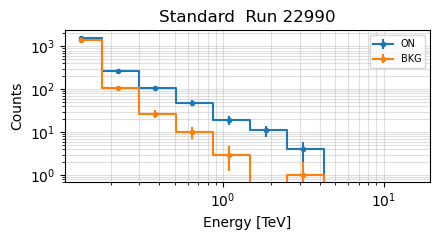


--- Run 23009 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1051     855   1.0000    196.00
     1      0.1699      0.2885     255      99   1.0000    156.00
     2      0.2885      0.4901     121      32   1.0000     89.00
     3      0.4901      0.8326      56       6   1.0000     50.00
     4      0.8326      1.4142      34       1   1.0000     33.00
     5      1.4142      2.4022      13       0   1.0000     13.00
     6      2.4022      4.0806       5       0   1.0000      5.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


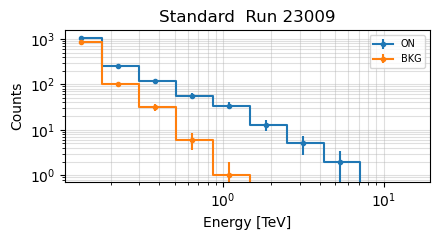


--- Run 23011 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     735     605   1.0000    130.00
     1      0.1699      0.2885     180      88   1.0000     92.00
     2      0.2885      0.4901      95      15   1.0000     80.00
     3      0.4901      0.8326      30       2   1.0000     28.00
     4      0.8326      1.4142      17       2   1.0000     15.00
     5      1.4142      2.4022       4       0   1.0000      4.00
     6      2.4022      4.0806       2       0   1.0000      2.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


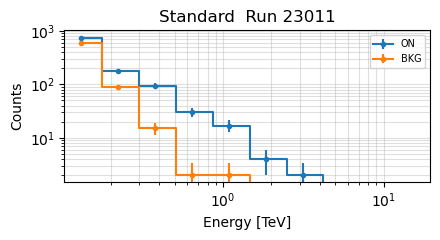


--- Run 23012 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     859     782   1.0000     77.00
     1      0.1699      0.2885     188      86   1.0000    102.00
     2      0.2885      0.4901      79      16   1.0000     63.00
     3      0.4901      0.8326      47      10   1.0000     37.00
     4      0.8326      1.4142      17       2   1.0000     15.00
     5      1.4142      2.4022       7       1   1.0000      6.00
     6      2.4022      4.0806       1       0   1.0000      1.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


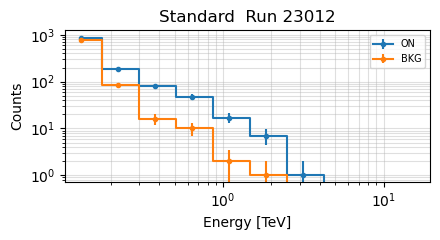


--- Run 23039 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1571    1443   1.0000    128.00
     1      0.1699      0.2885     209     109   1.0000    100.00
     2      0.2885      0.4901      98      20   1.0000     78.00
     3      0.4901      0.8326      48       7   1.0000     41.00
     4      0.8326      1.4142      21       2   1.0000     19.00
     5      1.4142      2.4022      12       0   1.0000     12.00
     6      2.4022      4.0806       5       0   1.0000      5.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


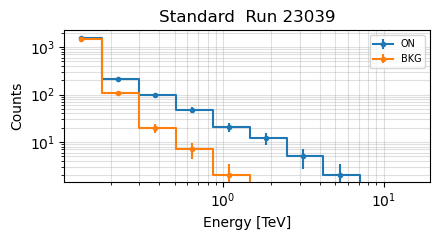


--- Run 23040 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    4985    4675   1.0000    310.00
     1      0.1699      0.2885     531     396   1.0000    135.00
     2      0.2885      0.4901     243      79   1.0000    164.00
     3      0.4901      0.8326     116      21   1.0000     95.00
     4      0.8326      1.4142      56       5   1.0000     51.00
     5      1.4142      2.4022      27       2   1.0000     25.00
     6      2.4022      4.0806       7       0   1.0000      7.00
     7      4.0806      6.9314       7       0   1.0000      7.00
     8      6.9314     11.7741       2       0   1.0000      2.00
     9     11.7741     20.0000       0       0   1.0000      0.00


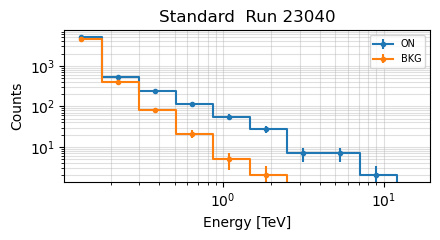


--- Run 23087 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699      77      50   1.0000     27.00
     1      0.1699      0.2885     380     264   1.0000    116.00
     2      0.2885      0.4901      80      38   1.0000     42.00
     3      0.4901      0.8326      39       6   1.0000     33.00
     4      0.8326      1.4142      12       3   1.0000      9.00
     5      1.4142      2.4022      17       0   1.0000     17.00
     6      2.4022      4.0806       1       0   1.0000      1.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       1       1   1.0000      0.00
     9     11.7741     20.0000       2       0   1.0000      2.00


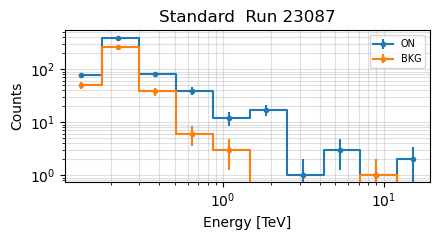


--- Run 23088 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     336     220   1.0000    116.00
     1      0.1699      0.2885     634     468   1.0000    166.00
     2      0.2885      0.4901     130      40   1.0000     90.00
     3      0.4901      0.8326      65      11   1.0000     54.00
     4      0.8326      1.4142      31       2   1.0000     29.00
     5      1.4142      2.4022      21       0   1.0000     21.00
     6      2.4022      4.0806       8       0   1.0000      8.00
     7      4.0806      6.9314       1       0   1.0000      1.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


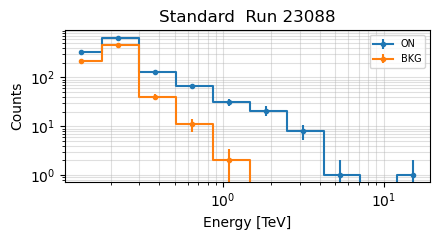


--- Run 23089 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     861     936   1.0000    -75.00
     1      0.1699      0.2885     417     325   1.0000     92.00
     2      0.2885      0.4901      99      30   1.0000     69.00
     3      0.4901      0.8326      70       6   1.0000     64.00
     4      0.8326      1.4142      24       2   1.0000     22.00
     5      1.4142      2.4022      14       0   1.0000     14.00
     6      2.4022      4.0806       5       0   1.0000      5.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


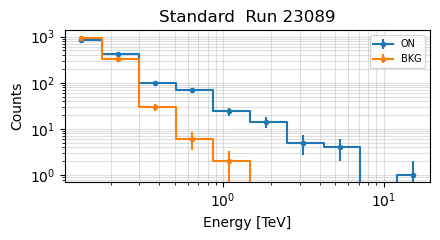


--- Run 23090 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1878    1552   1.0000    326.00
     1      0.1699      0.2885     438     313   1.0000    125.00
     2      0.2885      0.4901     130      35   1.0000     95.00
     3      0.4901      0.8326      61       7   1.0000     54.00
     4      0.8326      1.4142      47       6   1.0000     41.00
     5      1.4142      2.4022      20       0   1.0000     20.00
     6      2.4022      4.0806      10       0   1.0000     10.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       3       0   1.0000      3.00
     9     11.7741     20.0000       1       0   1.0000      1.00


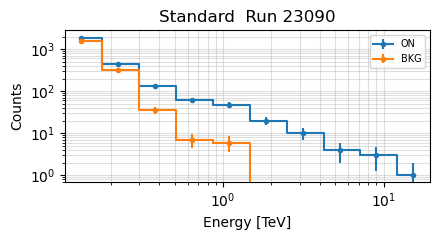


--- Run 23093 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     738     601   1.0000    137.00
     1      0.1699      0.2885     117      63   1.0000     54.00
     2      0.2885      0.4901      60      10   1.0000     50.00
     3      0.4901      0.8326      28       6   1.0000     22.00
     4      0.8326      1.4142      14       0   1.0000     14.00
     5      1.4142      2.4022       8       0   1.0000      8.00
     6      2.4022      4.0806       4       0   1.0000      4.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


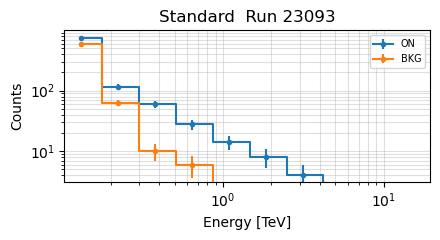


--- Run 23094 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     482     392   1.0000     90.00
     1      0.1699      0.2885     100      43   1.0000     57.00
     2      0.2885      0.4901      47      10   1.0000     37.00
     3      0.4901      0.8326      19       5   1.0000     14.00
     4      0.8326      1.4142       7       1   1.0000      6.00
     5      1.4142      2.4022       6       1   1.0000      5.00
     6      2.4022      4.0806       1       1   1.0000      0.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


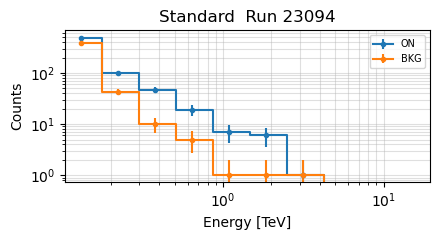


--- Run 23095 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     870     743   1.0000    127.00
     1      0.1699      0.2885     198      72   1.0000    126.00
     2      0.2885      0.4901      80      14   1.0000     66.00
     3      0.4901      0.8326      43       3   1.0000     40.00
     4      0.8326      1.4142      26       1   1.0000     25.00
     5      1.4142      2.4022      10       0   1.0000     10.00
     6      2.4022      4.0806       4       0   1.0000      4.00
     7      4.0806      6.9314       1       0   1.0000      1.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


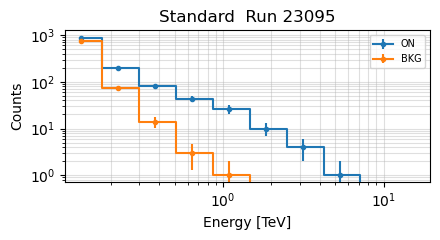


--- Run 23492 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    2542    2519   1.0000     23.00
     1      0.1699      0.2885     298     186   1.0000    112.00
     2      0.2885      0.4901     121      27   1.0000     94.00
     3      0.4901      0.8326      77      13   1.0000     64.00
     4      0.8326      1.4142      21       7   1.0000     14.00
     5      1.4142      2.4022      18       2   1.0000     16.00
     6      2.4022      4.0806       2       0   1.0000      2.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


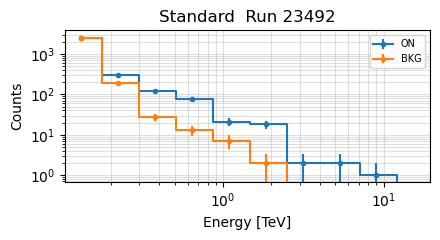


--- Run 23493 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    2178    2019   1.0000    159.00
     1      0.1699      0.2885     279     128   1.0000    151.00
     2      0.2885      0.4901     133      33   1.0000    100.00
     3      0.4901      0.8326      87       3   1.0000     84.00
     4      0.8326      1.4142      34       5   1.0000     29.00
     5      1.4142      2.4022      15       0   1.0000     15.00
     6      2.4022      4.0806      10       0   1.0000     10.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


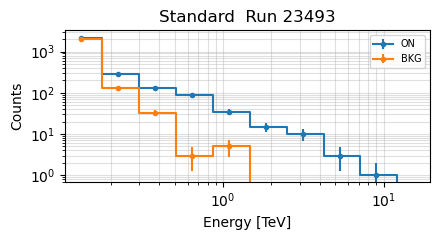


--- Run 23559 ---
  OFF regions found : 1
  Safe mask coverage: 90.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     602     804   1.0000   -202.00
     1      0.1699      0.2885     743     795   1.0000    -52.00
     2      0.2885      0.4901      83      67   1.0000     16.00
     3      0.4901      0.8326      37       7   1.0000     30.00
     4      0.8326      1.4142      11       0   1.0000     11.00
     5      1.4142      2.4022       9       0   1.0000      9.00
     6      2.4022      4.0806       4       0   1.0000      4.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


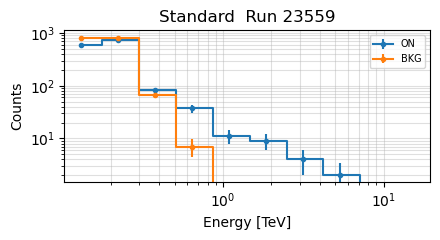


--- Run 23656 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1522    1347   1.0000    175.00
     1      0.1699      0.2885     342     158   1.0000    184.00
     2      0.2885      0.4901     190      29   1.0000    161.00
     3      0.4901      0.8326      80      10   1.0000     70.00
     4      0.8326      1.4142      41       2   1.0000     39.00
     5      1.4142      2.4022      19       0   1.0000     19.00
     6      2.4022      4.0806       4       0   1.0000      4.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


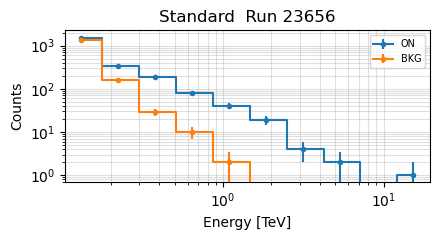


--- Run 23657 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1643    1385   1.0000    258.00
     1      0.1699      0.2885     323     138   1.0000    185.00
     2      0.2885      0.4901     143      35   1.0000    108.00
     3      0.4901      0.8326      73       9   1.0000     64.00
     4      0.8326      1.4142      35       4   1.0000     31.00
     5      1.4142      2.4022      12       0   1.0000     12.00
     6      2.4022      4.0806       3       0   1.0000      3.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       2       0   1.0000      2.00
     9     11.7741     20.0000       0       0   1.0000      0.00


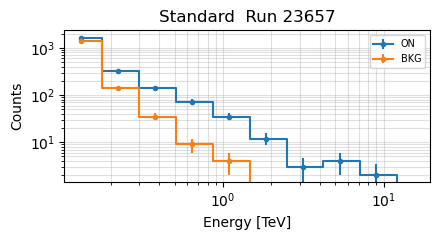


--- Run 23658 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1684    1440   1.0000    244.00
     1      0.1699      0.2885     306     132   1.0000    174.00
     2      0.2885      0.4901     131      38   1.0000     93.00
     3      0.4901      0.8326      66       9   1.0000     57.00
     4      0.8326      1.4142      25       4   1.0000     21.00
     5      1.4142      2.4022       7       1   1.0000      6.00
     6      2.4022      4.0806       7       1   1.0000      6.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


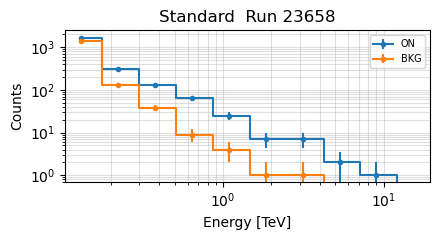


--- Run 23659 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    2348    2087   1.0000    261.00
     1      0.1699      0.2885     370     168   1.0000    202.00
     2      0.2885      0.4901     160      38   1.0000    122.00
     3      0.4901      0.8326      88      13   1.0000     75.00
     4      0.8326      1.4142      42       4   1.0000     38.00
     5      1.4142      2.4022      25       0   1.0000     25.00
     6      2.4022      4.0806       7       0   1.0000      7.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       1       0   1.0000      1.00


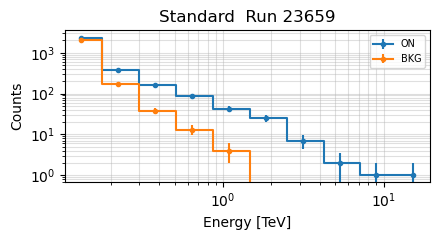


--- Run 23660 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    3054    2889   1.0000    165.00
     1      0.1699      0.2885     391     203   1.0000    188.00
     2      0.2885      0.4901     172      55   1.0000    117.00
     3      0.4901      0.8326      73      11   1.0000     62.00
     4      0.8326      1.4142      35       3   1.0000     32.00
     5      1.4142      2.4022      17       1   1.0000     16.00
     6      2.4022      4.0806       7       0   1.0000      7.00
     7      4.0806      6.9314       3       1   1.0000      2.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


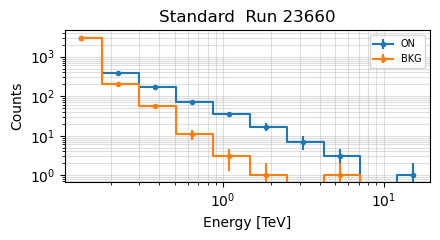


--- Run 23661 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    3847    3453   1.0000    394.00
     1      0.1699      0.2885     466     300   1.0000    166.00
     2      0.2885      0.4901     207      57   1.0000    150.00
     3      0.4901      0.8326      97      15   1.0000     82.00
     4      0.8326      1.4142      47       4   1.0000     43.00
     5      1.4142      2.4022      20       3   1.0000     17.00
     6      2.4022      4.0806      10       1   1.0000      9.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


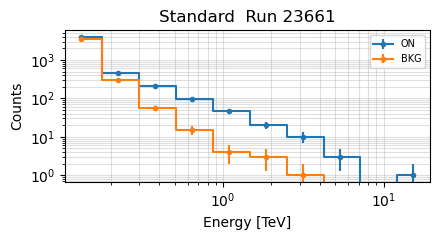


--- Run 23662 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1320    1272   1.0000     48.00
     1      0.1699      0.2885     187     118   1.0000     69.00
     2      0.2885      0.4901      63      25   1.0000     38.00
     3      0.4901      0.8326      29       7   1.0000     22.00
     4      0.8326      1.4142      10       1   1.0000      9.00
     5      1.4142      2.4022       7       0   1.0000      7.00
     6      2.4022      4.0806       4       1   1.0000      3.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


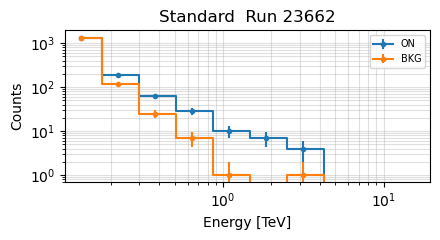


--- Run 23664 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    8119    8043   1.0000     76.00
     1      0.1699      0.2885    1724    1479   1.0000    245.00
     2      0.2885      0.4901     306     110   1.0000    196.00
     3      0.4901      0.8326     133      29   1.0000    104.00
     4      0.8326      1.4142      70       9   1.0000     61.00
     5      1.4142      2.4022      44       2   1.0000     42.00
     6      2.4022      4.0806      14       1   1.0000     13.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       2       0   1.0000      2.00


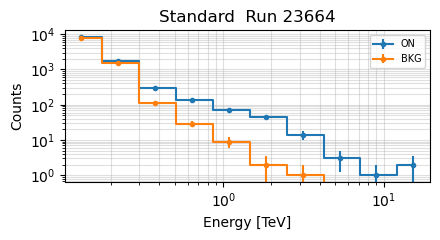


--- Run 23665 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699   10045    9612   1.0000    433.00
     1      0.1699      0.2885    2690    2405   1.0000    285.00
     2      0.2885      0.4901     355     176   1.0000    179.00
     3      0.4901      0.8326     160      25   1.0000    135.00
     4      0.8326      1.4142      70       8   1.0000     62.00
     5      1.4142      2.4022      32       2   1.0000     30.00
     6      2.4022      4.0806      16       1   1.0000     15.00
     7      4.0806      6.9314       8       1   1.0000      7.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       2       0   1.0000      2.00


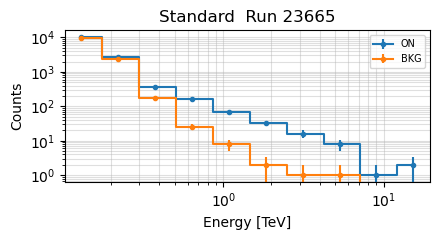


--- Run 23896 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    2115    1840   1.0000    275.00
     1      0.1699      0.2885     443     376   1.0000     67.00
     2      0.2885      0.4901      77      31   1.0000     46.00
     3      0.4901      0.8326      31       7   1.0000     24.00
     4      0.8326      1.4142      24       3   1.0000     21.00
     5      1.4142      2.4022       8       0   1.0000      8.00
     6      2.4022      4.0806       8       0   1.0000      8.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


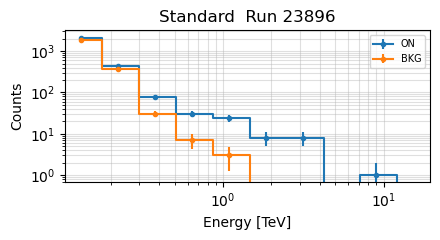


--- Run 23897 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    2663    3129   1.0000   -466.00
     1      0.1699      0.2885    1034     971   1.0000     63.00
     2      0.2885      0.4901     144      75   1.0000     69.00
     3      0.4901      0.8326      73      10   1.0000     63.00
     4      0.8326      1.4142      39       5   1.0000     34.00
     5      1.4142      2.4022      22       0   1.0000     22.00
     6      2.4022      4.0806       6       1   1.0000      5.00
     7      4.0806      6.9314       3       1   1.0000      2.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


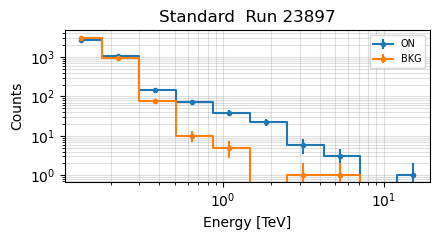


--- Run 23955 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    4471    4328   1.0000    143.00
     1      0.1699      0.2885     660     546   1.0000    114.00
     2      0.2885      0.4901     154      56   1.0000     98.00
     3      0.4901      0.8326      61      15   1.0000     46.00
     4      0.8326      1.4142      42       3   1.0000     39.00
     5      1.4142      2.4022      14       1   1.0000     13.00
     6      2.4022      4.0806       9       0   1.0000      9.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       4       1   1.0000      3.00
     9     11.7741     20.0000       0       0   1.0000      0.00


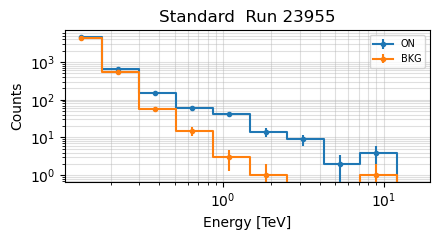


--- Run 23956 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    8937    9165   1.0000   -228.00
     1      0.1699      0.2885    2018    1820   1.0000    198.00
     2      0.2885      0.4901     289     116   1.0000    173.00
     3      0.4901      0.8326     137      27   1.0000    110.00
     4      0.8326      1.4142      73      16   1.0000     57.00
     5      1.4142      2.4022      32       1   1.0000     31.00
     6      2.4022      4.0806       9       0   1.0000      9.00
     7      4.0806      6.9314       0       1   1.0000     -1.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


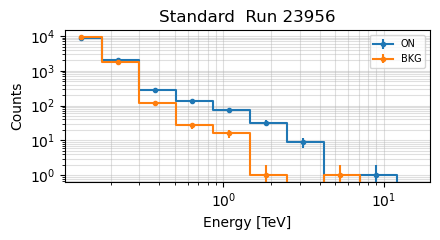


--- Run 23992 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    3043    2917   1.0000    126.00
     1      0.1699      0.2885     318     207   1.0000    111.00
     2      0.2885      0.4901     115      34   1.0000     81.00
     3      0.4901      0.8326      47      12   1.0000     35.00
     4      0.8326      1.4142      31       1   1.0000     30.00
     5      1.4142      2.4022      16       0   1.0000     16.00
     6      2.4022      4.0806       4       0   1.0000      4.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


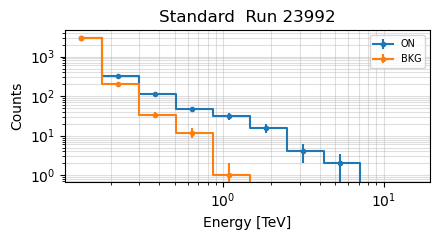


--- Run 23993 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    5466    5150   1.0000    316.00
     1      0.1699      0.2885     674     515   1.0000    159.00
     2      0.2885      0.4901     211      63   1.0000    148.00
     3      0.4901      0.8326     106      12   1.0000     94.00
     4      0.8326      1.4142      51       6   1.0000     45.00
     5      1.4142      2.4022      24       1   1.0000     23.00
     6      2.4022      4.0806      13       1   1.0000     12.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


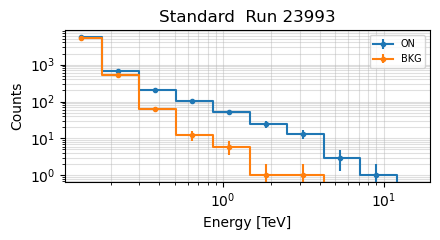


--- Run 23994 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    6762    6661   1.0000    101.00
     1      0.1699      0.2885    1068     821   1.0000    247.00
     2      0.2885      0.4901     219      72   1.0000    147.00
     3      0.4901      0.8326      98      16   1.0000     82.00
     4      0.8326      1.4142      47       2   1.0000     45.00
     5      1.4142      2.4022      23       1   1.0000     22.00
     6      2.4022      4.0806      15       0   1.0000     15.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       4       0   1.0000      4.00
     9     11.7741     20.0000       2       0   1.0000      2.00


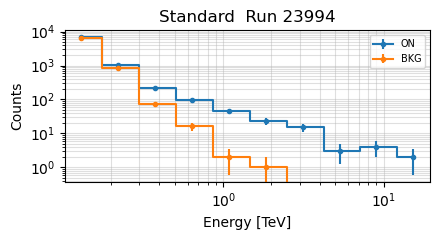


--- Run 23995 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699   10460   10359   1.0000    101.00
     1      0.1699      0.2885    2478    2300   1.0000    178.00
     2      0.2885      0.4901     302     151   1.0000    151.00
     3      0.4901      0.8326     137      39   1.0000     98.00
     4      0.8326      1.4142      52      11   1.0000     41.00
     5      1.4142      2.4022      33       0   1.0000     33.00
     6      2.4022      4.0806      15       0   1.0000     15.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       1       1   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


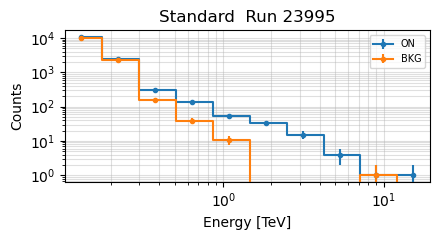


  Added 56 / 56 Standard runs.
  No runs skipped.


In [11]:
print("="*62)
print(f"  Building STANDARD datasets  ({len(OBS_IDS)} runs)")
print("="*62)

datasets_std = Datasets()
skipped_std  = []

for obs_id, obs in zip(OBS_IDS, obs_std):
    print(f"\n--- Run {obs_id} ---")

    dataset        = maker.run(dataset_empty.copy(name=str(obs_id)), obs)
    dataset_on_off = maker_bkg.run(dataset=dataset, observation=obs)

    if dataset_on_off.counts_off is None:
        print(f"  FAILED: Background estimation returned None — run skipped.")
        skipped_std.append(obs_id)
        continue

    n_off_found    = len(compound_region_to_regions(dataset_on_off.counts_off.geom.region))
    dataset_on_off = maker_safe_mask.run(dataset_on_off, obs)
    safe_frac      = dataset_on_off.mask_safe.data.mean()

    # Skip runs where the IRF gives zero effective area at the source position
    if safe_frac == 0.0:
        print(f"  FAILED: Safe mask is all False (aeff=0 at source position) — run skipped.")
        skipped_std.append(obs_id)
        continue

    print(f"  OFF regions found : {n_off_found}")
    print(f"  Safe mask coverage: {safe_frac*100:.1f}%")
    # ... rest of the loop unchanged

    c_on   = dataset_on_off.counts.data.reshape(n_ebins)
    c_off  = dataset_on_off.counts_off.data.reshape(n_ebins)
    alpha  = dataset_on_off.alpha.data.reshape(n_ebins)
    bkg    = c_off * alpha
    excess = c_on - bkg

    print(f"  {'bin':>4s}  {'E_lo [TeV]':>10s}  {'E_hi [TeV]':>10s}  {'ON':>6s}  {'OFF':>6s}  {'alpha':>7s}  {'excess':>8s}")
    for i in range(n_ebins):
        print(f"  {i:>4d}  {energy_axis.edges[i].value:>10.4f}  {energy_axis.edges[i+1].value:>10.4f}"
              f"  {int(c_on[i]):>6d}  {int(c_off[i]):>6d}  {alpha[i]:>7.4f}  {excess[i]:>8.2f}")

    fig, ax = plt.subplots(figsize=(4.5, 2.5))
    ax.errorbar(energy_axis.center.value, c_on,  yerr=np.sqrt(c_on),  ds="steps-mid", label="ON",  marker=".")
    ax.errorbar(energy_axis.center.value, bkg,   yerr=np.sqrt(bkg),   ds="steps-mid", label="BKG", marker=".")
    ax.set(xscale="log", xlabel="Energy [TeV]", ylabel="Counts", yscale="log", title=f"{LABEL_STD}  Run {obs_id}")
    ax.legend(fontsize=7); ax.grid(True, which="both", alpha=0.4)
    plt.tight_layout(); plt.show()

    datasets_std.append(dataset_on_off)

print("\n" + "="*62)
print(f"  Added {len(datasets_std)} / {len(OBS_IDS)} Standard runs.")
if skipped_std:
    print(f"  Skipped: {skipped_std}")
else:
    print("  No runs skipped.")
print("="*62)

  Building SCALED datasets  (56 runs)

--- Run 21816 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1161    1145   1.0000     16.00
     1      0.1699      0.2885     363     281   1.0000     82.00
     2      0.2885      0.4901      50      14   1.0000     36.00
     3      0.4901      0.8326      25       5   1.0000     20.00
     4      0.8326      1.4142      20       0   1.0000     20.00
     5      1.4142      2.4022       8       0   1.0000      8.00
     6      2.4022      4.0806       3       0   1.0000      3.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


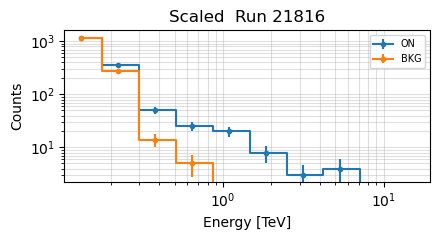


--- Run 21927 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    9977    9670   1.0000    307.00
     1      0.1699      0.2885    2313    2091   1.0000    222.00
     2      0.2885      0.4901     316     148   1.0000    168.00
     3      0.4901      0.8326     144      33   1.0000    111.00
     4      0.8326      1.4142      84      13   1.0000     71.00
     5      1.4142      2.4022      32       0   1.0000     32.00
     6      2.4022      4.0806      18       1   1.0000     17.00
     7      4.0806      6.9314       9       0   1.0000      9.00
     8      6.9314     11.7741       2       0   1.0000      2.00
     9     11.7741     20.0000       0       0   1.0000      0.00


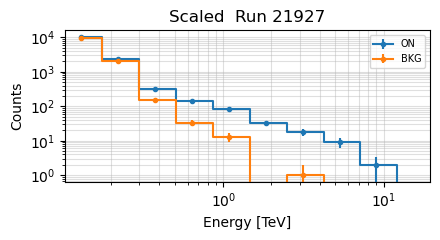


--- Run 21928 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    6846    6866   1.0000    -20.00
     1      0.1699      0.2885    1178     999   1.0000    179.00
     2      0.2885      0.4901     245      98   1.0000    147.00
     3      0.4901      0.8326     125      23   1.0000    102.00
     4      0.8326      1.4142      48       4   1.0000     44.00
     5      1.4142      2.4022      19       3   1.0000     16.00
     6      2.4022      4.0806       6       0   1.0000      6.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


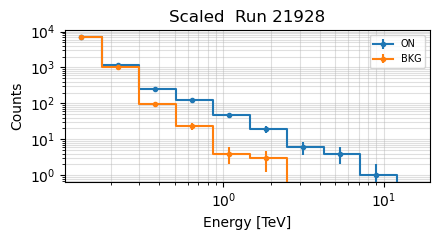


--- Run 21929 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    4970    4679   1.0000    291.00
     1      0.1699      0.2885     659     419   1.0000    240.00
     2      0.2885      0.4901     206      53   1.0000    153.00
     3      0.4901      0.8326     119      18   1.0000    101.00
     4      0.8326      1.4142      62       4   1.0000     58.00
     5      1.4142      2.4022      24       1   1.0000     23.00
     6      2.4022      4.0806      11       0   1.0000     11.00
     7      4.0806      6.9314       5       0   1.0000      5.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


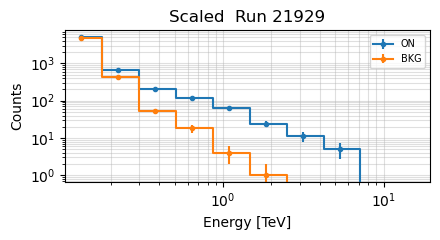


--- Run 21930 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    3939    3629   1.0000    310.00
     1      0.1699      0.2885     478     285   1.0000    193.00
     2      0.2885      0.4901     163      45   1.0000    118.00
     3      0.4901      0.8326     110      20   1.0000     90.00
     4      0.8326      1.4142      43       2   1.0000     41.00
     5      1.4142      2.4022      13       2   1.0000     11.00
     6      2.4022      4.0806      10       1   1.0000      9.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


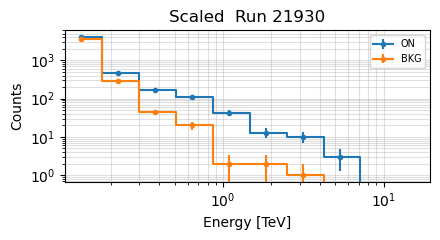


--- Run 21931 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    3000    2804   1.0000    196.00
     1      0.1699      0.2885     413     201   1.0000    212.00
     2      0.2885      0.4901     168      42   1.0000    126.00
     3      0.4901      0.8326     103      21   1.0000     82.00
     4      0.8326      1.4142      52       4   1.0000     48.00
     5      1.4142      2.4022      20       1   1.0000     19.00
     6      2.4022      4.0806       6       1   1.0000      5.00
     7      4.0806      6.9314       5       0   1.0000      5.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


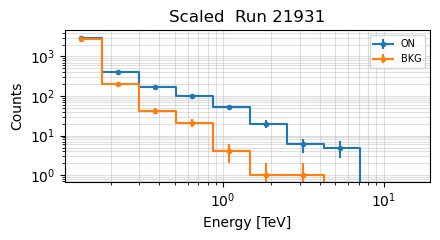


--- Run 21945 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    8287    7831   1.0000    456.00
     1      0.1699      0.2885    1740    1506   1.0000    234.00
     2      0.2885      0.4901     280      93   1.0000    187.00
     3      0.4901      0.8326     117      21   1.0000     96.00
     4      0.8326      1.4142      50      11   1.0000     39.00
     5      1.4142      2.4022      21       1   1.0000     20.00
     6      2.4022      4.0806      11       1   1.0000     10.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       3       0   1.0000      3.00
     9     11.7741     20.0000       0       0   1.0000      0.00


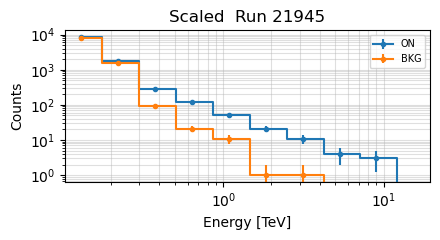


--- Run 21946 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    6194    5980   1.0000    214.00
     1      0.1699      0.2885     932     734   1.0000    198.00
     2      0.2885      0.4901     240      82   1.0000    158.00
     3      0.4901      0.8326     103      19   1.0000     84.00
     4      0.8326      1.4142      65       8   1.0000     57.00
     5      1.4142      2.4022      23       1   1.0000     22.00
     6      2.4022      4.0806      11       1   1.0000     10.00
     7      4.0806      6.9314       6       0   1.0000      6.00
     8      6.9314     11.7741       2       0   1.0000      2.00
     9     11.7741     20.0000       0       0   1.0000      0.00


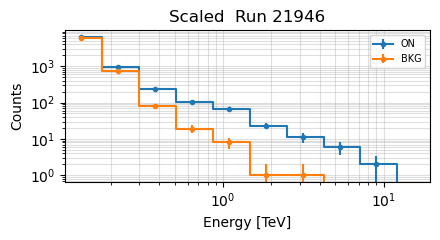


--- Run 22028 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    2682    2386   1.0000    296.00
     1      0.1699      0.2885     310     150   1.0000    160.00
     2      0.2885      0.4901     120      33   1.0000     87.00
     3      0.4901      0.8326      83      13   1.0000     70.00
     4      0.8326      1.4142      28       3   1.0000     25.00
     5      1.4142      2.4022      14       1   1.0000     13.00
     6      2.4022      4.0806      11       0   1.0000     11.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


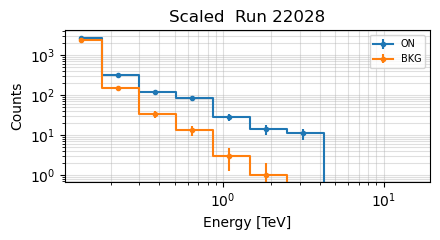


--- Run 22029 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1808    1621   1.0000    187.00
     1      0.1699      0.2885     303     110   1.0000    193.00
     2      0.2885      0.4901     121      29   1.0000     92.00
     3      0.4901      0.8326      75      12   1.0000     63.00
     4      0.8326      1.4142      37       3   1.0000     34.00
     5      1.4142      2.4022      18       0   1.0000     18.00
     6      2.4022      4.0806       8       0   1.0000      8.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


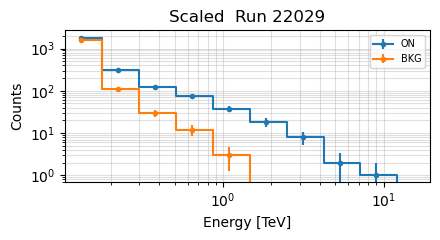


--- Run 22030 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1498    1332   1.0000    166.00
     1      0.1699      0.2885     252     118   1.0000    134.00
     2      0.2885      0.4901     134      28   1.0000    106.00
     3      0.4901      0.8326      53       7   1.0000     46.00
     4      0.8326      1.4142      33       1   1.0000     32.00
     5      1.4142      2.4022      13       0   1.0000     13.00
     6      2.4022      4.0806       9       0   1.0000      9.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


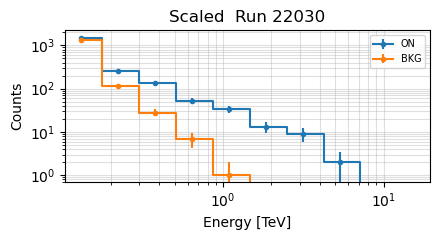


--- Run 22054 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699   12819   12521   1.0000    298.00
     1      0.1699      0.2885    3232    2928   1.0000    304.00
     2      0.2885      0.4901     445     208   1.0000    237.00
     3      0.4901      0.8326     196      41   1.0000    155.00
     4      0.8326      1.4142     104      13   1.0000     91.00
     5      1.4142      2.4022      47       5   1.0000     42.00
     6      2.4022      4.0806      16       0   1.0000     16.00
     7      4.0806      6.9314      10       0   1.0000     10.00
     8      6.9314     11.7741       4       0   1.0000      4.00
     9     11.7741     20.0000       0       0   1.0000      0.00


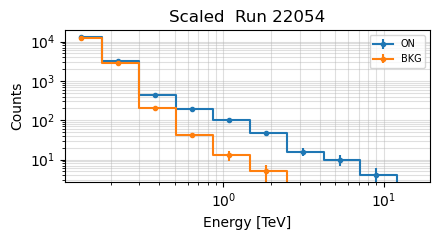


--- Run 22055 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    6705    6405   1.0000    300.00
     1      0.1699      0.2885    1126     924   1.0000    202.00
     2      0.2885      0.4901     251     126   1.0000    125.00
     3      0.4901      0.8326     124      13   1.0000    111.00
     4      0.8326      1.4142      71      11   1.0000     60.00
     5      1.4142      2.4022      16       1   1.0000     15.00
     6      2.4022      4.0806      14       0   1.0000     14.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       2       0   1.0000      2.00


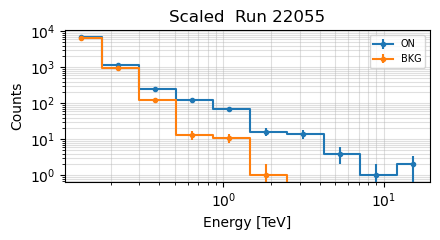


--- Run 22056 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    4836    4678   1.0000    158.00
     1      0.1699      0.2885     638     419   1.0000    219.00
     2      0.2885      0.4901     200      69   1.0000    131.00
     3      0.4901      0.8326     129      14   1.0000    115.00
     4      0.8326      1.4142      57       5   1.0000     52.00
     5      1.4142      2.4022      20       2   1.0000     18.00
     6      2.4022      4.0806      19       0   1.0000     19.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       2       0   1.0000      2.00


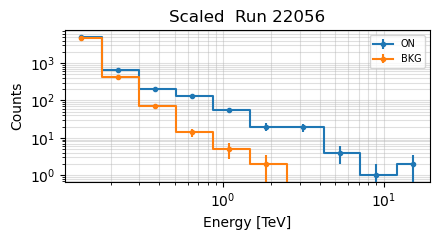


--- Run 22057 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    3691    3516   1.0000    175.00
     1      0.1699      0.2885     467     258   1.0000    209.00
     2      0.2885      0.4901     178      56   1.0000    122.00
     3      0.4901      0.8326     107      12   1.0000     95.00
     4      0.8326      1.4142      56       8   1.0000     48.00
     5      1.4142      2.4022      19       2   1.0000     17.00
     6      2.4022      4.0806      13       0   1.0000     13.00
     7      4.0806      6.9314       1       0   1.0000      1.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


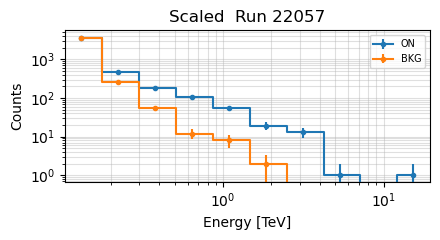


--- Run 22060 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     322     262   1.0000     60.00
     1      0.1699      0.2885      81      26   1.0000     55.00
     2      0.2885      0.4901      33      11   1.0000     22.00
     3      0.4901      0.8326      22       2   1.0000     20.00
     4      0.8326      1.4142      10       2   1.0000      8.00
     5      1.4142      2.4022       4       2   1.0000      2.00
     6      2.4022      4.0806       4       0   1.0000      4.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


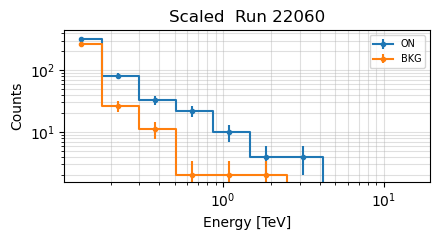


--- Run 22740 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    5025    5041   1.0000    -16.00
     1      0.1699      0.2885     763     588   1.0000    175.00
     2      0.2885      0.4901     169      67   1.0000    102.00
     3      0.4901      0.8326      94      13   1.0000     81.00
     4      0.8326      1.4142      40       4   1.0000     36.00
     5      1.4142      2.4022      19       1   1.0000     18.00
     6      2.4022      4.0806       7       1   1.0000      6.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


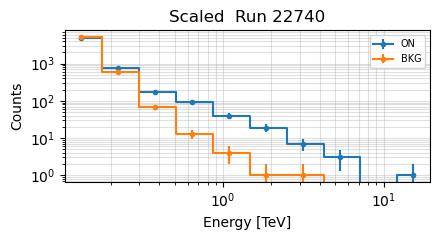


--- Run 22741 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    3742    3501   1.0000    241.00
     1      0.1699      0.2885     442     310   1.0000    132.00
     2      0.2885      0.4901     168      57   1.0000    111.00
     3      0.4901      0.8326      86      11   1.0000     75.00
     4      0.8326      1.4142      45       3   1.0000     42.00
     5      1.4142      2.4022      14       2   1.0000     12.00
     6      2.4022      4.0806       8       0   1.0000      8.00
     7      4.0806      6.9314       1       0   1.0000      1.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       2       0   1.0000      2.00


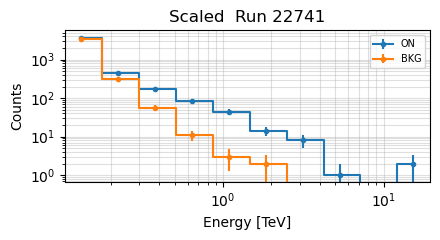


--- Run 22742 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    4416    4218   1.0000    198.00
     1      0.1699      0.2885     493     300   1.0000    193.00
     2      0.2885      0.4901     211      56   1.0000    155.00
     3      0.4901      0.8326     119      24   1.0000     95.00
     4      0.8326      1.4142      40       4   1.0000     36.00
     5      1.4142      2.4022      28       2   1.0000     26.00
     6      2.4022      4.0806      13       0   1.0000     13.00
     7      4.0806      6.9314       5       0   1.0000      5.00
     8      6.9314     11.7741       2       0   1.0000      2.00
     9     11.7741     20.0000       0       0   1.0000      0.00


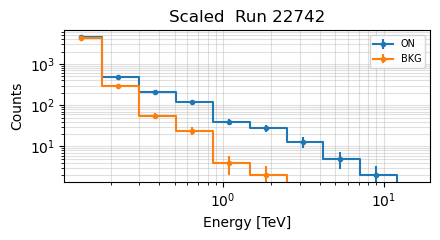


--- Run 22743 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    2847    2633   1.0000    214.00
     1      0.1699      0.2885     397     194   1.0000    203.00
     2      0.2885      0.4901     165      43   1.0000    122.00
     3      0.4901      0.8326      75      13   1.0000     62.00
     4      0.8326      1.4142      42       2   1.0000     40.00
     5      1.4142      2.4022      18       2   1.0000     16.00
     6      2.4022      4.0806       1       0   1.0000      1.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


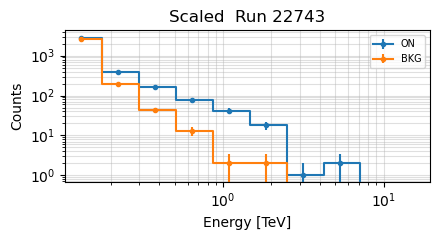


--- Run 22987 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1935    1804   1.0000    131.00
     1      0.1699      0.2885     276     146   1.0000    130.00
     2      0.2885      0.4901     114      27   1.0000     87.00
     3      0.4901      0.8326      48       8   1.0000     40.00
     4      0.8326      1.4142      28       2   1.0000     26.00
     5      1.4142      2.4022       4       1   1.0000      3.00
     6      2.4022      4.0806       4       1   1.0000      3.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       1       0   1.0000      1.00


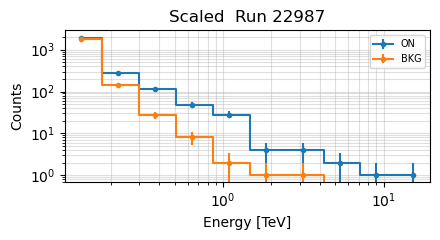


--- Run 22988 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1975    1738   1.0000    237.00
     1      0.1699      0.2885     300     132   1.0000    168.00
     2      0.2885      0.4901     121      32   1.0000     89.00
     3      0.4901      0.8326      60      10   1.0000     50.00
     4      0.8326      1.4142      20       2   1.0000     18.00
     5      1.4142      2.4022      10       0   1.0000     10.00
     6      2.4022      4.0806       6       0   1.0000      6.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


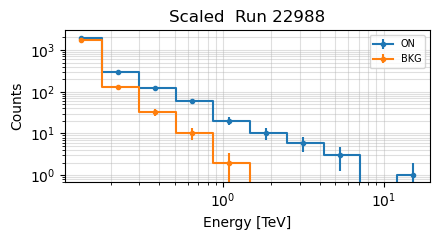


--- Run 22989 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1858    1709   1.0000    149.00
     1      0.1699      0.2885     286     163   1.0000    123.00
     2      0.2885      0.4901     106      19   1.0000     87.00
     3      0.4901      0.8326      58       6   1.0000     52.00
     4      0.8326      1.4142      26       1   1.0000     25.00
     5      1.4142      2.4022       6       0   1.0000      6.00
     6      2.4022      4.0806       2       0   1.0000      2.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


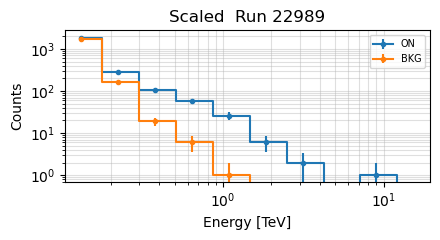


--- Run 22990 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1769    1625   1.0000    144.00
     1      0.1699      0.2885     274     112   1.0000    162.00
     2      0.2885      0.4901     112      24   1.0000     88.00
     3      0.4901      0.8326      42      11   1.0000     31.00
     4      0.8326      1.4142      23       3   1.0000     20.00
     5      1.4142      2.4022      13       0   1.0000     13.00
     6      2.4022      4.0806       4       0   1.0000      4.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


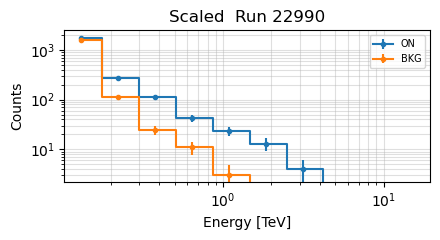


--- Run 23009 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1380    1141   1.0000    239.00
     1      0.1699      0.2885     277     133   1.0000    144.00
     2      0.2885      0.4901     131      32   1.0000     99.00
     3      0.4901      0.8326      60       5   1.0000     55.00
     4      0.8326      1.4142      31       1   1.0000     30.00
     5      1.4142      2.4022      12       0   1.0000     12.00
     6      2.4022      4.0806       6       0   1.0000      6.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       1       0   1.0000      1.00


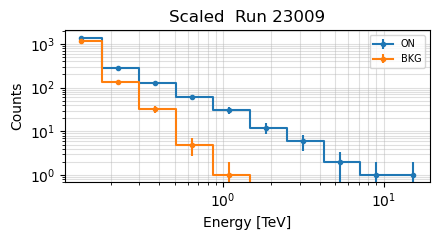


--- Run 23011 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1038     907   1.0000    131.00
     1      0.1699      0.2885     211      96   1.0000    115.00
     2      0.2885      0.4901      95      18   1.0000     77.00
     3      0.4901      0.8326      47       6   1.0000     41.00
     4      0.8326      1.4142      12       2   1.0000     10.00
     5      1.4142      2.4022       9       0   1.0000      9.00
     6      2.4022      4.0806       2       0   1.0000      2.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


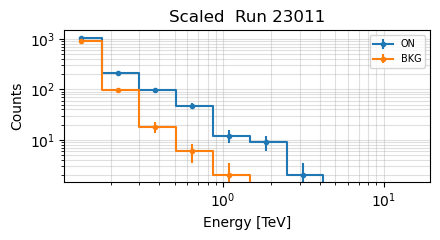


--- Run 23012 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1222    1060   1.0000    162.00
     1      0.1699      0.2885     231     110   1.0000    121.00
     2      0.2885      0.4901     100      18   1.0000     82.00
     3      0.4901      0.8326      53       8   1.0000     45.00
     4      0.8326      1.4142      16       4   1.0000     12.00
     5      1.4142      2.4022      10       0   1.0000     10.00
     6      2.4022      4.0806       2       0   1.0000      2.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


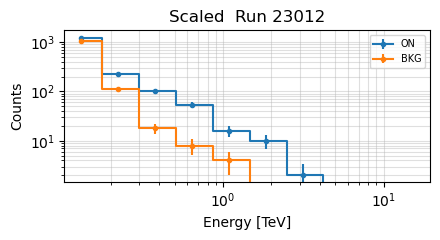


--- Run 23039 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1729    1545   1.0000    184.00
     1      0.1699      0.2885     205     116   1.0000     89.00
     2      0.2885      0.4901      93      24   1.0000     69.00
     3      0.4901      0.8326      51       8   1.0000     43.00
     4      0.8326      1.4142      24       1   1.0000     23.00
     5      1.4142      2.4022      12       0   1.0000     12.00
     6      2.4022      4.0806       5       0   1.0000      5.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


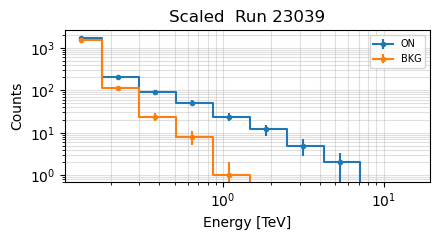


--- Run 23040 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    5119    4915   1.0000    204.00
     1      0.1699      0.2885     541     409   1.0000    132.00
     2      0.2885      0.4901     255      78   1.0000    177.00
     3      0.4901      0.8326     119      22   1.0000     97.00
     4      0.8326      1.4142      58       5   1.0000     53.00
     5      1.4142      2.4022      27       3   1.0000     24.00
     6      2.4022      4.0806       7       0   1.0000      7.00
     7      4.0806      6.9314       8       0   1.0000      8.00
     8      6.9314     11.7741       2       0   1.0000      2.00
     9     11.7741     20.0000       0       0   1.0000      0.00


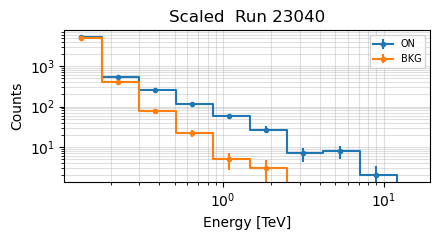


--- Run 23087 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699      66      36   1.0000     30.00
     1      0.1699      0.2885     311     236   1.0000     75.00
     2      0.2885      0.4901      83      37   1.0000     46.00
     3      0.4901      0.8326      38       6   1.0000     32.00
     4      0.8326      1.4142      13       2   1.0000     11.00
     5      1.4142      2.4022      16       0   1.0000     16.00
     6      2.4022      4.0806       2       0   1.0000      2.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       0       1   1.0000     -1.00
     9     11.7741     20.0000       2       0   1.0000      2.00


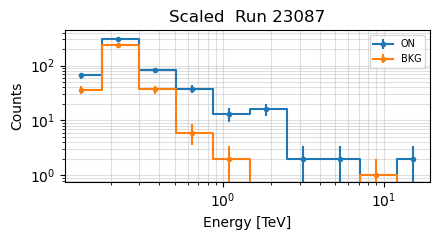


--- Run 23088 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     263     163   1.0000    100.00
     1      0.1699      0.2885     506     408   1.0000     98.00
     2      0.2885      0.4901     122      33   1.0000     89.00
     3      0.4901      0.8326      62       8   1.0000     54.00
     4      0.8326      1.4142      27       3   1.0000     24.00
     5      1.4142      2.4022      21       0   1.0000     21.00
     6      2.4022      4.0806       7       0   1.0000      7.00
     7      4.0806      6.9314       1       0   1.0000      1.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


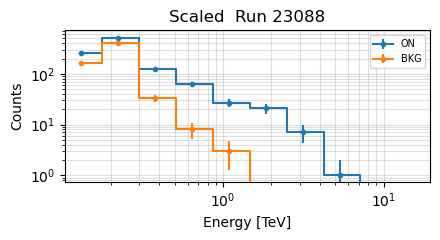


--- Run 23089 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     757     768   1.0000    -11.00
     1      0.1699      0.2885     392     267   1.0000    125.00
     2      0.2885      0.4901     102      30   1.0000     72.00
     3      0.4901      0.8326      65      10   1.0000     55.00
     4      0.8326      1.4142      25       3   1.0000     22.00
     5      1.4142      2.4022      13       1   1.0000     12.00
     6      2.4022      4.0806       5       0   1.0000      5.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


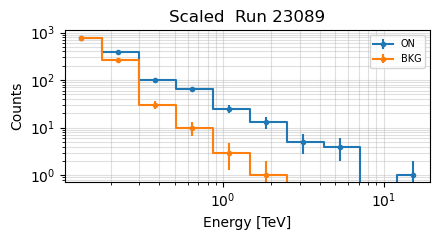


--- Run 23090 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1522    1292   1.0000    230.00
     1      0.1699      0.2885     380     268   1.0000    112.00
     2      0.2885      0.4901     135      32   1.0000    103.00
     3      0.4901      0.8326      58      10   1.0000     48.00
     4      0.8326      1.4142      40       3   1.0000     37.00
     5      1.4142      2.4022      18       0   1.0000     18.00
     6      2.4022      4.0806      11       0   1.0000     11.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       2       0   1.0000      2.00
     9     11.7741     20.0000       1       0   1.0000      1.00


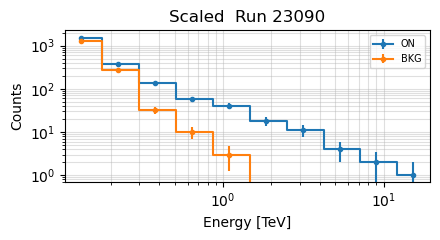


--- Run 23093 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     697     597   1.0000    100.00
     1      0.1699      0.2885     128      60   1.0000     68.00
     2      0.2885      0.4901      61      10   1.0000     51.00
     3      0.4901      0.8326      28       4   1.0000     24.00
     4      0.8326      1.4142      14       0   1.0000     14.00
     5      1.4142      2.4022       8       0   1.0000      8.00
     6      2.4022      4.0806       4       0   1.0000      4.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


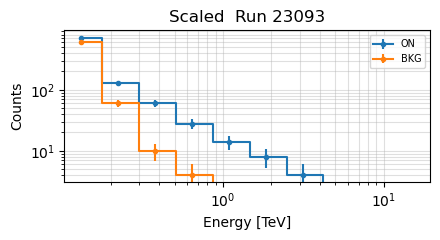


--- Run 23094 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     487     409   1.0000     78.00
     1      0.1699      0.2885     105      48   1.0000     57.00
     2      0.2885      0.4901      46      12   1.0000     34.00
     3      0.4901      0.8326      21       5   1.0000     16.00
     4      0.8326      1.4142       8       0   1.0000      8.00
     5      1.4142      2.4022       6       1   1.0000      5.00
     6      2.4022      4.0806       1       1   1.0000      0.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


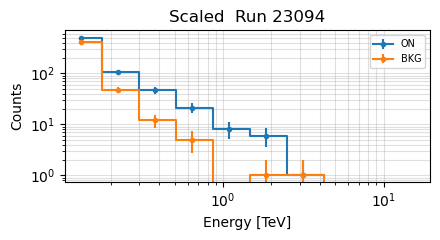


--- Run 23095 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     918     783   1.0000    135.00
     1      0.1699      0.2885     195      70   1.0000    125.00
     2      0.2885      0.4901      85      15   1.0000     70.00
     3      0.4901      0.8326      44       2   1.0000     42.00
     4      0.8326      1.4142      30       1   1.0000     29.00
     5      1.4142      2.4022      10       0   1.0000     10.00
     6      2.4022      4.0806       4       0   1.0000      4.00
     7      4.0806      6.9314       1       0   1.0000      1.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


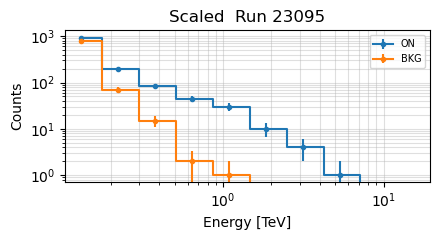


--- Run 23492 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    2378    2348   1.0000     30.00
     1      0.1699      0.2885     287     181   1.0000    106.00
     2      0.2885      0.4901     120      28   1.0000     92.00
     3      0.4901      0.8326      76       9   1.0000     67.00
     4      0.8326      1.4142      20       8   1.0000     12.00
     5      1.4142      2.4022      17       1   1.0000     16.00
     6      2.4022      4.0806       2       0   1.0000      2.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


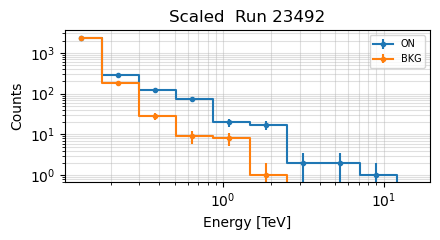


--- Run 23493 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1923    1712   1.0000    211.00
     1      0.1699      0.2885     257     122   1.0000    135.00
     2      0.2885      0.4901     122      28   1.0000     94.00
     3      0.4901      0.8326      80       5   1.0000     75.00
     4      0.8326      1.4142      38       4   1.0000     34.00
     5      1.4142      2.4022      12       1   1.0000     11.00
     6      2.4022      4.0806       9       0   1.0000      9.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


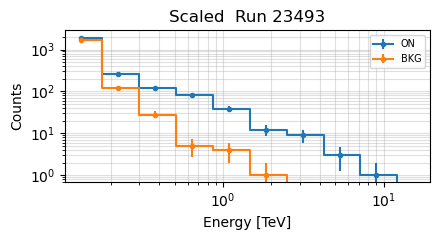


--- Run 23559 ---
  OFF regions found : 1
  Safe mask coverage: 90.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699     619     734   1.0000   -115.00
     1      0.1699      0.2885     697     766   1.0000    -69.00
     2      0.2885      0.4901      80      59   1.0000     21.00
     3      0.4901      0.8326      35       8   1.0000     27.00
     4      0.8326      1.4142      10       1   1.0000      9.00
     5      1.4142      2.4022      10       1   1.0000      9.00
     6      2.4022      4.0806       4       0   1.0000      4.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


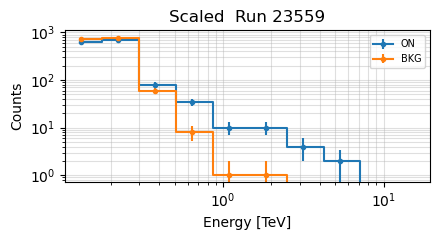


--- Run 23656 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1446    1248   1.0000    198.00
     1      0.1699      0.2885     336     168   1.0000    168.00
     2      0.2885      0.4901     184      33   1.0000    151.00
     3      0.4901      0.8326      88       9   1.0000     79.00
     4      0.8326      1.4142      37       2   1.0000     35.00
     5      1.4142      2.4022      16       0   1.0000     16.00
     6      2.4022      4.0806       4       0   1.0000      4.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


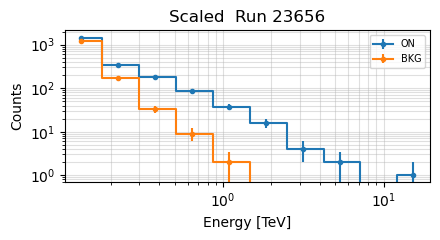


--- Run 23657 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1554    1298   1.0000    256.00
     1      0.1699      0.2885     306     124   1.0000    182.00
     2      0.2885      0.4901     149      42   1.0000    107.00
     3      0.4901      0.8326      70       9   1.0000     61.00
     4      0.8326      1.4142      36       4   1.0000     32.00
     5      1.4142      2.4022      12       0   1.0000     12.00
     6      2.4022      4.0806       3       0   1.0000      3.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       2       0   1.0000      2.00
     9     11.7741     20.0000       0       0   1.0000      0.00


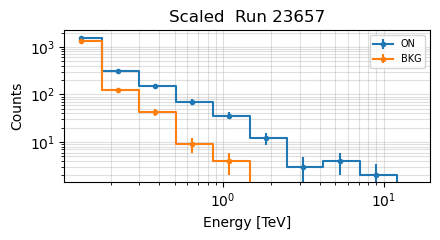


--- Run 23658 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1612    1380   1.0000    232.00
     1      0.1699      0.2885     302     132   1.0000    170.00
     2      0.2885      0.4901     129      36   1.0000     93.00
     3      0.4901      0.8326      62      10   1.0000     52.00
     4      0.8326      1.4142      24       4   1.0000     20.00
     5      1.4142      2.4022       8       1   1.0000      7.00
     6      2.4022      4.0806       7       0   1.0000      7.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


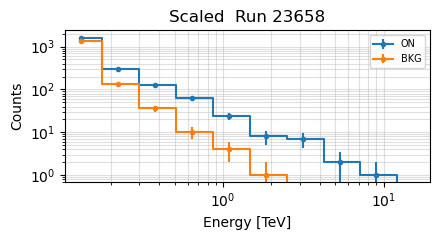


--- Run 23659 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    2152    1910   1.0000    242.00
     1      0.1699      0.2885     352     162   1.0000    190.00
     2      0.2885      0.4901     150      34   1.0000    116.00
     3      0.4901      0.8326      87      15   1.0000     72.00
     4      0.8326      1.4142      43       5   1.0000     38.00
     5      1.4142      2.4022      23       0   1.0000     23.00
     6      2.4022      4.0806       6       0   1.0000      6.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       1       0   1.0000      1.00


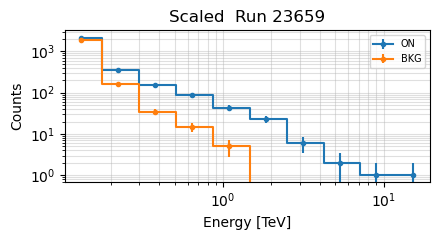


--- Run 23660 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    2978    2836   1.0000    142.00
     1      0.1699      0.2885     374     197   1.0000    177.00
     2      0.2885      0.4901     169      57   1.0000    112.00
     3      0.4901      0.8326      78      11   1.0000     67.00
     4      0.8326      1.4142      35       3   1.0000     32.00
     5      1.4142      2.4022      17       1   1.0000     16.00
     6      2.4022      4.0806       7       0   1.0000      7.00
     7      4.0806      6.9314       3       1   1.0000      2.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


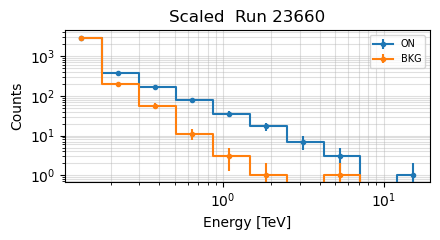


--- Run 23661 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    3675    3281   1.0000    394.00
     1      0.1699      0.2885     453     284   1.0000    169.00
     2      0.2885      0.4901     205      53   1.0000    152.00
     3      0.4901      0.8326      91      12   1.0000     79.00
     4      0.8326      1.4142      44       4   1.0000     40.00
     5      1.4142      2.4022      21       2   1.0000     19.00
     6      2.4022      4.0806       9       0   1.0000      9.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


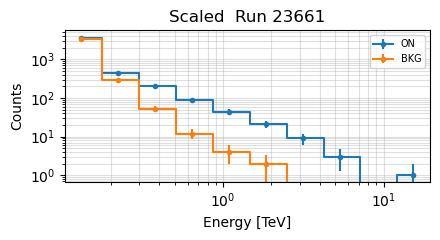


--- Run 23662 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    1270    1226   1.0000     44.00
     1      0.1699      0.2885     184     112   1.0000     72.00
     2      0.2885      0.4901      60      25   1.0000     35.00
     3      0.4901      0.8326      30       7   1.0000     23.00
     4      0.8326      1.4142       9       1   1.0000      8.00
     5      1.4142      2.4022       7       0   1.0000      7.00
     6      2.4022      4.0806       4       1   1.0000      3.00
     7      4.0806      6.9314       0       0   1.0000      0.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


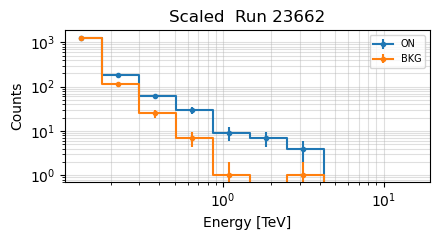


--- Run 23664 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    7993    7960   1.0000     33.00
     1      0.1699      0.2885    1661    1414   1.0000    247.00
     2      0.2885      0.4901     292     103   1.0000    189.00
     3      0.4901      0.8326     128      30   1.0000     98.00
     4      0.8326      1.4142      69       9   1.0000     60.00
     5      1.4142      2.4022      44       3   1.0000     41.00
     6      2.4022      4.0806      13       1   1.0000     12.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       2       0   1.0000      2.00


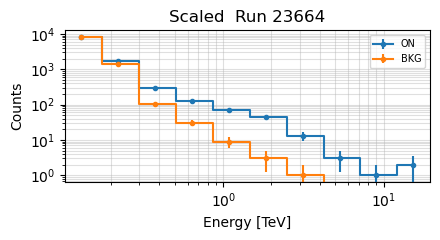


--- Run 23665 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699   10041    9584   1.0000    457.00
     1      0.1699      0.2885    2690    2398   1.0000    292.00
     2      0.2885      0.4901     356     179   1.0000    177.00
     3      0.4901      0.8326     162      25   1.0000    137.00
     4      0.8326      1.4142      69       7   1.0000     62.00
     5      1.4142      2.4022      31       2   1.0000     29.00
     6      2.4022      4.0806      16       1   1.0000     15.00
     7      4.0806      6.9314       8       1   1.0000      7.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       2       0   1.0000      2.00


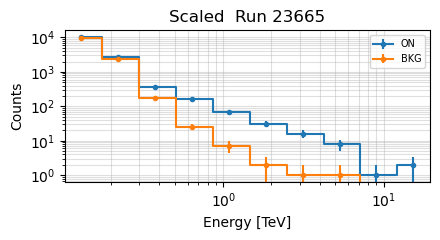


--- Run 23896 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    2139    1879   1.0000    260.00
     1      0.1699      0.2885     489     449   1.0000     40.00
     2      0.2885      0.4901      86      41   1.0000     45.00
     3      0.4901      0.8326      28       9   1.0000     19.00
     4      0.8326      1.4142      28       1   1.0000     27.00
     5      1.4142      2.4022      10       0   1.0000     10.00
     6      2.4022      4.0806       4       0   1.0000      4.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


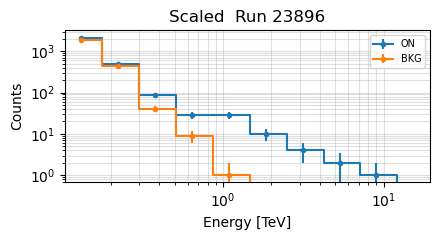


--- Run 23897 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    2885    3405   1.0000   -520.00
     1      0.1699      0.2885    1173    1169   1.0000      4.00
     2      0.2885      0.4901     162      96   1.0000     66.00
     3      0.4901      0.8326      76       9   1.0000     67.00
     4      0.8326      1.4142      42       4   1.0000     38.00
     5      1.4142      2.4022      24       0   1.0000     24.00
     6      2.4022      4.0806       7       1   1.0000      6.00
     7      4.0806      6.9314       3       1   1.0000      2.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       1       0   1.0000      1.00


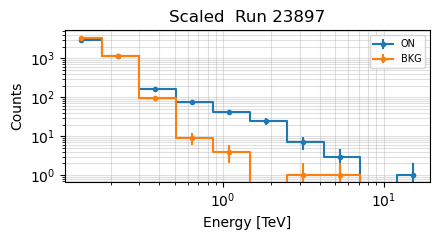


--- Run 23955 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    4589    4416   1.0000    173.00
     1      0.1699      0.2885     709     604   1.0000    105.00
     2      0.2885      0.4901     150      56   1.0000     94.00
     3      0.4901      0.8326      64      15   1.0000     49.00
     4      0.8326      1.4142      42       2   1.0000     40.00
     5      1.4142      2.4022      13       1   1.0000     12.00
     6      2.4022      4.0806       9       1   1.0000      8.00
     7      4.0806      6.9314       2       0   1.0000      2.00
     8      6.9314     11.7741       4       1   1.0000      3.00
     9     11.7741     20.0000       0       0   1.0000      0.00


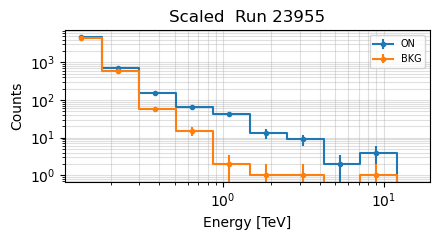


--- Run 23956 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    9115    9399   1.0000   -284.00
     1      0.1699      0.2885    2158    1962   1.0000    196.00
     2      0.2885      0.4901     308     121   1.0000    187.00
     3      0.4901      0.8326     142      28   1.0000    114.00
     4      0.8326      1.4142      69      17   1.0000     52.00
     5      1.4142      2.4022      35       2   1.0000     33.00
     6      2.4022      4.0806      10       0   1.0000     10.00
     7      4.0806      6.9314       1       1   1.0000      0.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


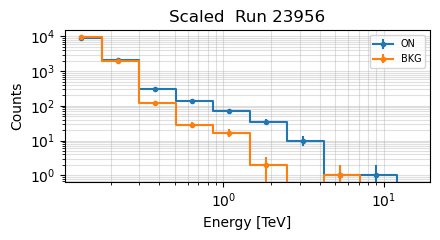


--- Run 23992 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    3372    3242   1.0000    130.00
     1      0.1699      0.2885     347     239   1.0000    108.00
     2      0.2885      0.4901     138      32   1.0000    106.00
     3      0.4901      0.8326      51      16   1.0000     35.00
     4      0.8326      1.4142      34       1   1.0000     33.00
     5      1.4142      2.4022      19       0   1.0000     19.00
     6      2.4022      4.0806       3       0   1.0000      3.00
     7      4.0806      6.9314       4       0   1.0000      4.00
     8      6.9314     11.7741       0       0   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


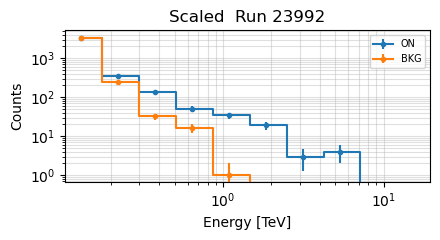


--- Run 23993 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    6165    5714   1.0000    451.00
     1      0.1699      0.2885     754     602   1.0000    152.00
     2      0.2885      0.4901     216      64   1.0000    152.00
     3      0.4901      0.8326     107      10   1.0000     97.00
     4      0.8326      1.4142      60       8   1.0000     52.00
     5      1.4142      2.4022      19       1   1.0000     18.00
     6      2.4022      4.0806      14       1   1.0000     13.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       1       0   1.0000      1.00
     9     11.7741     20.0000       0       0   1.0000      0.00


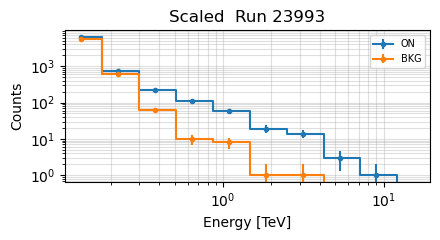


--- Run 23994 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699    7223    7250   1.0000    -27.00
     1      0.1699      0.2885    1162    1010   1.0000    152.00
     2      0.2885      0.4901     234      85   1.0000    149.00
     3      0.4901      0.8326      98      15   1.0000     83.00
     4      0.8326      1.4142      48       4   1.0000     44.00
     5      1.4142      2.4022      23       1   1.0000     22.00
     6      2.4022      4.0806      17       0   1.0000     17.00
     7      4.0806      6.9314       3       0   1.0000      3.00
     8      6.9314     11.7741       4       0   1.0000      4.00
     9     11.7741     20.0000       2       0   1.0000      2.00


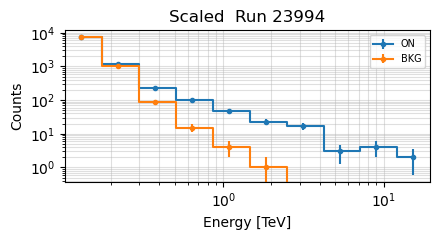


--- Run 23995 ---
  OFF regions found : 1
  Safe mask coverage: 100.0%
   bin  E_lo [TeV]  E_hi [TeV]      ON     OFF    alpha    excess
     0      0.1000      0.1699   10906   10849   1.0000     57.00
     1      0.1699      0.2885    2903    2669   1.0000    234.00
     2      0.2885      0.4901     330     184   1.0000    146.00
     3      0.4901      0.8326     151      37   1.0000    114.00
     4      0.8326      1.4142      59       9   1.0000     50.00
     5      1.4142      2.4022      33       2   1.0000     31.00
     6      2.4022      4.0806      15       0   1.0000     15.00
     7      4.0806      6.9314       5       0   1.0000      5.00
     8      6.9314     11.7741       1       1   1.0000      0.00
     9     11.7741     20.0000       0       0   1.0000      0.00


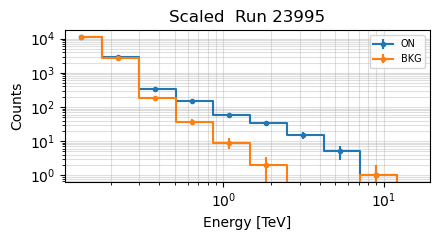


  Added 56 / 56 Scaled runs.
  No runs skipped.


In [12]:
print("="*62)
print(f"  Building SCALED datasets  ({len(OBS_IDS)} runs)")
print("="*62)

datasets_scaled = Datasets()
skipped_scaled  = []

for obs_id, obs in zip(OBS_IDS, obs_scaled):
    print(f"\n--- Run {obs_id} ---")

    dataset        = maker.run(dataset_empty.copy(name=str(obs_id)), obs)
    dataset_on_off = maker_bkg.run(dataset=dataset, observation=obs)

    if dataset_on_off.counts_off is None:
        print(f"  FAILED: Background estimation returned None — run skipped.")
        skipped_scaled.append(obs_id)
        continue

    n_off_found    = len(compound_region_to_regions(dataset_on_off.counts_off.geom.region))
    dataset_on_off = maker_safe_mask.run(dataset_on_off, obs)
    safe_frac      = dataset_on_off.mask_safe.data.mean()

    print(f"  OFF regions found : {n_off_found}")
    print(f"  Safe mask coverage: {safe_frac*100:.1f}%")

    c_on   = dataset_on_off.counts.data.reshape(n_ebins)
    c_off  = dataset_on_off.counts_off.data.reshape(n_ebins)
    alpha  = dataset_on_off.alpha.data.reshape(n_ebins)
    bkg    = c_off * alpha
    excess = c_on - bkg

    print(f"  {'bin':>4s}  {'E_lo [TeV]':>10s}  {'E_hi [TeV]':>10s}  {'ON':>6s}  {'OFF':>6s}  {'alpha':>7s}  {'excess':>8s}")
    for i in range(n_ebins):
        print(f"  {i:>4d}  {energy_axis.edges[i].value:>10.4f}  {energy_axis.edges[i+1].value:>10.4f}"
              f"  {int(c_on[i]):>6d}  {int(c_off[i]):>6d}  {alpha[i]:>7.4f}  {excess[i]:>8.2f}")

    fig, ax = plt.subplots(figsize=(4.5, 2.5))
    ax.errorbar(energy_axis.center.value, c_on,  yerr=np.sqrt(c_on),  ds="steps-mid", label="ON",  marker=".")
    ax.errorbar(energy_axis.center.value, bkg,   yerr=np.sqrt(bkg),   ds="steps-mid", label="BKG", marker=".")
    ax.set(xscale="log", xlabel="Energy [TeV]", ylabel="Counts", yscale="log", title=f"{LABEL_SCALED}  Run {obs_id}")
    ax.legend(fontsize=7); ax.grid(True, which="both", alpha=0.4)
    plt.tight_layout(); plt.show()

    datasets_scaled.append(dataset_on_off)

print("\n" + "="*62)
print(f"  Added {len(datasets_scaled)} / {len(OBS_IDS)} Scaled runs.")
if skipped_scaled:
    print(f"  Skipped: {skipped_scaled}")
else:
    print("  No runs skipped.")
print("="*62)

In [13]:
# Verify both collections are symmetric before continuing
n_std    = len(datasets_std)
n_scaled = len(datasets_scaled)

print(f"Standard  datasets : {n_std}")
print(f"Scaled    datasets : {n_scaled}")

names_std    = set(d.name for d in datasets_std)
names_scaled = set(d.name for d in datasets_scaled)
only_in_std    = names_std    - names_scaled
only_in_scaled = names_scaled - names_std

if only_in_std:
    print(f"WARNING  In Standard but not Scaled : {only_in_std}")
if only_in_scaled:
    print(f"WARNING  In Scaled but not Standard : {only_in_scaled}")
if not only_in_std and not only_in_scaled:
    print("OK  Both collections contain the same runs.")

Standard  datasets : 56
Scaled    datasets : 56
OK  Both collections contain the same runs.


---
## 6 · Stacking & cumulative excess / significance checks

In [14]:
stacked_std    = datasets_std.copy().stack_reduce()
stacked_scaled = datasets_scaled.copy().stack_reduce()

info_std    = datasets_std.info_table(cumulative=True)
info_scaled = datasets_scaled.info_table(cumulative=True)

print("Standard info table (cumulative):")
display(info_std)
print("\nScaled info table (cumulative):")
display(info_scaled)

Standard info table (cumulative):


name,counts,excess,sqrt_ts,background,npred,npred_background,npred_signal,exposure_min,exposure_max,livetime,ontime,counts_rate,background_rate,excess_rate,n_bins,n_fit_bins,stat_type,stat_sum,counts_off,acceptance,acceptance_off,alpha
,,,,,,,,m2 s,m2 s,s,s,1 / s,1 / s,1 / s,,,,,,,,
str7,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str5,float64,int64,float64,float64,float64
stacked,1490,173.0,3.2663486034786393,1317.0,1403.5,1403.5,nan,6631885.0,162161536.0,517.4259196911983,522.9901347160297,2.8796392745250134,2.545291895670767,0.33434737885424654,10,10,wstat,89.156051553815,1317,10.0,10.0,1.0
stacked,14226,1050.0,6.34382701844588,13176.0,13701.0,13701.0,nan,29977684.0,600102528.0,1667.5750655650133,1727.2044058144043,8.53095029648929,7.901293484222052,0.62965681226724,10,10,wstat,344.0126381226119,13176,20.0,20.0,1.0
stacked,22559,1545.0,7.402275968781682,21014.0,21786.5,21786.5,nan,55602488.0,981433984.0,2813.9423694826983,2931.0241759419314,8.016866388115524,7.467814631848027,0.5490517562674979,10,10,wstat,572.1125793616674,21014,30.0,30.0,1.0
stacked,28587,2444.0,10.448662293364949,26143.0,27365.0,27365.0,nan,84430344.0,1311549184.0,3958.176420435751,4133.525202810743,7.222265246290586,6.604809190673201,0.6174560556173853,10,10,wstat,892.3196390473071,26143,40.0,40.0,1.0
stacked,33326,3235.0,12.848892392241993,30091.0,31708.5,31708.5,nan,115871472.0,1611494016.0,5106.1145963160125,5344.3843470513675,6.5266846976063215,5.89313056579463,0.6335541318116921,10,10,wstat,1125.821128257283,30091,50.0,50.0,1.0
stacked,37013,3921.0,14.812749259418707,33092.0,35052.5,35052.5,nan,150034304.0,1873811584.0,6250.371220665263,6551.502620041358,5.921728277134314,5.294405537160692,0.6273227399736212,10,10,wstat,1383.092762713701,33092,60.0,60.0,1.0
stacked,47305,5057.0,16.903179634332982,42248.0,44776.5,44776.5,nan,173907008.0,2279080704.0,7371.103009000732,7730.923340618598,6.41762839865847,5.731570966843316,0.6860574318151546,10,10,wstat,1637.577608159469,42248,70.0,70.0,1.0
stacked,54533,5821.0,18.12083658846452,48712.0,51622.5,51622.5,nan,200490480.0,2637481216.0,8512.299113054745,8937.28516966103,6.406377322475238,5.722543269807526,0.6838340526677124,10,10,wstat,1911.5767980646979,48712,80.0,80.0,1.0



Scaled info table (cumulative):


name,counts,excess,sqrt_ts,background,npred,npred_background,npred_signal,exposure_min,exposure_max,livetime,ontime,counts_rate,background_rate,excess_rate,n_bins,n_fit_bins,stat_type,stat_sum,counts_off,acceptance,acceptance_off,alpha
,,,,,,,,m2 s,m2 s,s,s,1 / s,1 / s,1 / s,,,,,,,,
str7,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str5,float64,int64,float64,float64,float64
stacked,1634,189.0,3.407167536377274,1445.0,1539.5,1539.5,nan,6631749.0,162165008.0,517.4284453095013,522.9922599792463,3.1579245687248956,2.792656671852799,0.3652678968720962,10,10,wstat,95.13757797004625,1445,10.0,10.0,1.0
stacked,14529,1128.0,6.750449508487523,13401.0,13965.0,13965.0,nan,29975544.0,600169024.0,1667.5804856902585,1727.2065310776206,8.71262294364523,8.036193823923856,0.6764291197213723,10,10,wstat,372.73577793293987,13401,20.0,20.0,1.0
stacked,23001,1607.0,7.62774712439997,21394.0,22197.5,22197.5,nan,55601340.0,981470080.0,2813.9460838240466,2931.027562648053,8.173930599531072,7.602846452170242,0.5710841473608291,10,10,wstat,590.6463029862987,21394,30.0,30.0,1.0
stacked,29057,2489.0,10.555100991849518,26568.0,27812.5,27812.5,nan,84427504.0,1311608192.0,3958.1819734538985,4133.5285895168645,7.340996496592334,6.712172451439073,0.6288240451532615,10,10,wstat,904.0894340543092,26568,40.0,40.0,1.0
stacked,33816,3264.0,12.867917812652736,30552.0,32184.0,32184.0,nan,115872088.0,1611517056.0,5106.120493925311,5344.387733757489,6.622640425393501,5.983407566732383,0.6392328586611187,10,10,wstat,1142.0404266994276,30552,50.0,50.0,1.0
stacked,37583,3957.0,14.832367275737614,33626.0,35604.5,35604.5,nan,150035568.0,1873824384.0,6250.379656052479,6551.506006747479,6.012914745683802,5.379833202202153,0.6330815434816487,10,10,wstat,1401.370393699189,33626,60.0,60.0,1.0
stacked,48096,5006.0,16.581963037545997,43090.0,45593.0,45593.0,nan,173906416.0,2279141120.0,7371.1077832586525,7730.923827916382,6.524935113448783,5.8457970317387735,0.6791380817100092,10,10,wstat,1660.232064712566,43090,70.0,70.0,1.0
stacked,55672,5757.0,17.721427251678872,49915.0,52793.5,52793.5,nan,200492896.0,2637487616.0,8512.296435193193,8937.285656958817,6.540185768182365,5.863870035544308,0.6763157326380563,10,10,wstat,1927.9761491800077,49915,80.0,80.0,1.0


Stacked Standard dataset


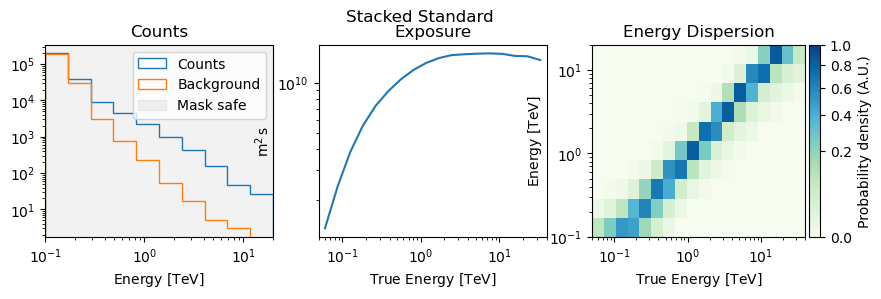

Stacked Scaled dataset


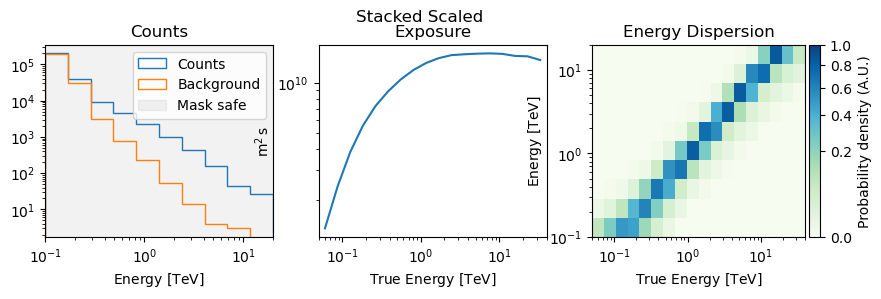

In [15]:
print("Stacked Standard dataset")
stacked_std.peek(figsize=(10, 2.5))
plt.suptitle("Stacked Standard", y=1.02)
plt.show()

print("Stacked Scaled dataset")
stacked_scaled.peek(figsize=(10, 2.5))
plt.suptitle("Stacked Scaled", y=1.02)
plt.show()

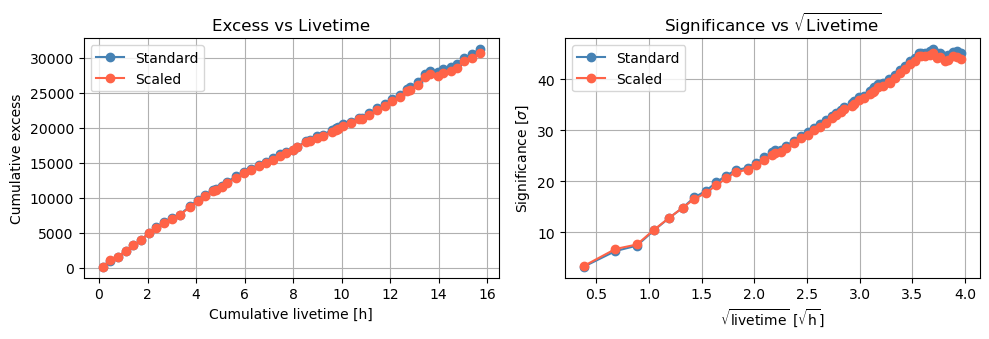

Dataset         Total excess    Significance [sigma]
Standard             31225.0                   45.21
Scaled               30635.0                   44.04


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for info, label, color in [
    (info_std,    LABEL_STD,    COLOR_STD),
    (info_scaled, LABEL_SCALED, COLOR_SCALED),
]:
    ltime = info["livetime"].to("h")
    axes[0].plot(ltime,          info["excess"],  "o-", color=color, label=label)
    axes[1].plot(np.sqrt(ltime), info["sqrt_ts"], "o-", color=color, label=label)

axes[0].set_xlabel("Cumulative livetime [h]")
axes[0].set_ylabel("Cumulative excess")
axes[0].set_title("Excess vs Livetime")

axes[1].set_xlabel(r"$\sqrt{\mathrm{livetime}}$ [$\sqrt{\mathrm{h}}$]")
axes[1].set_ylabel(r"Significance [$\sigma$]")
axes[1].set_title(r"Significance vs $\sqrt{\mathrm{Livetime}}$")

for ax in axes:
    ax.legend(); ax.grid()

plt.tight_layout()
plt.show()

print(f"{'Dataset':12s}  {'Total excess':>14s}  {'Significance [sigma]':>22s}")
for info, label in [(info_std, LABEL_STD), (info_scaled, LABEL_SCALED)]:
    print(f"{label:12s}  {info['excess'][-1]:>14.1f}  {info['sqrt_ts'][-1]:>22.2f}")

---
## 7 · Pivot energy & spectral model

The decorrelation energy is computed from the **Standard stacked dataset** so both datasets share the same reference for direct comparison.

In [17]:
# PWL fit on stacked Standard to extract pivot energy
_spec_pwl  = PowerLawSpectralModel(
    index=2,
    amplitude=2e-11 * u.Unit("cm-2 s-1 TeV-1"),
    reference=E_REF_INIT * u.TeV,
)
_model_pwl = SkyModel(spectral_model=_spec_pwl, name=SOURCE_NAME)
_ds_check  = stacked_std.copy(name="pivot_check")
_ds_check.models = _model_pwl

_fit_pwl = Fit()
_fit_pwl.run(datasets=_ds_check)

ref_energy = _spec_pwl.pivot_energy
print(f"Pivot (decorrelation) energy: {ref_energy.to(u.TeV):.3f}")
print("This reference energy will be used for both datasets.")

Pivot (decorrelation) energy: 0.581 TeV
This reference energy will be used for both datasets.


In [18]:
# LogParabola template — deepcopy when assigning to each dataset
spectral_model_template = LogParabolaSpectralModel(reference=ref_energy)
spectral_model_template.amplitude.min = 1e-26
spectral_model_template.amplitude.max = 1e-8
spectral_model_template.alpha.min     = 0.0
spectral_model_template.beta.min      = 0.0

print("Spectral model template (LogParabola):")
display(spectral_model_template.parameters.to_table())

# Crab reference
crab_model = LogParabolaSpectralModel(
    amplitude = 3.48e-11 * u.Unit("cm-2 s-1 TeV-1"),
    reference = 1.0 * u.TeV,
    alpha     = 2.49 * u.Unit(""),
    beta      = 0.117 * u.Unit(""),
)
print("\nCrab reference (MCP Performance paper):")
display(crab_model.parameters.to_table())

Spectral model template (LogParabola):


type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,amplitude,1.0000e-12,TeV-1 s-1 cm-2,0.000e+00,1.000e-26,1.000e-08,False,,
,reference,5.8069e-01,TeV,0.000e+00,nan,nan,True,,
,alpha,2.0000e+00,,0.000e+00,0.000e+00,nan,False,,
,beta,1.0000e+00,,0.000e+00,0.000e+00,nan,False,,



Crab reference (MCP Performance paper):


type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,amplitude,3.4800e-11,TeV-1 s-1 cm-2,0.000e+00,nan,nan,False,,
,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,
,alpha,2.4900e+00,,0.000e+00,nan,nan,False,,
,beta,1.1700e-01,,0.000e+00,nan,nan,False,,


---
## 8 · SED — fit on both datasets independently

In [19]:
fpe = FluxPointsEstimator(
    energy_edges       = energy_axis.edges,
    reoptimize         = False,
    source             = SOURCE_NAME,
    selection_optional = "all",
    n_sigma_ul         = 2,
)
print(f"FluxPointsEstimator: {len(energy_axis.edges)-1} energy bins, n_sigma_ul=2")

FluxPointsEstimator: 10 energy bins, n_sigma_ul=2


In [20]:
%%time
print(f"--- SED fit: {LABEL_STD} ---")

model_best_std   = SkyModel(spectral_model=spectral_model_template.copy(), name=SOURCE_NAME)
datasets_std.models = model_best_std

fit_std    = Fit()
result_std = fit_std.run(datasets=datasets_std)

print(f"  Converged  : {result_std.success}")
print(f"  Total stat : {result_std.total_stat:.3f}")
display(model_best_std.parameters.to_table())

fp_std         = fpe.run(datasets=datasets_std)
fp_dataset_std = FluxPointsDataset(data=fp_std, models=model_best_std)
print("Flux points computed.")

--- SED fit: Standard ---
  Converged  : True
  Total stat : 898.625


type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,amplitude,1.4109e-10,TeV-1 s-1 cm-2,1.768e-12,1.000e-26,1.000e-08,False,,
,reference,5.8069e-01,TeV,0.000e+00,nan,nan,True,,
,alpha,2.4019e+00,,1.332e-02,0.000e+00,nan,False,,
,beta,1.5392e-01,,1.192e-02,0.000e+00,nan,False,,


Flux points computed.
CPU times: user 10min 3s, sys: 1min 18s, total: 11min 21s
Wall time: 11min 22s


In [21]:
%%time
print(f"--- SED fit: {LABEL_SCALED} ---")

model_best_scaled   = SkyModel(spectral_model=spectral_model_template.copy(), name=SOURCE_NAME)
datasets_scaled.models = model_best_scaled

fit_scaled    = Fit()
result_scaled = fit_scaled.run(datasets=datasets_scaled)

print(f"  Converged  : {result_scaled.success}")
print(f"  Total stat : {result_scaled.total_stat:.3f}")
display(model_best_scaled.parameters.to_table())

fp_scaled         = fpe.run(datasets=datasets_scaled)
fp_dataset_scaled = FluxPointsDataset(data=fp_scaled, models=model_best_scaled)
print("Flux points computed.")

--- SED fit: Scaled ---
  Converged  : True
  Total stat : 825.276


type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,amplitude,1.4195e-10,TeV-1 s-1 cm-2,1.772e-12,1.000e-26,1.000e-08,False,,
,reference,5.8069e-01,TeV,0.000e+00,nan,nan,True,,
,alpha,2.3992e+00,,1.334e-02,0.000e+00,nan,False,,
,beta,1.5607e-01,,1.186e-02,0.000e+00,nan,False,,


Flux points computed.
CPU times: user 10min 10s, sys: 1min 37s, total: 11min 48s
Wall time: 11min 49s


In [22]:
print(f"Flux points — {LABEL_STD}:")
display(fp_std.to_table(formatted=True, sed_type="flux"))

print(f"\nFlux points — {LABEL_SCALED}:")
display(fp_scaled.to_table(formatted=True, sed_type="flux"))

Flux points — Standard:


e_ref,e_min,e_max,flux,flux_err,flux_errp,flux_errn,flux_ul,flux_sensitivity,ts,sqrt_ts,npred,npred_excess,stat,stat_null,stat_scan,is_ul,counts,success,norm_scan
TeV,TeV,TeV,1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),,,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[56],float32[56],float64,float64,float64[11],bool,float64[56],bool,float64[11]
0.130,0.100,0.170,2.221e-10,1.226e-11,1.227e-11,1.225e-11,2.466e-10,1.605e-11,333.002,18.248,1101.4015271514825 .. 10514.84634371977,72.13931 .. 209.5994,188.972,521.974,387.767 .. 6615.515,False,1076.0 .. 10460.0,True,0.200 .. 5.000
0.221,0.170,0.289,1.560e-10,3.614e-12,3.617e-12,3.611e-12,1.633e-10,1.763e-12,1909.298,43.696,314.26197363290794 .. 2502.365819007106,70.78917 .. 224.54521,93.812,2003.110,1356.084 .. 17896.234,False,311.0 .. 2478.0,True,0.200 .. 5.000
0.376,0.289,0.490,7.860e-11,1.425e-12,1.428e-12,1.423e-12,8.147e-11,4.595e-13,3268.162,57.168,59.53198000977641 .. 308.8456085955466,48.990543 .. 161.11996,85.983,3354.146,2205.124 .. 23416.577,False,40.0 .. 302.0,True,0.200 .. 5.000
0.639,0.490,0.833,3.853e-11,7.482e-13,7.507e-13,7.458e-13,4.003e-11,2.255e-13,2990.939,54.689,36.84727709667314 .. 144.0918979414764,33.47411 .. 106.92136,107.634,3098.573,2068.764 .. 16727.187,False,30.0 .. 137.0,True,0.200 .. 5.000
1.085,0.833,1.414,1.687e-11,4.301e-13,4.324e-13,4.278e-13,1.774e-11,1.587e-13,1789.190,42.299,18.58058598593244 .. 67.89902979033693,18.580585 .. 58.98606,96.311,1885.501,1265.975 .. 9437.547,False,23.0 .. 52.0,True,0.200 .. 5.000
1.843,1.414,2.402,7.046e-12,2.452e-13,2.475e-13,2.428e-13,7.546e-12,1.174e-13,988.564,31.441,9.178714536669025 .. 28.4081094112556,9.178715 .. 28.40811,73.238,1061.802,735.073 .. 4545.735,False,5.0 .. 33.0,True,0.200 .. 5.000
3.131,2.402,4.081,3.021e-12,1.567e-13,1.591e-13,1.543e-13,3.344e-12,1.033e-13,447.637,21.157,4.182265585824296 .. 13.338976121694827,4.1822658 .. 13.338976,74.614,522.251,385.375 .. 1720.355,False,2.0 .. 15.0,True,0.200 .. 5.000
5.318,4.081,6.931,1.082e-12,9.123e-14,9.258e-14,9.214e-14,1.272e-12,1.034e-13,135.782,11.653,1.5437187443478226 .. 4.720415454440046,1.5437187 .. 4.7204156,66.590,202.372,165.021 .. 638.695,False,3.0 .. 4.0,True,0.200 .. 5.000



Flux points — Scaled:


e_ref,e_min,e_max,flux,flux_err,flux_errp,flux_errn,flux_ul,flux_sensitivity,ts,sqrt_ts,npred,npred_excess,stat,stat_null,stat_scan,is_ul,counts,success,norm_scan
TeV,TeV,TeV,1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),,,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[56],float32[56],float64,float64,float64[11],bool,float64[56],bool,float64[11]
0.130,0.100,0.170,2.187e-10,1.220e-11,1.222e-11,1.219e-11,2.432e-10,1.591e-11,329.436,18.150,1189.405191721355 .. 10981.465020735674,71.1121 .. 206.5109,175.450,504.886,370.470 .. 6491.489,False,1161.0 .. 10906.0,True,0.200 .. 5.000
0.221,0.170,0.289,1.551e-10,3.627e-12,3.629e-12,3.624e-12,1.624e-10,1.804e-12,1859.536,43.122,356.57149070592965 .. 2897.4124039078415,70.41242 .. 223.25536,79.050,1938.585,1305.607 .. 17972.248,False,363.0 .. 2903.0,True,0.200 .. 5.000
0.376,0.289,0.490,7.970e-11,1.434e-12,1.437e-12,1.432e-12,8.258e-11,4.605e-13,3314.068,57.568,61.47970984891603 .. 341.3934291729952,49.68252 .. 163.3358,68.226,3382.295,2228.397 .. 23294.411,False,50.0 .. 330.0,True,0.200 .. 5.000
0.639,0.490,0.833,3.869e-11,7.495e-13,7.520e-13,7.471e-13,4.020e-11,2.267e-13,2998.452,54.758,37.36982517162221 .. 145.7336246611483,33.61328 .. 107.34643,99.208,3097.659,2065.354 .. 16844.976,False,25.0 .. 151.0,True,0.200 .. 5.000
1.085,0.833,1.414,1.687e-11,4.303e-13,4.326e-13,4.280e-13,1.774e-11,1.589e-13,1787.770,42.282,18.581160989574983 .. 67.02318895001105,18.581161 .. 58.98538,97.704,1885.475,1262.362 .. 9542.565,False,20.0 .. 59.0,True,0.200 .. 5.000
1.843,1.414,2.402,7.085e-12,2.466e-13,2.490e-13,2.443e-13,7.588e-12,1.175e-13,1000.989,31.638,9.228164562232154 .. 30.723625732550538,9.228165 .. 28.563583,60.755,1061.744,732.403 .. 4557.861,False,8.0 .. 33.0,True,0.200 .. 5.000
3.131,2.402,4.081,3.050e-12,1.569e-13,1.594e-13,1.545e-13,3.372e-12,1.005e-13,465.787,21.582,4.22185789077108 .. 13.467547517650951,4.221858 .. 13.467547,67.728,533.515,393.273 .. 1729.808,False,3.0 .. 15.0,True,0.200 .. 5.000
5.318,4.081,6.931,1.132e-12,9.536e-14,9.788e-14,9.322e-14,1.331e-12,1.007e-13,150.221,12.256,2.0 .. 4.938587488605291,1.614932 .. 4.9385877,59.083,209.303,169.279 .. 610.098,False,4.0 .. 5.0,True,0.200 .. 5.000


---
## 9 · SED comparison plot

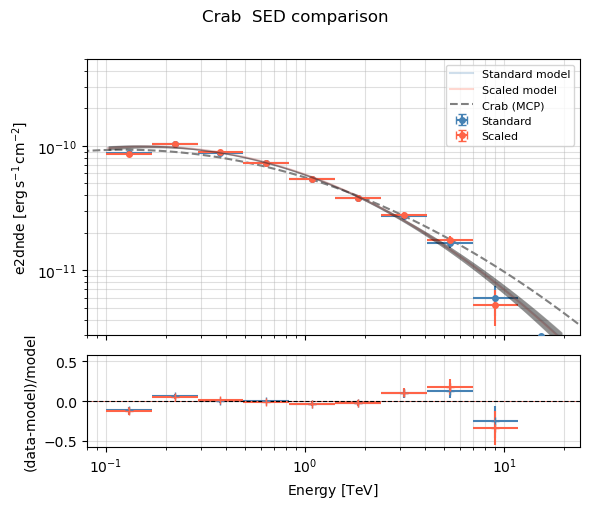

In [23]:
fig, (ax_sed, ax_res) = plt.subplots(
    2, 1, figsize=(6, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

fp_dataset_std.plot_spectrum(
    ax=ax_sed,
    kwargs_fp   ={"label": LABEL_STD,    "color": COLOR_STD,    "zorder": 3},
    kwargs_model={"color": COLOR_STD,    "alpha": 0.25, "label": f"{LABEL_STD} model"},
)
fp_dataset_scaled.plot_spectrum(
    ax=ax_sed,
    kwargs_fp   ={"label": LABEL_SCALED, "color": COLOR_SCALED, "zorder": 3},
    kwargs_model={"color": COLOR_SCALED, "alpha": 0.25, "label": f"{LABEL_SCALED} model"},
)
crab_model.plot(
    ax=ax_sed,
    sed_type     ="e2dnde",
    energy_bounds=[50 * u.GeV, 30 * u.TeV],
    label        ="Crab (MCP)",
    color        ="gray",
    ls           ="--",
)

ax_sed.set_ylim(3e-12, 5e-10)
ax_sed.set_xlabel(None)
ax_sed.legend(fontsize=8)
ax_sed.grid(which="both", alpha=0.4)

fp_dataset_std.plot_residuals(ax=ax_res, method="diff/model", color=COLOR_STD)
fp_dataset_scaled.plot_residuals(ax=ax_res, method="diff/model", color=COLOR_SCALED)
ax_res.axhline(0, color="k", ls="--", lw=0.8)
ax_res.set_xlim(E_RECO_MIN * 0.8, E_RECO_MAX * 1.2)
ax_res.set_ylabel("(data-model)/model")
ax_res.grid(which="both", alpha=0.4)

plt.suptitle(f"{SOURCE_NAME}  SED comparison", y=1.01)
plt.tight_layout()
plt.show()

In [24]:
# Side-by-side best-fit parameter comparison
print(f"{'Parameter':20s}  {LABEL_STD:>26s}  {LABEL_SCALED:>26s}")
print("-" * 78)
for p_s, p_c in zip(model_best_std.parameters, model_best_scaled.parameters):
    if p_s.frozen:
        continue
    print(
        f"{p_s.name:20s}  {p_s.value:>13.4e} +/- {p_s.error:>8.2e}"
        f"  {p_c.value:>13.4e} +/- {p_c.error:>8.2e}"
    )

Parameter                               Standard                      Scaled
------------------------------------------------------------------------------
amplitude                1.4109e-10 +/- 1.77e-12     1.4195e-10 +/- 1.77e-12
alpha                    2.4019e+00 +/- 1.33e-02     2.3992e+00 +/- 1.33e-02
beta                     1.5392e-01 +/- 1.19e-02     1.5607e-01 +/- 1.19e-02


---
## 10 · Light Curve — run-wise fit on both datasets

Conventional LC approach: **PowerLaw with frozen spectral index** (only amplitude free per run).

In [25]:
lc_spec = crab_model 
# lc_spec = PowerLawSpectralModel(
#     index = 2,
#     amplitude = 2e-11 * u.Unit("cm-2 s-1 TeV-1"),
#     reference=ref_energy,
# )
# lc_spec.index.frozen     = True
lc_spec.alpha.frozen = True
lc_spec.beta.frozen  = True
lc_spec.amplitude.min = 1e-26
lc_spec.amplitude.max = 1e-8

lc_estimator = LightCurveEstimator(
    energy_edges = [E_LC_MIN, E_LC_MAX] * u.TeV,
    reoptimize = False,
    selection_optional = "all",
)

print(f"LC energy  : [{E_LC_MIN}, {E_LC_MAX}] TeV")

LC energy  : [0.3, 20] TeV


In [26]:
%%time
print(f"Running LC estimator - {LABEL_STD} ...")
datasets_std.models = SkyModel(spectral_model=lc_spec.copy(), name=SOURCE_NAME)
lc_std = lc_estimator.run(datasets_std)
lc_table_std = lc_std.to_table(sed_type="flux", format="lightcurve")
print("Done.")
display(lc_table_std)

Running LC estimator - Standard ...
Done.


time_min,time_max,e_ref,e_min,e_max,flux,flux_err,flux_errp,flux_errn,flux_ul,flux_sensitivity,ts,sqrt_ts,npred,npred_excess,stat,stat_null,stat_scan,is_ul,counts,success,norm_scan
,,TeV,TeV,TeV,1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),,,,,,,,,,,
float64,float64,float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],"float64[1,56]","float64[1,56]",float64[1],float64[1],"float64[1,11]",bool[1],"float64[1,56]",bool[1],"float64[1,11]"
60934.17781908467,60934.18387221122,2.402248867962862,0.2885399811814427,19.999999999999996,1.0855876551209967e-10,1.3154516976320613e-11,1.3543923132999229e-11,1.2776474106457858e-11,1.363637042242935e-10,2.8165670614161703e-11,71.10418832794528,8.432329946577356,104.62919541035235 .. nan,88.2591781616211 .. nan,10.20079601175142,81.3049843396967,51.755826366688666 .. 585.5465818354807,False,103.0 .. nan,True,0.2 .. 4.999999999999999
60940.141835633214,60940.15577329839,2.402248867962862,0.2885399811814427,19.999999999999996,1.5044141512856917e-10,9.909199138154093e-12,1.0010390090682316e-11,9.812586127914987e-12,1.7069218330400566e-10,1.1458153114006653e-11,247.20937431782474,15.722893318910002,nan .. nan,nan .. nan,5.0320772068485535,252.2414515246733,176.03293307840528 .. 1333.076413835919,False,nan .. nan,True,0.2 .. 4.999999999999999
60940.155966527775,60940.16989962697,2.402248867962862,0.2885399811814427,19.999999999999996,1.392022722474193e-10,1.0357779194351374e-11,1.0474293957830784e-11,1.0246172561479188e-11,1.6041346577023928e-10,1.1951484568174722e-11,213.55543437283438,14.613535998273463,nan .. nan,nan .. nan,8.895630367299404,222.45106474013377,149.74119127272434 .. 1223.2164807830409,False,nan .. nan,True,0.2 .. 4.999999999999999
60940.170101546486,60940.18401938245,2.402248867962862,0.2885399811814427,19.999999999999996,1.7779486985191057e-10,1.1099935608316203e-11,1.1233538546136666e-11,1.0971129308303901e-11,2.0054184870649723e-10,1.0801619166905758e-11,293.5775439458684,17.134104702197558,nan .. nan,nan .. nan,5.828503836957936,299.40604778282636,223.44681983155513 .. 959.5572158628429,False,nan .. nan,True,0.2 .. 4.999999999999999
60940.184206858554,60940.19822143199,2.402248867962862,0.2885399811814427,19.999999999999996,1.4007875122929124e-10,1.0781733398977997e-11,1.0911302441992648e-11,1.0661690058089771e-11,1.6221273679921532e-10,1.374353346817571e-11,188.5017492993323,13.729593923322433,nan .. nan,nan .. nan,9.32712497884361,197.8288742781759,134.76299304694422 .. 1070.5341122582743,False,nan .. nan,True,0.2 .. 4.999999999999999
60940.19842453428,60940.212395810595,2.402248867962862,0.2885399811814427,19.999999999999996,1.6138613388079033e-10,1.1663943560545312e-11,1.1808806562667318e-11,1.1526144337214423e-11,1.8530881317607158e-10,1.4204282466120686e-11,209.59468222668045,14.477385199913707,nan .. nan,nan .. nan,6.098490652663674,215.69317287934413,155.05832386591558 .. 896.5005077216264,False,nan .. nan,True,0.2 .. 4.999999999999999
60941.14506832507,60941.15871902786,2.402248867962862,0.2885399811814427,19.999999999999996,1.3444847162616328e-10,9.85296519822215e-12,9.959540704874776e-12,9.749704287792206e-12,1.5459713594571417e-10,1.1593250869063398e-11,216.6923453288756,14.720473678821467,nan .. nan,nan .. nan,14.825199741120556,231.51754506999617,154.60617538981785 .. 1367.17612830054,False,nan .. nan,True,0.2 .. 4.999999999999999
60941.15891924244,60941.17288176361,2.402248867962862,0.2885399811814427,19.999999999999996,1.5528411229041582e-10,1.0699970139269593e-11,1.0822090780866664e-11,1.0582375871067215e-11,1.7718160879534845e-10,1.2255576137935633e-11,236.77833932533056,15.3876034302074,nan .. nan,nan .. nan,3.8370746006274734,240.61541392595802,169.0997887949911 .. 1098.1506071672375,False,nan .. nan,True,0.2 .. 4.999999999999999


CPU times: user 1min 35s, sys: 19.1 s, total: 1min 54s
Wall time: 1min 54s


In [27]:
%%time
print(f"Running LC estimator - {LABEL_SCALED} ...")
datasets_scaled.models = SkyModel(spectral_model=lc_spec.copy(), name=SOURCE_NAME)
lc_scaled = lc_estimator.run(datasets_scaled)
lc_table_scaled = lc_scaled.to_table(sed_type="flux", format="lightcurve")
print("Done.")
display(lc_table_scaled)

Running LC estimator - Scaled ...
Done.


time_min,time_max,e_ref,e_min,e_max,flux,flux_err,flux_errp,flux_errn,flux_ul,flux_sensitivity,ts,sqrt_ts,npred,npred_excess,stat,stat_null,stat_scan,is_ul,counts,success,norm_scan
,,TeV,TeV,TeV,1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),,,,,,,,,,,
float64,float64,float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],"float64[1,56]","float64[1,56]",float64[1],float64[1],"float64[1,11]",bool[1],"float64[1,56]",bool[1],"float64[1,11]"
60934.17781908467,60934.18387223582,2.402248867962862,0.2885399811814427,19.999999999999996,1.1272874905532708e-10,1.3585064792647238e-11,1.3979535955752859e-11,1.3198436059034918e-11,1.4149378123411838e-10,2.7314202278877733e-11,77.8591008794123,8.823780418812126,110.3251142678337 .. nan,91.65080261230469 .. nan,6.698070275079099,84.5571711544914,54.75374901420292 .. 562.2043061422388,False,110.0 .. nan,True,0.2 .. 4.999999999999999
60940.141835633214,60940.15577329839,2.402248867962862,0.2885399811814427,19.999999999999996,1.5747749446808731e-10,1.0090431577446553e-11,1.0195897224470702e-11,9.98750235698516e-12,1.780864809265616e-10,1.0982712797853887e-11,269.8187561518764,16.426160724645197,nan .. nan,nan .. nan,3.663182048676383,273.4819382005528,194.7226593490843 .. 1278.989869070168,False,nan .. nan,True,0.2 .. 4.999999999999999
60940.15596651317,60940.16989962697,2.402248867962862,0.2885399811814427,19.999999999999996,1.3743284344080882e-10,1.0407027786813038e-11,1.052450303455758e-11,1.0293072283775672e-11,1.5872609351645651e-10,1.2223598868496793e-11,205.92578903732297,14.350114600145986,nan .. nan,nan .. nan,8.573952618601622,214.4997416559246,143.30665262006522 .. 1221.0468698741106,False,nan .. nan,True,0.2 .. 4.999999999999999
60940.170101546486,60940.18401938245,2.402248867962862,0.2885399811814427,19.999999999999996,1.754278584326146e-10,1.1084772845946238e-11,1.121800850470766e-11,1.0956293816901521e-11,1.9814211759965474e-10,1.1076658878524836e-11,284.36922728398036,16.863250792299223,nan .. nan,nan .. nan,5.269211045049577,289.63843832902995,215.20085136882767 .. 967.2630790667865,False,nan .. nan,True,0.2 .. 4.999999999999999
60940.184206858554,60940.19822143199,2.402248867962862,0.2885399811814427,19.999999999999996,1.4371225320070735e-10,1.0826023315949562e-11,1.0958542449465967e-11,1.069960125185032e-11,1.6590886022199792e-10,1.3234048781246496e-11,198.55975622809427,14.091123313210138,nan .. nan,nan .. nan,8.86982967197322,207.42958590006748,142.91273456881686 .. 1053.257833936596,False,nan .. nan,True,0.2 .. 4.999999999999999
60940.19842453428,60940.212395810595,2.402248867962862,0.2885399811814427,19.999999999999996,1.648934976131249e-10,1.1778295401508253e-11,1.1922860447561376e-11,1.1641010706828747e-11,1.890453319110334e-10,1.4154572823592072e-11,214.5093635929727,14.646138180181584,nan .. nan,nan .. nan,6.316451325170797,220.8258149181435,160.02193231286157 .. 880.2533954092725,False,nan .. nan,True,0.2 .. 4.999999999999999
60941.14506834317,60941.1587190124,2.402248867962862,0.2885399811814427,19.999999999999996,1.3945304899565535e-10,9.97134669389624e-12,1.0082194332015164e-11,9.86520686214068e-12,1.5987273257587636e-10,1.1301497023964384e-11,228.8389627366363,15.1274241937164,nan .. nan,nan .. nan,11.713685059030489,240.5526477956668,162.36580134187727 .. 1323.7586620137208,False,nan .. nan,True,0.2 .. 4.999999999999999
60941.15891924244,60941.17288176361,2.402248867962862,0.2885399811814427,19.999999999999996,1.5684778802770047e-10,1.0819590653225047e-11,1.0944233861535033e-11,1.0699017371990315e-11,1.7899430309055932e-10,1.2343822118773382e-11,236.97977457671135,15.394147413114874,nan .. nan,nan .. nan,4.1269421334935945,241.10671671020495,170.22937276017285 .. 1080.8534429655022,False,nan .. nan,True,0.2 .. 4.999999999999999


CPU times: user 1min 34s, sys: 18.9 s, total: 1min 53s
Wall time: 1min 53s


---
## 11 · Light Curve comparison plots

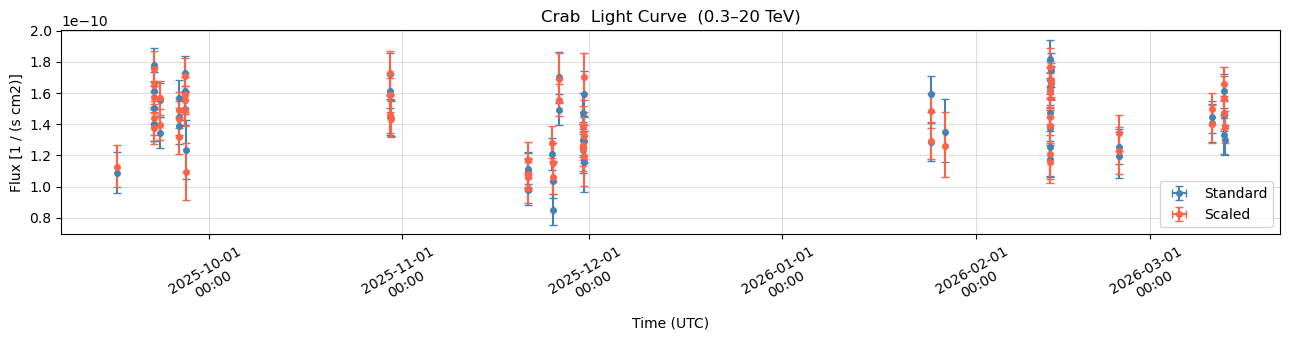

In [28]:
fig, ax = plt.subplots(figsize=(13, 3.5))

for lc_table, label, color, offset_s in [
    (lc_table_std,    LABEL_STD,    COLOR_STD,    -20),
    (lc_table_scaled, LABEL_SCALED, COLOR_SCALED, +20),
]:
    for i, row in enumerate(lc_table):
        t_min = Time(row["time_min"], format="mjd").datetime
        t_max = Time(row["time_max"], format="mjd").datetime
        t_c   = t_min + (t_max - t_min) / 2 + timedelta(seconds=offset_s)
        t_err = (t_max - t_min) / 2

        ax.errorbar(
            t_c, row["flux"],
            yerr=[row["flux_errn"], row["flux_errp"]], 
            xerr=t_err,
            fmt="o", color=color, capsize=3, ms=4,
            label=label if i == 0 else None,
        )

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax.set_ylabel(f"Flux [{lc_std.flux.unit}]")
ax.set_xlabel("Time (UTC)")
ax.set_title(f"{SOURCE_NAME}  Light Curve  ({E_LC_MIN}–{E_LC_MAX} TeV)")
ax.legend(); ax.grid(which="both", alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

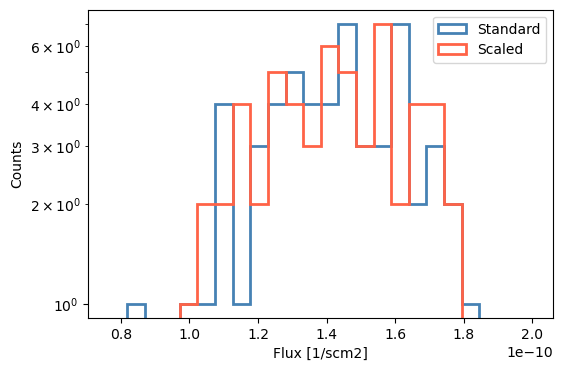

In [68]:
fbins = np.linspace(
    np.min([*lc_table_std["flux"], *lc_table_scaled["flux"]]) * 0.9,
    np.max([*lc_table_std["flux"], *lc_table_scaled["flux"]]) * 1.1, 25)

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(lc_table_std["flux"], fbins, color=COLOR_STD, histtype="step", lw=2, label="Standard")
ax.hist(lc_table_scaled["flux"], fbins, color=COLOR_SCALED, histtype="step", lw=2, label="Scaled")
ax.legend()
ax.set(xlabel="Flux [1/scm2]", ylabel="Counts", yscale="log", title="")
plt.show()

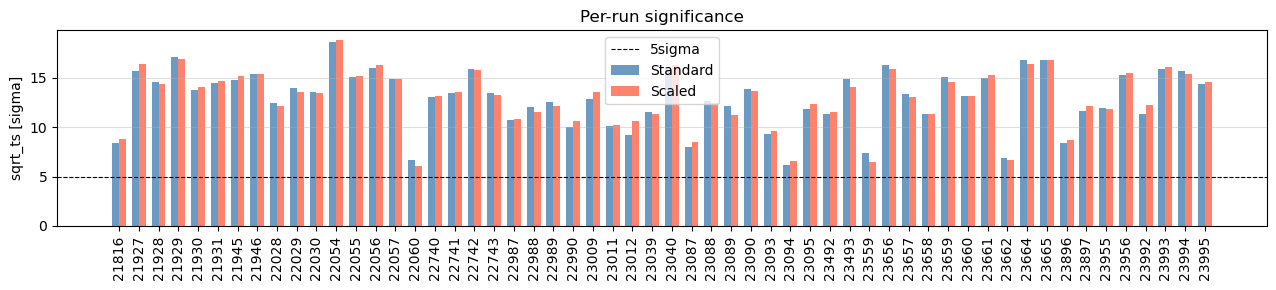

In [30]:
# Per-run significance comparison (bar chart)
n_rows   = min(len(lc_table_std), len(lc_table_scaled))
run_lbls = [str(oid) for oid in OBS_IDS[:n_rows]]
x        = np.arange(n_rows)
width    = 0.35

fig, ax = plt.subplots(figsize=(13, 3))

# FIX: Explicitly pass width, height, and color by keyword to prevent positional mixups.
# Also flat-extract the data using .flatten() just in case it's a 2D column matrix.
ax.bar(
    x=x - width/2, 
    height=np.array(lc_table_std["sqrt_ts"][:n_rows]).flatten(), 
    width=width, 
    color=COLOR_STD,    
    alpha=0.8, 
    label=LABEL_STD
)

ax.bar(
    x=x + width/2, 
    height=np.array(lc_table_scaled["sqrt_ts"][:n_rows]).flatten(), 
    width=width, 
    color=COLOR_SCALED, 
    alpha=0.8, 
    label=LABEL_SCALED
)

ax.axhline(5, color="k", ls="--", lw=0.8, label="5sigma")
ax.set_xticks(x)
ax.set_xticklabels(run_lbls, rotation=90)
ax.set_ylabel("sqrt_ts [sigma]")
ax.set_title("Per-run significance")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

---
## 12 · Crab-unit conversion & variability statistics

In [31]:
flux_crab_integral = crab_model.integral(E_LC_MIN * u.TeV, E_LC_MAX * u.TeV)
print(f"Crab integral flux [{E_LC_MIN}–{E_LC_MAX} TeV]: {flux_crab_integral:.4e}")

n_runs_std    = len(lc_table_std)
n_runs_scaled = len(lc_table_scaled)

flux_cu_std    = lc_std.flux.data.reshape(n_runs_std)       * lc_std.flux.unit    / flux_crab_integral
flux_cu_scaled = lc_scaled.flux.data.reshape(n_runs_scaled) * lc_scaled.flux.unit / flux_crab_integral
err_cu_std     = lc_std.flux_err.data.reshape(n_runs_std)       * lc_std.flux.unit    / flux_crab_integral
err_cu_scaled  = lc_scaled.flux_err.data.reshape(n_runs_scaled) * lc_scaled.flux.unit / flux_crab_integral

n_common = min(n_runs_std, n_runs_scaled)
print(f"\n{'Run':>12s}  {LABEL_STD+' [C.U.]':>20s}  {LABEL_SCALED+' [C.U.]':>20s}")
print("-" * 60)
for i, oid in enumerate(OBS_IDS[:n_common]):
    print(f"{str(oid):>12s}  {flux_cu_std[i].value:>9.4f} +/- {err_cu_std[i].value:>8.4f}"
          f"  {flux_cu_scaled[i].value:>9.4f} +/- {err_cu_scaled[i].value:>8.4f}")

Crab integral flux [0.3–20 TeV]: 1.2937e-10 1 / (s cm2)

         Run       Standard [C.U.]         Scaled [C.U.]
------------------------------------------------------------
       21816     0.8391 +/-   0.1017     0.8714 +/-   0.1050
       21927     1.1629 +/-   0.0766     1.2173 +/-   0.0780
       21928     1.0760 +/-   0.0801     1.0623 +/-   0.0804
       21929     1.3743 +/-   0.0858     1.3560 +/-   0.0857
       21930     1.0828 +/-   0.0833     1.1109 +/-   0.0837
       21931     1.2475 +/-   0.0902     1.2746 +/-   0.0910
       21945     1.0393 +/-   0.0762     1.0779 +/-   0.0771
       21946     1.2003 +/-   0.0827     1.2124 +/-   0.0836
       22028     1.0741 +/-   0.0892     1.0195 +/-   0.0867
       22029     1.2103 +/-   0.0918     1.1523 +/-   0.0901
       22030     1.1189 +/-   0.0897     1.1064 +/-   0.0895
       22054     1.2008 +/-   0.0680     1.2013 +/-   0.0675
       22055     1.1585 +/-   0.0811     1.1540 +/-   0.0805
       22056     1.3338 +/-   0.

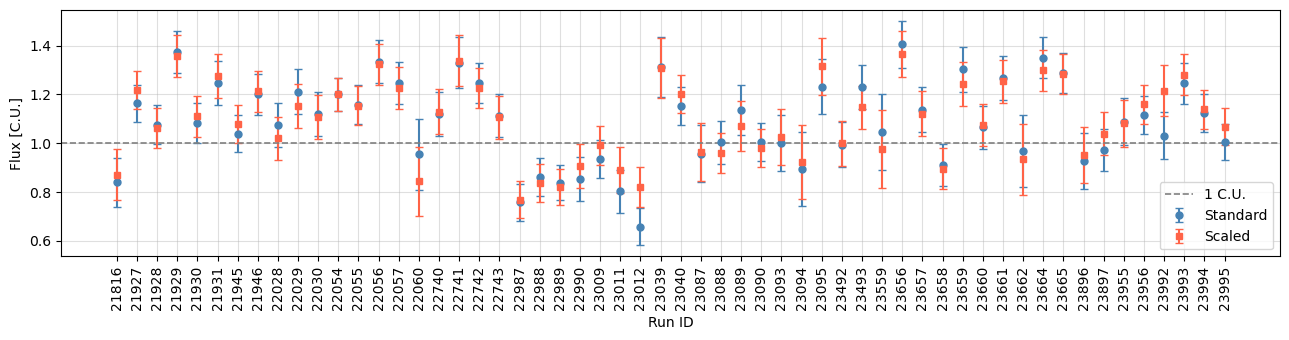

In [32]:
run_str = np.array(OBS_IDS, dtype=str)

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.errorbar(run_str, flux_cu_std.value,    yerr=err_cu_std.value,
            fmt="o", color=COLOR_STD,    capsize=3, ms=5, label=LABEL_STD)
ax.errorbar(run_str, flux_cu_scaled.value, yerr=err_cu_scaled.value,
            fmt="s", color=COLOR_SCALED, capsize=3, ms=5, label=LABEL_SCALED)
ax.axhline(1.0, color="gray", ls="--", lw=1.2, label="1 C.U.")
ax.set_ylabel("Flux [C.U.]"); ax.set_xlabel("Run ID")
ax.legend(); ax.grid(which="both", alpha=0.4)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('./plots/LC.png', bbox_inches='tight', dpi=200)
plt.show()

In [33]:
ROOT = Path(os.getcwd())
ROOT_DATA  = ROOT / "data"
DCHECK_DIR = ROOT_DATA / "datachecks"
FNAME_DCHECK_FLAT_SRUNWISE = DCHECK_DIR / "datachecks_flat.parquet"
FNAME_DCHECK_FLAT_RUNWISE = DCHECK_DIR / "datachecks_flat_runwise.parquet"

df_run = pd.read_parquet(FNAME_DCHECK_FLAT_RUNWISE)
df_srun = pd.read_parquet(FNAME_DCHECK_FLAT_SRUNWISE)

df_srun["time"] = pd.to_datetime(df_srun["time"])
df_run = df_run[df_run["obs_id"].isin(OBS_IDS)].reset_index(drop=True)
df_srun = df_srun[df_srun["obs_id"].isin(OBS_IDS)].reset_index(drop=True)

In [34]:
OBS_IDS

array([21816, 21927, 21928, 21929, 21930, 21931, 21945, 21946, 22028,
       22029, 22030, 22054, 22055, 22056, 22057, 22060, 22740, 22741,
       22742, 22743, 22987, 22988, 22989, 22990, 23009, 23011, 23012,
       23039, 23040, 23087, 23088, 23089, 23090, 23093, 23094, 23095,
       23492, 23493, 23559, 23656, 23657, 23658, 23659, 23660, 23661,
       23662, 23664, 23665, 23896, 23897, 23955, 23956, 23992, 23993,
       23994, 23995])

In [35]:
d = df_srun.query("obs_id == 23011")

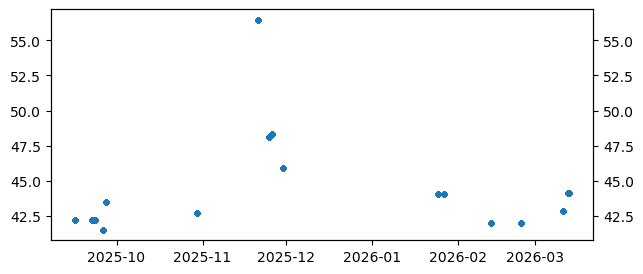

In [36]:
fig, ax = plt.subplots(figsize=(7, 3))
axt = ax.twinx()

ax.plot(df_srun["time"], df_srun["psf_spotsize"], ".")
axt.plot(df_srun["time"], df_srun["psf_spotsize"], ".")

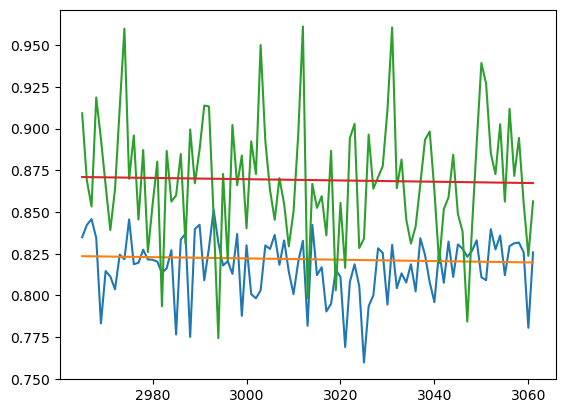

In [38]:
plt.plot(d["ly_i"])
plt.plot(1/d["ly_i_scaling"])
plt.plot(d["ly_b3"])
plt.plot(1/d["ly_b3_scaling"])

In [39]:
df_run

,obs_id,n_subruns,time,elapsed_time,corrected_elapsed_time,zd,min_zd,max_zd,az,ra,dec,events,ly_i,ly_i_err,ly_i_fit_p0,ly_i_fit_p1,ly_i_fit_u_p0,ly_i_fit_u_p1,ly_i_fit_chi2,ly_i_fit_pvalue,ly_i_fit_ndf,ly_i_fit_error_flag,ly_b3_fit_p0,ly_b3_fit_p1,ly_b3_fit_u_p0,ly_b3_fit_u_p1,ly_b3_fit_chi2,ly_b3_fit_pvalue,ly_b3_fit_ndf,ly_b3_fit_error_flag,ly_i_scaling,ly_i_scaling_err,ly_b3_scaling,ly_b3_scaling_err,ff_events,pedestal_events,num_contained_mu_rings,dcheck_fname,dl1_runwise_fname,dl2_fname,dl3_fname,intensity_cut,psf_spotsize,psf_time,alt,picture_thresh,boundary_thresh,diffuse_nsb_std,ff_charge_mean,ff_charge_stddev,ff_rel_time_mean,ff_rel_time_stddev,pedestal_charge_mean,pedestal_charge_stddev,pedestal_fraction_pulses_above10,pedestal_fraction_pulses_above30,cosmics_rate,cosmics_cleaned_rate,intensity_at_half_peak_rate,cosmics_peak_rate,cosmics_rate_at_422_pe,delta_cosmics_rate_at_422_pe,cosmics_spectral_index,delta_cosmics_spectral_index,ZD_corrected_intensity_at_half_peak_rate,ZD_corrected_cosmics_peak_rate,ZD_corrected_cosmics_rate_at_422_pe,ZD_corrected_delta_cosmics_rate_at_422_pe,ZD_corrected_cosmics_spectral_index,intensity_spectrum_fit_p_value,intensity_at_reference_rate,light_yield,mu_effi_mean,mu_effi_stddev,mu_width_mean,mu_width_stddev,mu_radius_mean,mu_radius_stddev,mu_intensity_mean,mu_hg_peak_sample,mu_hg_peak_sample_stddev,temperature,pressure,humidity,wind_speed,wind_gust,wind_speed_average,tng_dust,tng_seeing,rain,psf_time_since_h,ly_b3,ly_b3_p_value,ly_b3_err
0,21816,12,2025-09-16 04:15:16.152403,522.987406,522.987406,37.848328,36.958467,38.723701,90.903677,83.272078,21.788004,593504,0.872602,0.008155,0.855737,5.937170e-05,0.004523,0.000017,6.168941,6.283144e-01,8.0,False,0.906208,6.331626e-05,0.010883,0.000040,NaN,NaN,8.0,False,1.149617,0.003260,1.085467,NaN,51755.0,51792.0,2437,DL1_datacheck_20250915.h5,/fefs/onsite/data/lst-pipe/LSTN-01/DL1/2025091...,/fefs/onsite/data/lst-pipe/LSTN-01/DL2/2025091...,/fefs/onsite/data/lst-pipe/LSTN-01/DL3/2025091...,187.063120,42.200001,2025-09-24 19:40:06,52.151672,12.0,6.0,3.269210,72.575181,10.478261,0.001362,0.413681,4.080633,3.280855,0.048179,4.350663e-06,1134.834209,1130.734684,142.575101,4.591686,1.047280,0.010552,-2.324476,0.061119,136.628598,6.556437,1.468213,0.012096,-2.247305,0.392930,391.272597,0.872602,0.210956,0.023186,0.114088,0.026644,0.980173,0.100925,1595.498327,10.124550,1.153041,18.004173,791.956337,51.423592,10.385065,13.309130,10.394395,11.461985,1.467216,0.000000,-207.347367,0.917408,0.533722,NaN
1,21927,118,2025-09-22 03:23:09.688104,1204.207941,1204.207941,42.799462,40.597193,44.963271,88.231705,83.267773,21.788888,6636690,0.953955,0.013834,0.958901,-7.383365e-06,0.001809,0.000003,184.312543,3.378135e-05,114.0,False,0.983423,1.159155e-05,0.008100,0.000012,NaN,NaN,114.0,False,1.047690,0.001503,1.009759,NaN,115041.0,114913.0,3623,DL1_datacheck_20250921.h5,/fefs/onsite/data/lst-pipe/LSTN-01/DL1/2025092...,/fefs/onsite/data/lst-pipe/LSTN-01/DL2/2025092...,/fefs/onsite/data/lst-pipe/LSTN-01/DL3/2025092...,52.620194,42.200001,2025-09-24 19:40:06,47.200538,8.0,4.0,1.814479,71.518868,9.857438,0.001849,0.411995,2.310383,1.844797,0.002493,4.305610e-05,5511.249159,3943.072322,40.213059,31.733255,1.355281,0.023355,-2.356819,0.104783,37.637260,47.117867,1.640585,0.028263,-2.248885,0.440498,411.104604,0.953955,0.193714,0.015820,0.073847,0.019887,1.024596,0.095560,2021.119180,14.362446,1.296061,10.004820,788.777663,56.745723,1.661354,2.201908,1.680278,0.470000,0.710430,0.000000,-64.116275,0.990148,0.507441,NaN
2,21928,125,2025-09-22 03:43:29.324965,1203.807585,1203.807585,38.802611,36.607536,40.966735,89.602335,83.975596,22.246810,7070719,0.956292,0.013580,0.956525,2.945730e-06,0.001531,0.000002,261.816447,2.162936e-12,121.0,False,0.988994,-4.916853e-06,0.008178,0.000012,NaN,NaN,121.0,False,1.043528,0.001446,1.014151,NaN,114554.0,114710.0,3697,DL1_datacheck_20250921.h5,/fefs/onsite/data/lst-pipe/LSTN-01/DL1/2025092...,/fefs/onsite/data/lst-pipe/LSTN-01/DL2/20

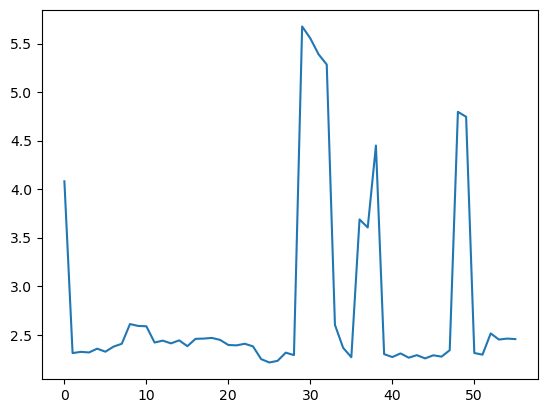

In [40]:
plt.plot(df_run["pedestal_charge_mean"])

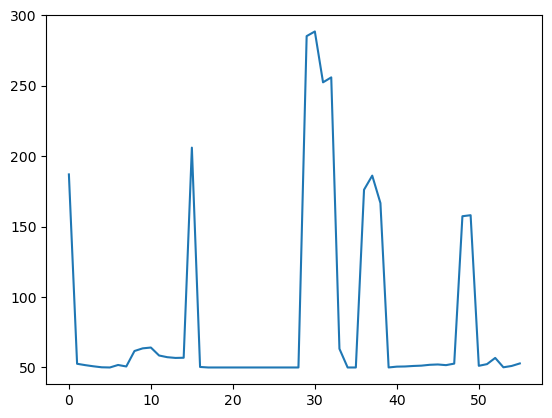

In [41]:
plt.plot(df_run["intensity_cut"])

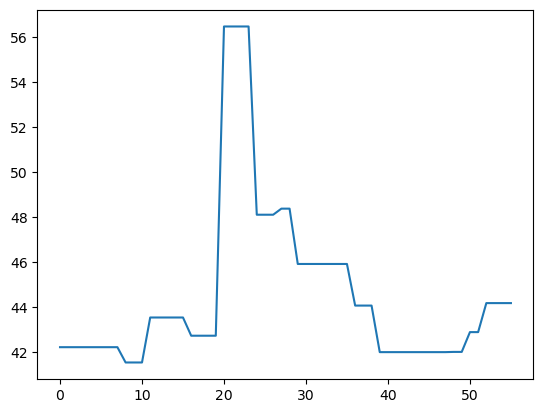

In [42]:
plt.plot(df_run["psf_spotsize"])

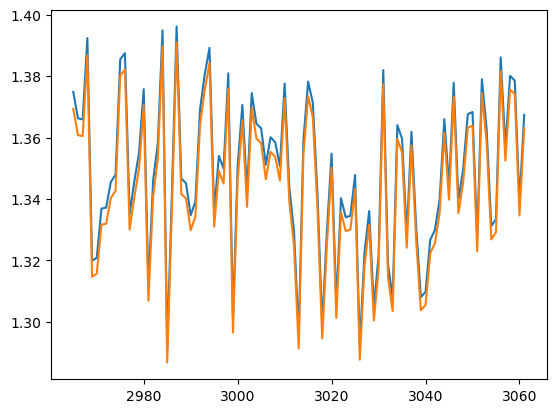

In [43]:
plt.plot(d["ZD_corrected_cosmics_rate_at_422_pe"])
plt.plot(d["cosmics_rate_at_422_pe"])

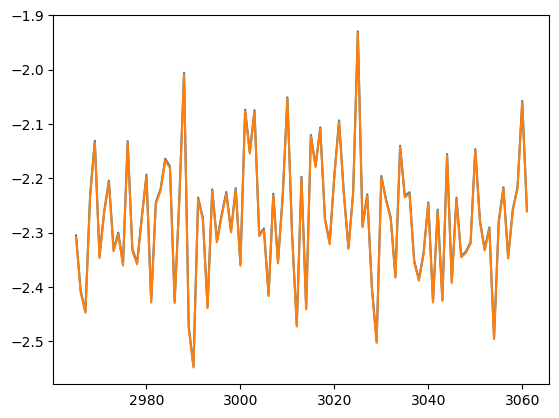

In [44]:
plt.plot(d["ZD_corrected_cosmics_spectral_index"])
plt.plot(d["cosmics_spectral_index"])

In [45]:

plt.hist(d["p_value"], 20)

KeyError: 'p_value'

In [46]:
# ROOT       = Path(os.getcwd())
# ROOT_DATA  = ROOT / "data"
# OUT_DIR    = ROOT_DATA / "selection"
# FNAME_RAW_LY3   = OUT_DIR / "raw_srw_ly3.ecsv"

# # raw_ly3 = pd.read_csv(FNAME_RAW_LY3, comment='#', sep="\s+")
# raw_ly3 = pd.read_csv(FNAME_RAW_LY3, comment='#', sep=",")
# raw_ly3 = raw_ly3.rename(columns={"subrun": "srun"})

# raw_ly3_runs = set(raw_ly3["runnumber"].astype(int))
# raw_ly3_lookup = {
#     (int(r), int(s)): float(ly)
#     for r, s, ly in zip(raw_ly3["runnumber"], raw_ly3["srun"], raw_ly3["light_yield"])
# }

# print(f"Loaded {len(raw_ly3):,} srun-wise LY rows from {len(raw_ly3_runs):,} runs -> {FNAME_RAW_LY3}")
# raw_ly3.head()

In [47]:
# ROOT       = Path(os.getcwd())
# ROOT_DATA  = ROOT / "data"
# DCHECK_DIR = ROOT_DATA / "datachecks"
# FNAME_TABLE_SRUN  = DCHECK_DIR / "table_datachecks_srunwise.csv"

# df_dust = pd.read_csv(FNAME_TABLE_SRUN)

# print(f"Loaded {len(df_dust):} runs from {FNAME_TABLE_SRUN.name}")
# df_dust.head(3)

In [48]:
df_run

,obs_id,n_subruns,time,elapsed_time,corrected_elapsed_time,zd,min_zd,max_zd,az,ra,dec,events,ly_i,ly_i_err,ly_i_fit_p0,ly_i_fit_p1,ly_i_fit_u_p0,ly_i_fit_u_p1,ly_i_fit_chi2,ly_i_fit_pvalue,ly_i_fit_ndf,ly_i_fit_error_flag,ly_b3_fit_p0,ly_b3_fit_p1,ly_b3_fit_u_p0,ly_b3_fit_u_p1,ly_b3_fit_chi2,ly_b3_fit_pvalue,ly_b3_fit_ndf,ly_b3_fit_error_flag,ly_i_scaling,ly_i_scaling_err,ly_b3_scaling,ly_b3_scaling_err,ff_events,pedestal_events,num_contained_mu_rings,dcheck_fname,dl1_runwise_fname,dl2_fname,dl3_fname,intensity_cut,psf_spotsize,psf_time,alt,picture_thresh,boundary_thresh,diffuse_nsb_std,ff_charge_mean,ff_charge_stddev,ff_rel_time_mean,ff_rel_time_stddev,pedestal_charge_mean,pedestal_charge_stddev,pedestal_fraction_pulses_above10,pedestal_fraction_pulses_above30,cosmics_rate,cosmics_cleaned_rate,intensity_at_half_peak_rate,cosmics_peak_rate,cosmics_rate_at_422_pe,delta_cosmics_rate_at_422_pe,cosmics_spectral_index,delta_cosmics_spectral_index,ZD_corrected_intensity_at_half_peak_rate,ZD_corrected_cosmics_peak_rate,ZD_corrected_cosmics_rate_at_422_pe,ZD_corrected_delta_cosmics_rate_at_422_pe,ZD_corrected_cosmics_spectral_index,intensity_spectrum_fit_p_value,intensity_at_reference_rate,light_yield,mu_effi_mean,mu_effi_stddev,mu_width_mean,mu_width_stddev,mu_radius_mean,mu_radius_stddev,mu_intensity_mean,mu_hg_peak_sample,mu_hg_peak_sample_stddev,temperature,pressure,humidity,wind_speed,wind_gust,wind_speed_average,tng_dust,tng_seeing,rain,psf_time_since_h,ly_b3,ly_b3_p_value,ly_b3_err
0,21816,12,2025-09-16 04:15:16.152403,522.987406,522.987406,37.848328,36.958467,38.723701,90.903677,83.272078,21.788004,593504,0.872602,0.008155,0.855737,5.937170e-05,0.004523,0.000017,6.168941,6.283144e-01,8.0,False,0.906208,6.331626e-05,0.010883,0.000040,NaN,NaN,8.0,False,1.149617,0.003260,1.085467,NaN,51755.0,51792.0,2437,DL1_datacheck_20250915.h5,/fefs/onsite/data/lst-pipe/LSTN-01/DL1/2025091...,/fefs/onsite/data/lst-pipe/LSTN-01/DL2/2025091...,/fefs/onsite/data/lst-pipe/LSTN-01/DL3/2025091...,187.063120,42.200001,2025-09-24 19:40:06,52.151672,12.0,6.0,3.269210,72.575181,10.478261,0.001362,0.413681,4.080633,3.280855,0.048179,4.350663e-06,1134.834209,1130.734684,142.575101,4.591686,1.047280,0.010552,-2.324476,0.061119,136.628598,6.556437,1.468213,0.012096,-2.247305,0.392930,391.272597,0.872602,0.210956,0.023186,0.114088,0.026644,0.980173,0.100925,1595.498327,10.124550,1.153041,18.004173,791.956337,51.423592,10.385065,13.309130,10.394395,11.461985,1.467216,0.000000,-207.347367,0.917408,0.533722,NaN
1,21927,118,2025-09-22 03:23:09.688104,1204.207941,1204.207941,42.799462,40.597193,44.963271,88.231705,83.267773,21.788888,6636690,0.953955,0.013834,0.958901,-7.383365e-06,0.001809,0.000003,184.312543,3.378135e-05,114.0,False,0.983423,1.159155e-05,0.008100,0.000012,NaN,NaN,114.0,False,1.047690,0.001503,1.009759,NaN,115041.0,114913.0,3623,DL1_datacheck_20250921.h5,/fefs/onsite/data/lst-pipe/LSTN-01/DL1/2025092...,/fefs/onsite/data/lst-pipe/LSTN-01/DL2/2025092...,/fefs/onsite/data/lst-pipe/LSTN-01/DL3/2025092...,52.620194,42.200001,2025-09-24 19:40:06,47.200538,8.0,4.0,1.814479,71.518868,9.857438,0.001849,0.411995,2.310383,1.844797,0.002493,4.305610e-05,5511.249159,3943.072322,40.213059,31.733255,1.355281,0.023355,-2.356819,0.104783,37.637260,47.117867,1.640585,0.028263,-2.248885,0.440498,411.104604,0.953955,0.193714,0.015820,0.073847,0.019887,1.024596,0.095560,2021.119180,14.362446,1.296061,10.004820,788.777663,56.745723,1.661354,2.201908,1.680278,0.470000,0.710430,0.000000,-64.116275,0.990148,0.507441,NaN
2,21928,125,2025-09-22 03:43:29.324965,1203.807585,1203.807585,38.802611,36.607536,40.966735,89.602335,83.975596,22.246810,7070719,0.956292,0.013580,0.956525,2.945730e-06,0.001531,0.000002,261.816447,2.162936e-12,121.0,False,0.988994,-4.916853e-06,0.008178,0.000012,NaN,NaN,121.0,False,1.043528,0.001446,1.014151,NaN,114554.0,114710.0,3697,DL1_datacheck_20250921.h5,/fefs/onsite/data/lst-pipe/LSTN-01/DL1/2025092...,/fefs/onsite/data/lst-pipe/LSTN-01/DL2/20

In [49]:
scale = np.array(df_run["scaling_factor_b3"])
tng = np.array(df_run["tng_dust"])
ff = np.array(df_run["ff_charge_mean"])
zd = np.array(df_run["zd"])

KeyError: 'scaling_factor_b3'

In [50]:
# scale, tng, ff, zd, zd_diff =  [], [], [], [], []
# for run in OBS_IDS:
#     _dfs = raw_ly3[raw_ly3["runnumber"] == run]
#     _dft = df_dust[df_dust["obs_id"] == run]

#     scale.append(1/_dfs["light_yield"].mean())
#     # ff.append(_dfs["ff_charge_mean"].mean())
#     tng.append(_dft["tng_dust"])
#     # zd.append(_dft["zd"])
#     # dif = _dfs["zd"].max() - _dfs["zd"].min()
#     # dif = np.cos(_dfs["zd"].max()) - np.cos(_dfs["zd"].min())
#     # zd_diff.append(dif)
# scale = np.array(scale)
# tng = np.array(tng)
# ff = np.array(ff)
# zd = np.array(zd)
# zd_diff = np.array(zd_diff)
flux_c = flux_cu_scaled.value
flux_s = flux_cu_std.value
mflux_c, mflux_s = flux_c.mean(), flux_s.mean()
sflux_c, sflux_s = flux_c - mflux_c, flux_s - mflux_s

In [51]:
# run_str = np.array(OBS_IDS, dtype=str)

# fig, ax = plt.subplots(figsize=(13, 3.5))
# plt.xticks(rotation=90)
# axt = ax.twinx()
# ax.errorbar(run_str, flux_cu_std.value, fmt="", alpha=0, ms=5)
# for i in range(len(run_str)):
#     c = "b" if scale[i] < 1 else "r"
#     ax.arrow(i, flux_cu_std.value[i], 0, flux_cu_scaled.value[i]-flux_cu_std.value[i], lw=2, head_length=0.05, head_width=0.3, color=c)


# axt.plot(run_str, tng, "-", color="k")
# axt.set_yscale("log")
# axt.set_ylabel("TNG dust [$\\mu g /m^3$]")

# ax.plot([], [], "-b", label="Upscaled")
# ax.plot([], [], "-r", label="Downscaled")
# ax.axhline(1.0, color="gray", ls="--", lw=1.2)
# ax.set_ylabel("Flux [C.U.]"); ax.set_xlabel("Run ID")
# ax.grid(which="both", alpha=0.4); ax.legend()

# plt.tight_layout()
# plt.savefig('./plots/LC.png', bbox_inches='tight', dpi=200)
# plt.show()

In [52]:
# run_str = np.array(OBS_IDS, dtype=str)

# fig, ax = plt.subplots(figsize=(13, 3.5))
# plt.xticks(rotation=90)
# axt = ax.twinx()
# ax.errorbar(run_str, flux_cu_std.value, fmt="", alpha=0, ms=5)
# for i in range(len(run_str)):
#     c = "b" if scale[i] < 1 else "r"
#     ax.arrow(i, flux_cu_std.value[i], 0, flux_cu_scaled.value[i]-flux_cu_std.value[i], lw=2, head_length=0.05, head_width=0.3, color=c)


# axt.plot(run_str, 1/np.array(scale), "-", color="k")
# axt.set_ylabel("Scaling factor")

# ax.plot([], [], "-b", label="Upscaled")
# ax.plot([], [], "-r", label="Downscaled")
# axt.axhline(1.0, color="gray", ls="--", lw=1.2)
# ax.set_ylabel("Flux [C.U.]"); ax.set_xlabel("Run ID")
# ax.grid(which="both", alpha=0.4); ax.legend()

# plt.tight_layout()
# plt.savefig('./plots/LC.png', bbox_inches='tight', dpi=200)
# plt.show()

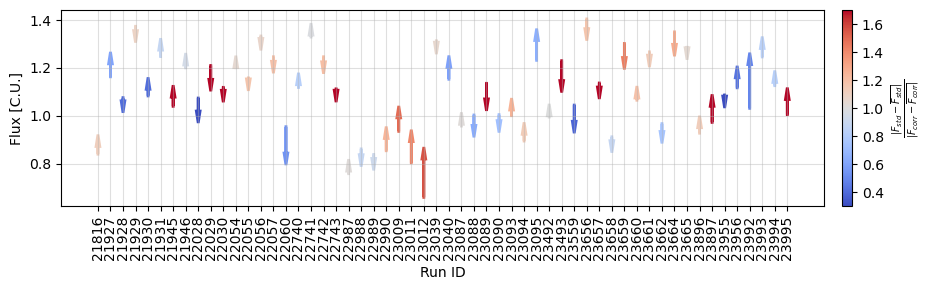

In [53]:
run_str = np.array(OBS_IDS, dtype=str)

fig, (ax) = plt.subplots(1, 1, figsize=(10, 3), sharex=True,)# gridspec_kw={'height_ratios': [1, 1.5]})
plt.xticks(rotation=90)

cmap = plt.colormaps["coolwarm"]
# norm = colors.LogNorm(vmin=0.4, vmax=2)
norm = colors.Normalize(vmin=0.3, vmax=1.7)

ax.errorbar(run_str, flux_cu_std.value, fmt="", alpha=0, ms=5)
for i in range(len(run_str)):
    # c = "b" if flux_cu_scaled.value[i]-flux_cu_std.value[i] <= 0 else "r"
    ref_std, ref_scaled = 1, 1
    ref_std, ref_scaled = flux_cu_std.value.mean(), flux_cu_scaled.value.mean()
    val = np.abs(flux_cu_std.value[i]-ref_std) / np.abs(flux_cu_scaled.value[i]-ref_scaled)
    c = cmap(norm(val))
    ax.arrow(i, flux_cu_std.value[i], 0, flux_cu_scaled.value[i]-flux_cu_std.value[i], lw=2, head_length=0.05, head_width=0.3, color=c)

# ax.axhline(1.0, color="gray", ls="--", lw=1.2)
ax.set_ylabel("Flux [C.U.]"); ax.set_xlabel("Run ID")
ax.grid(which="both", alpha=0.4)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, label="$\\frac{|F_{std}-\\overline{F_{std}}|}{|F_{corr}-\\overline{F_{corr}}|}$")

plt.tight_layout(); plt.subplots_adjust(wspace=0, hspace=0)
plt.savefig('./plots/LC.png', bbox_inches='tight', dpi=200)
plt.show()

In [54]:
x = np.linspace(-100, 100, 100)

outliers_mask = ((flux_s > flux_c) & (scale > 1)) | ((flux_s < flux_c) & (scale < 1))
num_outliers = np.sum(outliers_mask)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3), sharey=True, gridspec_kw={'width_ratios': [1, 3]})

mup = scale < 1
ax1.scatter(flux_s[mup], flux_c[mup], color=COLOR_STD, label="Scaling < 1")
ax1.scatter(flux_s[~mup], flux_c[~mup], color=COLOR_SCALED, label="Scaling > 1")
ax1.scatter(flux_s[outliers_mask], flux_c[outliers_mask], color="k", marker="x", s=8)

ax2.errorbar(run_str, flux_cu_std.value, fmt="", alpha=0, ms=5)
for i in range(len(run_str)):
    c = COLOR_STD if scale[i] < 1 else COLOR_SCALED
    ax2.arrow(i, flux_cu_std.value[i], 0, flux_cu_scaled.value[i]-flux_cu_std.value[i], lw=2, head_length=0.02, head_width=0.4, color=c)
ax2.errorbar(run_str, flux_cu_std.value, fmt="", alpha=0, ms=5)
for i in range(len(run_str)):
    if outliers_mask[i]:
        ax2.arrow(i, flux_cu_std.value[i], 0, flux_cu_scaled.value[i]-flux_cu_std.value[i], 
                  lw=4, head_length=0.02, head_width=0.4, color="k", zorder=-1000,)


ax1.set(xlim=(0.7, 1.4), ylim=(0.7, 1.4), xlabel="Standard flux [C.U.]", ylabel="Corrected flux [C.U.]")
ax1.plot(x, x, ls="--", color="k")
ax2.plot([], [], "^", c="k", label=f"Wrong: {num_outliers}/{len(outliers_mask)}")

xlen = np.arange(len(flux_s))
step = max(1, len(flux_s) // 20)
ax2.set(xticks=xlen[::step],)
ax2.set_xticklabels(run_str[::step], rotation=90, ha="center")

ax1.legend(frameon=False); ax2.legend(frameon=False)
plt.tight_layout()
plt.show()

NameError: name 'scale' is not defined

NameError: name 'scale' is not defined

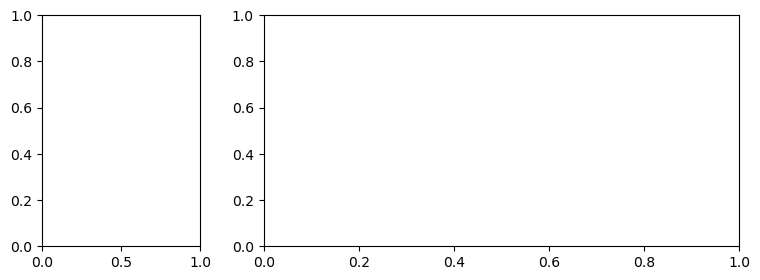

In [55]:
x = np.linspace(-100, 100, 100)

outliers_mask = ((np.abs(sflux_s) / np.abs(sflux_c) <= 1))
num_outliers = np.sum(outliers_mask)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3), gridspec_kw={'width_ratios': [1, 3]})

mup = scale <= 1
ax1.scatter(np.abs(sflux_s)[mup], np.abs(sflux_c)[mup], color=COLOR_STD, label="Scaling < 1")
ax1.scatter(np.abs(sflux_s)[~mup], np.abs(sflux_c)[~mup], color=COLOR_SCALED, label="Scaling > 1")
ax1.scatter(np.abs(sflux_s)[outliers_mask], np.abs(sflux_c)[outliers_mask], color="k", marker="x", s=8)

ax2.errorbar(run_str, flux_cu_std.value, fmt="", alpha=0, ms=5)
for i in range(len(run_str)):
    c = COLOR_STD if scale[i] < 1 else COLOR_SCALED
    ax2.arrow(i, flux_cu_std.value[i], 0, flux_cu_scaled.value[i]-flux_cu_std.value[i], lw=2, head_length=0.02, head_width=0.4, color=c)
ax2.errorbar(run_str, flux_cu_std.value, fmt="", alpha=0, ms=5)
for i in range(len(run_str)):
    if outliers_mask[i]:
        ax2.arrow(i, flux_cu_std.value[i], 0, flux_cu_scaled.value[i]-flux_cu_std.value[i], 
                  lw=4, head_length=0.02, head_width=0.4, color="k", zorder=-1000,)

ax2.axhline(mflux_s, ls=":", label="Standard mean", color="k")
ax2.axhline(mflux_c, ls="--", label="Corrected mean", color="k")
ax1.set(xlim=(-0.05,0.5), ylim=(-0.05, 0.5), xlabel="|$\\Delta F (std)$| [C.U.]", ylabel="|$\\Delta F (corr)$| [C.U.]")
ax1.set_title("$\\Delta F  = F - \\overline{F}$")
ax1.plot(x, x, ls="--", color="k")
ax2.plot([], [], "^", c="k", label=f"Wrong: {num_outliers}/{len(outliers_mask)}")
ax1.fill_between(x, 1, x, color="r", alpha=0.3, zorder=-10000)

xlen = np.arange(len(flux_s))
step = max(1, len(flux_s) // 20)
ax2.set(xticks=xlen[::step], ylabel="Flux [C.U.]")
ax2.set_xticklabels(run_str[::step], rotation=90, ha="center")

ax1.legend(frameon=True, loc=2); ax2.legend(frameon=False, ncols=3, loc=(0.0, 1.02))
plt.tight_layout()
plt.show()

In [ ]:
x = np.linspace(-100, 100, 100)

outliers_mask = ((scale > 1) & (sflux_s <0)) | ((scale < 1) & (sflux_s > 0))
num_outliers = np.sum(outliers_mask)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3), gridspec_kw={'width_ratios': [1, 3]})

mup = scale < 1
ax1.scatter(scale[mup], sflux_s[mup], color=COLOR_STD, label="S<1")
ax1.scatter(scale[~mup], sflux_s[~mup], color=COLOR_SCALED, label="S>1")
ax1.scatter(scale[outliers_mask], sflux_s[outliers_mask], color="k", marker="x", s=8)

ax2.errorbar(run_str, flux_cu_std.value, fmt="", alpha=0, ms=5)
for i in range(len(run_str)):
    c = COLOR_STD if scale[i] < 1 else COLOR_SCALED
    ax2.arrow(i, flux_cu_std.value[i], 0, flux_cu_scaled.value[i]-flux_cu_std.value[i], lw=2, head_length=0.02, head_width=0.4, color=c)
ax2.errorbar(run_str, flux_cu_std.value, fmt="", alpha=0, ms=5)
for i in range(len(run_str)):
    if outliers_mask[i]:
        ax2.arrow(i, flux_cu_std.value[i], 0, flux_cu_scaled.value[i]-flux_cu_std.value[i], 
                  lw=4, head_length=0.02, head_width=0.4, color="k", zorder=-1000,)

ax1.axhline(0, ls="--", color="k")
ax1.axvline(1, ls="--", color="k")
# ax1.plot(x, x, ls="--", color="k")
ax2.plot([], [], "^", c="k", label=f"Wrong: {num_outliers}/{len(outliers_mask)}")
ax1.fill_between([0, 1], [1, 1], 0, color="r", alpha=0.3, zorder=-10000)
ax1.fill_between([1, 2], [-1, -1], 0, color="r", alpha=0.3, zorder=-10000)
ax1.set(ylim=(-0.45, 0.35), xlim=(0.9, 1.2), xlabel="Scaling factor", ylabel="|$\\Delta F (std)$| [C.U.]")

xlen = np.arange(len(flux_s))
step = max(1, len(flux_s) // 20)
ax2.set(xticks=xlen[::step],)
ax2.set_xticklabels(run_str[::step], rotation=90, ha="center")

ax1.legend(frameon=False, loc=(0, 1.01), ncols=2); ax2.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10, 3), sharey=True)

mup = scale < 1
ax1.plot(tng[mup], (np.abs(sflux_c)/np.abs(sflux_s))[mup], "o", color=COLOR_STD, label="Scaling < 1")
ax1.plot(tng[~mup], (np.abs(sflux_c)/np.abs(sflux_s))[~mup], "o", color=COLOR_SCALED, label="Scaling > 1")
ax2.plot(ff[mup]*1e-5, (np.abs(sflux_c)/np.abs(sflux_s))[mup], "o", color=COLOR_STD, label="Scaling < 1")
ax2.plot(ff[~mup]*1e-5, (np.abs(sflux_c)/np.abs(sflux_s))[~mup], "o", color=COLOR_SCALED, label="Scaling > 1")
ax3.plot(zd[mup], (np.abs(sflux_c)/np.abs(sflux_s))[mup], "o", color=COLOR_STD, label="Scaling < 1")
ax3.plot(zd[~mup], (np.abs(sflux_c)/np.abs(sflux_s))[~mup], "o", color=COLOR_SCALED, label="Scaling > 1")
ax4.plot(np.abs(zd_diff)[mup], (np.abs(sflux_c)/np.abs(sflux_s))[mup], "o", color=COLOR_STD, label="Scaling < 1")
ax4.plot(np.abs(zd_diff)[~mup], (np.abs(sflux_c)/np.abs(sflux_s))[~mup], "o", color=COLOR_SCALED, label="Scaling > 1")

for ax in [ax1, ax2, ax3, ax4]:
    ax.fill_between([-10, 1000], [1, 1], 100, color="r", alpha=0.3, zorder=-10000)

ax1.set(xscale="log", ylim=(-0.3, 6.5), xlim=(1e-2, 6e1))
ax1.set(ylim=(-0.3, 6.5), xlim=(1e-2, 6e1), xlabel="TNG dust [$\\mu$g/m${}^3$]", ylabel="|$\\Delta F$(corr)|/|$\\Delta F$(std)|")
ax2.set(xlim=(1.28, 1.4), xlabel="FF charge [p.e.]")
ax3.set(xlim=(3, 50), xlabel="Zenith [deg]")
ax4.set(xlim=(0, 2), xlabel="$\\Delta$cos(ZD)")
ax1.legend()

plt.tight_layout()
plt.show()

In [56]:
plt.hist(zd_diff, 20);

NameError: name 'zd_diff' is not defined

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8.5, 3), sharey=True)

mup = scale < 1
ax1.plot(tng[mup], (np.abs(sflux_c)/np.abs(sflux_s))[mup], "o", color=COLOR_STD, label="Scaling < 1")
ax1.plot(tng[~mup], (np.abs(sflux_c)/np.abs(sflux_s))[~mup], "o", color=COLOR_SCALED, label="Scaling > 1")
ax2.plot(ff[mup]*1e-5, (np.abs(sflux_c)/np.abs(sflux_s))[mup], "o", color=COLOR_STD, label="Scaling < 1")
ax2.plot(ff[~mup]*1e-5, (np.abs(sflux_c)/np.abs(sflux_s))[~mup], "o", color=COLOR_SCALED, label="Scaling > 1")
ax3.plot(zd[mup], (np.abs(sflux_c)/np.abs(sflux_s))[mup], "o", color=COLOR_STD, label="Scaling < 1")
ax3.plot(zd[~mup], (np.abs(sflux_c)/np.abs(sflux_s))[~mup], "o", color=COLOR_SCALED, label="Scaling > 1")

for ax in [ax1, ax2, ax3]:
    ax.fill_between([0, 1000], [1, 1], 100, color="r", alpha=0.3, zorder=-10000)

ax1.set(xscale="log", ylim=(-0.3, 6.5), xlim=(1e-2, 6e1))
ax1.set(ylim=(-0.3, 6.5), xlim=(1e-2, 6e1), xlabel="TNG dust [$\\mu$g/m${}^3$]", ylabel="|$\\Delta F$(corr)|/|$\\Delta F$(std)|")
ax2.set(xlim=(1.28, 1.4), xlabel="FF charge [p.e.]")
ax3.set(xlim=(3, 50), xlabel="Zenith [deg]")
ax1.legend()

plt.tight_layout()
plt.show()

In [57]:
for label, lc_table in [(LABEL_STD, lc_table_std), (LABEL_SCALED, lc_table_scaled)]:

    mask  = ~(np.isnan(lc_table["flux"]) | np.isnan(lc_table["flux_err"]))
    flux  = lc_table["flux"][mask]
    ferr  = lc_table["flux_err"][mask]

    w         = 1.0 / ferr**2
    mean_flux = (flux * w).sum() / w.sum()
    mean_err  = np.sqrt(1.0 / w.sum())

    chi2_val  = np.sum((flux - mean_flux)**2 / ferr**2)
    ndf       = len(flux) - 1
    p_val     = chi2.sf(chi2_val, ndf)

    flux_cu_mean = mean_flux / flux_crab_integral.value
    flux_cu_err  = mean_err  / flux_crab_integral.value

    print("="*55)
    print(f"  {label}")
    print("="*55)
    print(f"  Weighted mean flux : {mean_flux:.4e} +/- {mean_err:.2e} {lc_std.flux.unit}")
    print(f"  Mean flux [C.U.]   : {flux_cu_mean:.4f} +/- {flux_cu_err:.4f}")
    print(f"  Chi2 / ndf         : {chi2_val:.2f} / {ndf}")
    print(f"  P-value            : {p_val:.4e}")
    print()

  Standard
  Weighted mean flux : 1.4064e-10 +/- 1.53e-12 1 / (s cm2)
  Mean flux [C.U.]   : 1.0871 +/- 0.0118
  Chi2 / ndf         : 209.22 / 55
  P-value            : 7.8015e-20

  Scaled
  Weighted mean flux : 1.4207e-10 +/- 1.54e-12 1 / (s cm2)
  Mean flux [C.U.]   : 1.0982 +/- 0.0119
  Chi2 / ndf         : 173.10 / 55
  P-value            : 3.8490e-14



In [58]:
# Standard deviation of run-wise CU fluxes
print(f"Run-wise flux standard deviation [C.U.]:")
print(f"  {LABEL_STD:12s}: {np.nanstd(flux_cu_std.value):.4f}")
print(f"  {LABEL_SCALED:12s}: {np.nanstd(flux_cu_scaled.value):.4f}")

# Per-run ratio Scaled / Standard
ratio = flux_cu_scaled[:n_common].value / flux_cu_std[:n_common].value
print(f"\nPer-run flux ratio Scaled/Standard:")
for oid, r in zip(OBS_IDS[:n_common], ratio):
    arrow = "UP" if r > 1.05 else ("DOWN" if r < 0.95 else "==")
    print(f"  Run {oid}  ratio = {r:.4f}  {arrow}")

Run-wise flux standard deviation [C.U.]:
  Standard    : 0.1679
  Scaled      : 0.1573

Per-run flux ratio Scaled/Standard:
  Run 21816  ratio = 1.0384  ==
  Run 21927  ratio = 1.0468  ==
  Run 21928  ratio = 0.9873  ==
  Run 21929  ratio = 0.9867  ==
  Run 21930  ratio = 1.0259  ==
  Run 21931  ratio = 1.0217  ==
  Run 21945  ratio = 1.0372  ==
  Run 21946  ratio = 1.0101  ==
  Run 22028  ratio = 0.9491  DOWN
  Run 22029  ratio = 0.9521  ==
  Run 22030  ratio = 0.9888  ==
  Run 22054  ratio = 1.0004  ==
  Run 22055  ratio = 0.9962  ==
  Run 22056  ratio = 0.9922  ==
  Run 22057  ratio = 0.9847  ==
  Run 22060  ratio = 0.8841  DOWN
  Run 22740  ratio = 1.0106  ==
  Run 22741  ratio = 1.0064  ==
  Run 22742  ratio = 0.9829  ==
  Run 22743  ratio = 0.9947  ==
  Run 22987  ratio = 1.0143  ==
  Run 22988  ratio = 0.9717  ==
  Run 22989  ratio = 0.9800  ==
  Run 22990  ratio = 1.0603  UP
  Run 23009  ratio = 1.0608  UP
  Run 23011  ratio = 1.1106  UP
  Run 23012  ratio = 1.2445  UP
  Run 23

---
## 13 · Summary table

In [59]:
n_rows = min(n_runs_std, n_runs_scaled)

t = atbl.Table()
t["run_id"]         = list(OBS_IDS[:n_rows])
t["flux_std"]       = lc_std.flux.data.reshape(n_runs_std)[:n_rows]
t["flux_std_err"]   = lc_std.flux_err.data.reshape(n_runs_std)[:n_rows]
t["flux_sca"]       = lc_scaled.flux.data.reshape(n_runs_scaled)[:n_rows]
t["flux_sca_err"]   = lc_scaled.flux_err.data.reshape(n_runs_scaled)[:n_rows]
t["flux_std_cu"]    = flux_cu_std[:n_rows].value
t["err_std_cu"]     = err_cu_std[:n_rows].value
t["flux_sca_cu"]    = flux_cu_scaled[:n_rows].value
t["err_sca_cu"]     = err_cu_scaled[:n_rows].value
t["ratio_sca_std"]  = ratio[:n_rows]
t["sqrt_ts_std"]    = list(lc_table_std["sqrt_ts"][:n_rows])
t["sqrt_ts_sca"]    = list(lc_table_scaled["sqrt_ts"][:n_rows])

# Format floats
for col in t.colnames:
    if t[col].dtype.kind == "f":
        t[col].format = ".4f"

display(t)

# outfile = "summary_lc_comparison.ecsv"
# t.write(outfile, format="ascii.ecsv", overwrite=True)
# print(f"Saved to {outfile}")

run_id,flux_std,flux_std_err,flux_sca,flux_sca_err,flux_std_cu,err_std_cu,flux_sca_cu,err_sca_cu,ratio_sca_std,sqrt_ts_std,sqrt_ts_sca
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[1],float64[1]
21816,0.0000,0.0000,0.0000,0.0000,0.8391,0.1017,0.8714,0.1050,1.0384,8.4323,8.8238
21927,0.0000,0.0000,0.0000,0.0000,1.1629,0.0766,1.2173,0.0780,1.0468,15.7229,16.4262
21928,0.0000,0.0000,0.0000,0.0000,1.0760,0.0801,1.0623,0.0804,0.9873,14.6135,14.3501
21929,0.0000,0.0000,0.0000,0.0000,1.3743,0.0858,1.3560,0.0857,0.9867,17.1341,16.8633
21930,0.0000,0.0000,0.0000,0.0000,1.0828,0.0833,1.1109,0.0837,1.0259,13.7296,14.0911
21931,0.0000,0.0000,0.0000,0.0000,1.2475,0.0902,1.2746,0.0910,1.0217,14.4774,14.6461
21945,0.0000,0.0000,0.0000,0.0000,1.0393,0.0762,1.0779,0.0771,1.0372,14.7205,15.1274
21946,0.0000,0.0000,0.0000,0.0000,1.2003,0.0827,1.2124,0.0836,1.0101,15.3876,15.3941
22028,0.0000,0.0000,0.0000,0.0000,1.0741,0.0892,1.0195,0.0867,0.9491,12.4795,12.1817


---
## 14 · Statistical comparison: Standard vs Scaled flux distributions

We want to quantify how much the scaling correction *tightens* the per-run flux distribution around the Crab reference.
Three complementary tests are applied:

1. **Paired t-test** — checks whether the mean flux shifts significantly between Standard and Scaled.
2. **Paired Wilcoxon signed-rank test** — non-parametric analogue; robust to outliers.
3. **Levene / Bartlett test on variances** — directly quantifies whether the Scaled dispersion is smaller.

> **Note on LRT**: a classical Likelihood-Ratio Test between "Standard model" and "Scaled model" is **not applicable** here.
> The energy-scale correction is derived *per observation* from an independent auxiliary dataset
> (the gamma-ray calibration sample).  Adding N correction parameters also adds N independent
> constraint measurements, so the effective number of degrees of freedom in the gamma dataset alone
> does not change.  The nested-model condition required by Wilks' theorem is violated.
> A proper treatment would require a joint likelihood over both the gamma dataset and the auxiliary
> calibration dataset simultaneously — see the cell below for an approximate profile-likelihood approach.

In [60]:
from scipy import stats
import numpy as np

# ── Gather per-run CU fluxes (already computed in Section 12) ────────────────
n_common = min(len(flux_cu_std), len(flux_cu_scaled))
f_std = flux_cu_std[:n_common].value
f_sca = flux_cu_scaled[:n_common].value
e_std = err_cu_std[:n_common].value
e_sca = err_cu_scaled[:n_common].value

print(f"Runs used : {n_common}")
print(f"Standard  — mean = {f_std.mean():.4f}  std = {f_std.std():.4f} C.U.")
print(f"Scaled    — mean = {f_sca.mean():.4f}  std = {f_sca.std():.4f} C.U.")
print(f"\nDelta std (std→sca) = {f_sca.std() - f_std.std():.4f} C.U.")
print(f"Relative reduction  = {(f_std.std() - f_sca.std())/f_std.std()*100:.1f} %")

Runs used : 56
Standard  — mean = 1.0893  std = 0.1679 C.U.
Scaled    — mean = 1.0949  std = 0.1573 C.U.

Delta std (std→sca) = -0.0105 C.U.
Relative reduction  = 6.3 %


In [61]:
# ── 1 · Paired t-test (are the means different?) ─────────────────────────
t_stat, p_ttest = stats.ttest_rel(f_std, f_sca)
print("Paired t-test (H0: mean_std == mean_sca)")
print(f"  t = {t_stat:.4f},  p = {p_ttest:.4e}")

# ── 2 · Paired Wilcoxon (non-parametric) ───────────────────────────────────
w_stat, p_wilcox = stats.wilcoxon(f_std, f_sca)
print("\nPaired Wilcoxon signed-rank (H0: median difference == 0)")
print(f"  W = {w_stat:.1f},  p = {p_wilcox:.4e}")

# ── 3 · Levene test on dispersion (H0: var_std == var_sca) ─────────────────
lev_stat, p_levene = stats.levene(f_std, f_sca, center="mean")
print("\nLevene test on variances (H0: var_std == var_sca)")
print(f"  W = {lev_stat:.4f},  p = {p_levene:.4e}")

# ── 4 · F-test on standard deviations (ratio of variances) ─────────────────
var_ratio = f_std.var() / f_sca.var()
dfn, dfd  = n_common - 1, n_common - 1
p_ftest   = 2 * min(stats.f.cdf(var_ratio, dfn, dfd),
                    stats.f.sf( var_ratio, dfn, dfd))  # two-tailed
print("\nF-test on variance ratio (H0: sigma_std == sigma_sca)")
print(f"  F = {var_ratio:.4f}  (std/sca),  p = {p_ftest:.4e}")

print("\n" + "─"*55)
print("Summary")
print("─"*55)
print(f"{'Test':40s}  {'p-value':>10s}  {'Significant?':>12s}")
alpha = 0.05
for name, pv in [
    ("Paired t-test (mean shift)",          p_ttest),
    ("Wilcoxon signed-rank (median shift)",  p_wilcox),
    ("Levene (variance change)",             p_levene),
    ("F-test (variance ratio)",             p_ftest),
]:
    print(f"  {name:40s}  {pv:>10.4e}  {'YES' if pv < alpha else 'no':>12s}")

Paired t-test (H0: mean_std == mean_sca)
  t = -0.8075,  p = 4.2285e-01

Paired Wilcoxon signed-rank (H0: median difference == 0)
  W = 753.0,  p = 7.1357e-01

Levene test on variances (H0: var_std == var_sca)
  W = 0.0971,  p = 7.5594e-01

F-test on variance ratio (H0: sigma_std == sigma_sca)
  F = 1.1385  (std/sca),  p = 6.3217e-01

───────────────────────────────────────────────────────
Summary
───────────────────────────────────────────────────────
Test                                         p-value  Significant?
  Paired t-test (mean shift)                4.2285e-01            no
  Wilcoxon signed-rank (median shift)       7.1357e-01            no
  Levene (variance change)                  7.5594e-01            no
  F-test (variance ratio)                   6.3217e-01            no


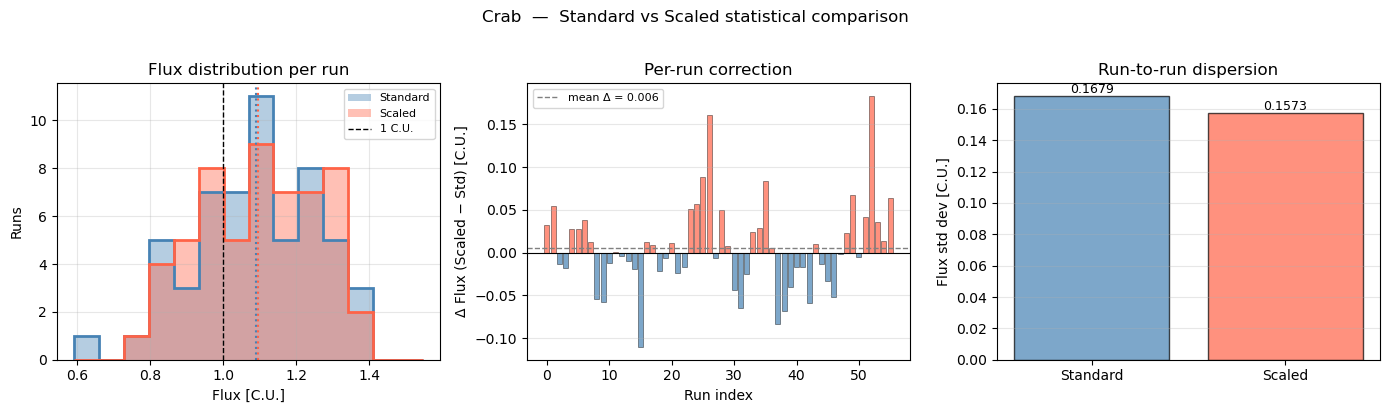

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ── (a) Distributions side by side ─────────────────────────────────────────
ax = axes[0]
bins = np.linspace(
    min(f_std.min(), f_sca.min()) * 0.9,
    max(f_std.max(), f_sca.max()) * 1.1,
    15,
)
ax.hist(f_std, bins=bins, color=COLOR_STD,    histtype="stepfilled", alpha=0.4, label=LABEL_STD)
ax.hist(f_sca, bins=bins, color=COLOR_SCALED, histtype="stepfilled", alpha=0.4, label=LABEL_SCALED)
ax.hist(f_std, bins=bins, color=COLOR_STD,    histtype="step",       lw=2)
ax.hist(f_sca, bins=bins, color=COLOR_SCALED, histtype="step",       lw=2)
ax.axvline(1.0, color="k", ls="--", lw=1, label="1 C.U.")
for val, col in [(f_std.mean(), COLOR_STD), (f_sca.mean(), COLOR_SCALED)]:
    ax.axvline(val, color=col, ls=":", lw=1.5)
ax.set_xlabel("Flux [C.U.]")
ax.set_ylabel("Runs")
ax.set_title("Flux distribution per run")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── (b) Per-run difference (Scaled − Standard) ──────────────────────────────
ax = axes[1]
delta = f_sca - f_std
ax.bar(range(n_common), delta,
       color=[COLOR_SCALED if d >= 0 else COLOR_STD for d in delta],
       alpha=0.7, edgecolor="k", linewidth=0.4)
ax.axhline(0, color="k", lw=0.8)
ax.axhline( delta.mean(), color="gray", ls="--", lw=1, label=f"mean Δ = {delta.mean():.3f}")
ax.set_xlabel("Run index")
ax.set_ylabel("Δ Flux (Scaled − Std) [C.U.]")
ax.set_title("Per-run correction")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# ── (c) Variance comparison bar chart ──────────────────────────────────────
ax = axes[2]
stds = [f_std.std(), f_sca.std()]
colors = [COLOR_STD, COLOR_SCALED]
labels = [LABEL_STD, LABEL_SCALED]
bars = ax.bar(labels, stds, color=colors, alpha=0.7, edgecolor="k")
for bar, s in zip(bars, stds):
    ax.text(bar.get_x() + bar.get_width()/2, s + 0.002,
            f"{s:.4f}", ha="center", fontsize=9)
ax.set_ylabel("Flux std dev [C.U.]")
ax.set_title("Run-to-run dispersion")
ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"{SOURCE_NAME}  —  Standard vs Scaled statistical comparison", y=1.02)
plt.tight_layout()
plt.show()

### Why a classical LRT does not apply — and what we can do instead

A Likelihood-Ratio Test requires two **nested** models fit to the **same data**.
Here the Scaled IRFs embed N free correction factors (one per observation),
each constrained by an *independent* auxiliary dataset (the calibration sample).
From the perspective of the gamma dataset alone the Scaled model has N extra parameters
**but also N extra data points** (the calibration measurements). The net change in
degrees of freedom is zero, so Wilks' theorem does not apply and `2 ΔlogL` does not
follow a χ² distribution.

A rigorous treatment requires a **profile likelihood** over the joint space
(gamma dataset + calibration dataset). The cell below computes an *approximation*:
the weighted χ² of each dataset's per-run fluxes around the global Crab reference
(1 C.U.), treating the two as independent experiments and comparing the total statistics.

In [63]:
# ── Profile-χ² approximation ─────────────────────────────────────────────
#
# For each dataset we compute the weighted sum of squared residuals
# around the Crab reference (1 C.U.):
#
#   chi2 = Σ_i  (f_i - 1)^2 / sigma_i^2
#
# Both datasets have the same N runs (= N degrees of freedom if we do not
# fit any free parameter, or N-1 if we allow an overall normalisation shift).
# We compare the two statistics directly — a smaller chi2 means the
# distribution is more consistent with the Crab reference.
#
# This is NOT a formal LRT, but it IS a meaningful goodness-of-fit comparison
# on the same footing for both datasets.

chi2_std = np.sum((f_std - 1.0)**2 / e_std**2)
chi2_sca = np.sum((f_sca - 1.0)**2 / e_sca**2)
ndf_ref  = n_common        # no free parameters — fixing to 1 C.U.

p_std = stats.chi2.sf(chi2_std, ndf_ref)
p_sca = stats.chi2.sf(chi2_sca, ndf_ref)

print("Weighted χ² around Crab reference (1 C.U.), no free parameters")
print(f"{'Dataset':12s}  {'χ²':>8s}  {'ndf':>5s}  {'χ²/ndf':>8s}  {'p-value':>10s}")
print("-"*52)
for label, c2, p in [(LABEL_STD, chi2_std, p_std), (LABEL_SCALED, chi2_sca, p_sca)]:
    print(f"{label:12s}  {c2:>8.2f}  {ndf_ref:>5d}  {c2/ndf_ref:>8.3f}  {p:>10.4e}")

# ── Also allow a free normalisation (N-1 dof) ──────────────────────────────
print("\nWeighted χ² around weighted mean (1 free normalisation), ndf = N-1")
ndf_free = n_common - 1
for label, fluxes, errors in [
    (LABEL_STD,    f_std, e_std),
    (LABEL_SCALED, f_sca, e_sca),
]:
    w      = 1.0 / errors**2
    mean_w = (fluxes * w).sum() / w.sum()
    c2     = np.sum((fluxes - mean_w)**2 / errors**2)
    p      = stats.chi2.sf(c2, ndf_free)
    print(f"  {label:12s}  χ² = {c2:.2f}  ndf = {ndf_free}  χ²/ndf = {c2/ndf_free:.3f}  p = {p:.4e}  mean = {mean_w:.4f} C.U.")

print("\n⚠  Reminder: these χ² values are computed on *independent* datasets.")
print("   2(χ²_std − χ²_sca) does NOT follow χ²(0) — it is not a valid LRT.")
print("   Use the paired tests in the previous cell for formal hypothesis testing.")

Weighted χ² around Crab reference (1 C.U.), no free parameters
Dataset             χ²    ndf    χ²/ndf     p-value
----------------------------------------------------
Standard        263.44     56     4.704  1.2230e-28
Scaled          241.25     56     4.308  7.6570e-25

Weighted χ² around weighted mean (1 free normalisation), ndf = N-1
  Standard      χ² = 209.22  ndf = 55  χ²/ndf = 3.804  p = 7.8015e-20  mean = 1.0871 C.U.
  Scaled        χ² = 173.10  ndf = 55  χ²/ndf = 3.147  p = 3.8490e-14  mean = 1.0982 C.U.

⚠  Reminder: these χ² values are computed on *independent* datasets.
   2(χ²_std − χ²_sca) does NOT follow χ²(0) — it is not a valid LRT.
   Use the paired tests in the previous cell for formal hypothesis testing.


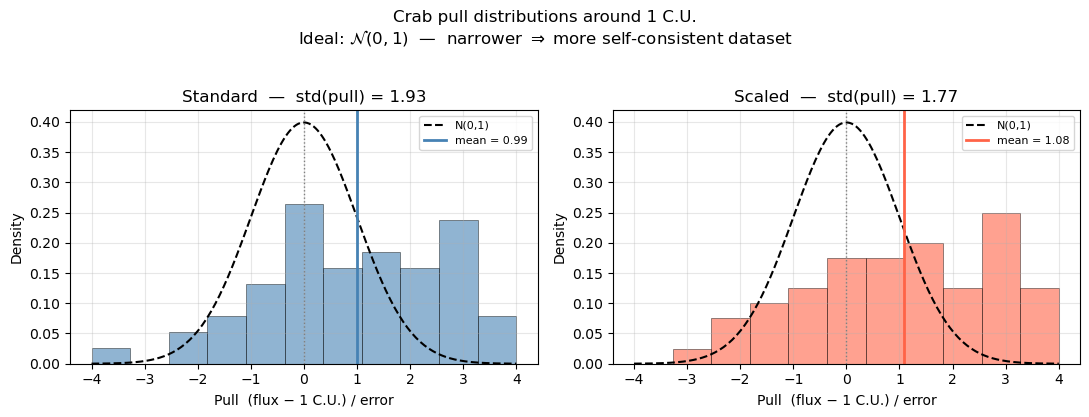

Pull statistics:
Dataset           mean       std      skew      kurt
Standard         0.993     1.928    -0.458    -0.070
Scaled           1.082     1.771    -0.297    -0.740


In [64]:
# ── Visual summary: flux pull distributions ───────────────────────────────
# Pull = (flux - 1 C.U.) / error  — should be N(0,1) for a perfect Crab dataset

pull_std = (f_std - 1.0) / e_std
pull_sca = (f_sca - 1.0) / e_sca

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

x_norm = np.linspace(-4, 4, 200)
y_norm = stats.norm.pdf(x_norm)

for ax, pull, label, color in [
    (axes[0], pull_std, LABEL_STD,    COLOR_STD),
    (axes[1], pull_sca, LABEL_SCALED, COLOR_SCALED),
]:
    bins = np.linspace(-4, 4, 12)
    ax.hist(pull, bins=bins, color=color, alpha=0.6,
            density=True, edgecolor="k", linewidth=0.5)
    ax.plot(x_norm, y_norm, "k--", lw=1.5, label="N(0,1)")
    ax.axvline(pull.mean(),  color=color,  ls="-",  lw=2,
               label=f"mean = {pull.mean():.2f}")
    ax.axvline(0, color="gray", ls=":", lw=1)
    ax.set_xlabel("Pull  (flux − 1 C.U.) / error")
    ax.set_ylabel("Density")
    ax.set_title(f"{label}  —  std(pull) = {pull.std():.2f}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(
    f"{SOURCE_NAME} pull distributions around 1 C.U.\n"
    r"Ideal: $\mathcal{N}(0,1)$  —  narrower $\Rightarrow$ more self-consistent dataset",
    y=1.03,
)
plt.tight_layout()
plt.show()

print(f"Pull statistics:\n{'Dataset':12s}  {'mean':>8s}  {'std':>8s}  {'skew':>8s}  {'kurt':>8s}")
for label, pull in [(LABEL_STD, pull_std), (LABEL_SCALED, pull_sca)]:
    print(f"{label:12s}  {pull.mean():>8.3f}  {pull.std():>8.3f}  {stats.skew(pull):>8.3f}  {stats.kurtosis(pull):>8.3f}")

In [65]:
lc_table_std

time_min,time_max,e_ref,e_min,e_max,flux,flux_err,flux_errp,flux_errn,flux_ul,flux_sensitivity,ts,sqrt_ts,npred,npred_excess,stat,stat_null,stat_scan,is_ul,counts,success,norm_scan
,,TeV,TeV,TeV,1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),,,,,,,,,,,
float64,float64,float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],"float64[1,56]","float64[1,56]",float64[1],float64[1],"float64[1,11]",bool[1],"float64[1,56]",bool[1],"float64[1,11]"
60934.17781908467,60934.18387221122,2.402248867962862,0.2885399811814427,19.999999999999996,1.0855876551209967e-10,1.3154516976320613e-11,1.3543923132999229e-11,1.2776474106457858e-11,1.363637042242935e-10,2.8165670614161703e-11,71.10418832794528,8.432329946577356,104.62919541035235 .. nan,88.2591781616211 .. nan,10.20079601175142,81.3049843396967,51.755826366688666 .. 585.5465818354807,False,103.0 .. nan,True,0.2 .. 4.999999999999999
60940.141835633214,60940.15577329839,2.402248867962862,0.2885399811814427,19.999999999999996,1.5044141512856917e-10,9.909199138154093e-12,1.0010390090682316e-11,9.812586127914987e-12,1.7069218330400566e-10,1.1458153114006653e-11,247.20937431782474,15.722893318910002,nan .. nan,nan .. nan,5.0320772068485535,252.2414515246733,176.03293307840528 .. 1333.076413835919,False,nan .. nan,True,0.2 .. 4.999999999999999
60940.155966527775,60940.16989962697,2.402248867962862,0.2885399811814427,19.999999999999996,1.392022722474193e-10,1.0357779194351374e-11,1.0474293957830784e-11,1.0246172561479188e-11,1.6041346577023928e-10,1.1951484568174722e-11,213.55543437283438,14.613535998273463,nan .. nan,nan .. nan,8.895630367299404,222.45106474013377,149.74119127272434 .. 1223.2164807830409,False,nan .. nan,True,0.2 .. 4.999999999999999
60940.170101546486,60940.18401938245,2.402248867962862,0.2885399811814427,19.999999999999996,1.7779486985191057e-10,1.1099935608316203e-11,1.1233538546136666e-11,1.0971129308303901e-11,2.0054184870649723e-10,1.0801619166905758e-11,293.5775439458684,17.134104702197558,nan .. nan,nan .. nan,5.828503836957936,299.40604778282636,223.44681983155513 .. 959.5572158628429,False,nan .. nan,True,0.2 .. 4.999999999999999
60940.184206858554,60940.19822143199,2.402248867962862,0.2885399811814427,19.999999999999996,1.4007875122929124e-10,1.0781733398977997e-11,1.0911302441992648e-11,1.0661690058089771e-11,1.6221273679921532e-10,1.374353346817571e-11,188.5017492993323,13.729593923322433,nan .. nan,nan .. nan,9.32712497884361,197.8288742781759,134.76299304694422 .. 1070.5341122582743,False,nan .. nan,True,0.2 .. 4.999999999999999
60940.19842453428,60940.212395810595,2.402248867962862,0.2885399811814427,19.999999999999996,1.6138613388079033e-10,1.1663943560545312e-11,1.1808806562667318e-11,1.1526144337214423e-11,1.8530881317607158e-10,1.4204282466120686e-11,209.59468222668045,14.477385199913707,nan .. nan,nan .. nan,6.098490652663674,215.69317287934413,155.05832386591558 .. 896.5005077216264,False,nan .. nan,True,0.2 .. 4.999999999999999
60941.14506832507,60941.15871902786,2.402248867962862,0.2885399811814427,19.999999999999996,1.3444847162616328e-10,9.85296519822215e-12,9.959540704874776e-12,9.749704287792206e-12,1.5459713594571417e-10,1.1593250869063398e-11,216.6923453288756,14.720473678821467,nan .. nan,nan .. nan,14.825199741120556,231.51754506999617,154.60617538981785 .. 1367.17612830054,False,nan .. nan,True,0.2 .. 4.999999999999999
60941.15891924244,60941.17288176361,2.402248867962862,0.2885399811814427,19.999999999999996,1.5528411229041582e-10,1.0699970139269593e-11,1.0822090780866664e-11,1.0582375871067215e-11,1.7718160879534845e-10,1.2255576137935633e-11,236.77833932533056,15.3876034302074,nan .. nan,nan .. nan,3.8370746006274734,240.61541392595802,169.0997887949911 .. 1098.1506071672375,False,nan .. nan,True,0.2 .. 4.999999999999999


In [66]:
import pandas as pd
tng_dust = [0.0299999999999999, 11.4575, 0.4699999999999997, 0.4699999999999997, 0.4770866141732284, 0.4900000000000001, 0.4900000000000001, 3.96, 3.96, 3.96, 8.080000000000004, 8.080000000000002, 1.7912781954887218, 1.28, 0.0799999999999999, 0.0854901960784313, 0.0999999999999999, 0.0622222222222222, 0.07, 0.07, 0.5399999999999998, 0.54, 0.07, 0.07, 0.0741436464088398, 0.1199999999999999, 0.0897484276729559, 0.08, 0.08, 0.096, 4.75, 4.75, 4.223418803418803, 0.3700000000000001, 0.2295930232558139, 0.5, 0.6, 0.6000000000000001, 0.5999999999999999, 0.08, 0.0199999999999999, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.0396212121212121, 0.0899999999999999, 0.037032967032967, 0.03, 1.0399999999999998, 1.0400000000000005, 1.3236363636363635, 2.0]

file_run_ly = "./data/selection/rel_v2.ecsv"
df_relation_runs = pd.read_csv(file_run_ly)

scale = []
for run in OBS_IDS:
    d = df_relation_runs[df_relation_runs["runnumber"] == run].reset_index()
    scale.append(d["light_yield"][0])

In [ ]:
times = lc_table_std["time_min"]
f_st = flux_cu_std.value
f_sc = flux_cu_scaled.value

fig, ax = plt.subplots(figsize=(5, 3.5))
sc = ax.scatter(scale, 
                np.abs(f_sc-f_sc.mean())-np.abs(f_st-f_st.mean()), 
                marker=".", c=tng_dust, norm=LogNorm())

cbar = fig.colorbar(sc, ax=ax, label="TNG dust [$\\mu g /m^3$]")
ax.grid(alpha=0.3)
ax.set(xlabel="1/Light Yield (Brightest triplet)", ylabel="$\\Delta$ correction [C.U.]", xscale="linear", ylim=(-0.3, 0.3))
plt.show()